# Predicting perturbation responses for unseen cell-types (context transfer)

## Setting up environment-Imports

In [1]:
import cpa
import os
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import energy_distance

sc.settings.set_figure_params(dpi=100)


Global seed set to 0


## Dataset setup

In [2]:
# Load AnnDAta Object
data_path = './plate9_preprocessed_for_CPA_pred_cell_min_count.h5ad'
adata = sc.read(data_path)

# Count unique condition_IDs
adata.obs['condition_ID'].value_counts()

# List all obs (cell) metadata columns
print(adata.obs.columns.tolist())
print(adata.obs.head())

print("=== dose column ===")
print(adata.obs['dose'].unique().tolist())

print("\n=== cell_line value counts ===")
print(adata.obs['cell_line'].unique().tolist())

print("\n=== condition_ID value counts ===")
print(adata.obs['condition_ID'].unique().tolist())


['sample', 'gene_count', 'tscp_count', 'mread_count', 'drugname_drugconc', 'drug', 'cell_line', 'sublibrary', 'BARCODE', 'pcnt_mito', 'S_score', 'G2M_score', 'phase', 'pass_filter', 'cell_name', 'plate', 'condition_ID', 'dose', 'log_dose', 'n_counts', 'condition', 'cov_cond']
                       sample  gene_count  tscp_count  mread_count  \
BARCODE_SUB_LIB_ID                                                   
01_121_064-lib_1646  smp_2263        1303        1704         1964   
01_014_055-lib_1638  smp_2263        1389        2118         2433   
01_115_114-lib_1608  smp_2263        1452        1966         2269   
01_053_175-lib_1607  smp_2263         886        1202         1410   
01_123_048-lib_1668  smp_2263         661         856         1016   

                                                     drugname_drugconc  \
BARCODE_SUB_LIB_ID                                                       
01_121_064-lib_1646  [('Sivelestat (sodium tetrahydrate)', 5.0, 'uM')]   
01_014_055

In [3]:
print(adata.shape)

(92826, 2000)


In [4]:
adata.obs['cell_name'].unique()

['NCI-H23', 'HOP62', 'SHP-77', 'CFPAC-1', 'NCI-H1792', ..., 'AN3 CA', 'SW 1271', 'C-33 A', 'CHP-212', 'NCI-H661']
Length: 47
Categories (47, object): ['A-172', 'A-427', 'A498', 'A549', ..., 'SW1417', 'SW48', 'SW480', 'hTERT-HPNE']

### Splitting Data into Train, Validation, and OOD Sets (Cell Line Holdout)

In [5]:
# Choose which cell type to hold out
cell_line_holdout = 'CVCL_0546'

# Initialize all as train
adata.obs['split_CVCL_0546'] = 'train'

# Mark OOD on that cell type
adata.obs.loc[
    adata.obs['cell_line'] == cell_line_holdout,
    'split_CVCL_0546'
] = 'ood'

# Create a Validation Subset from Training Cells (~5%)
train_idx = adata.obs.index[adata.obs['split_CVCL_0546'] == 'train']
n_val = max(1, int(0.05 * len(train_idx)))
val_idx = np.random.choice(train_idx, size=n_val, replace=False)
adata.obs.loc[val_idx, 'split_CVCL_0546'] = 'valid'

# Inspect counts
print(adata.obs['split_CVCL_0546'].value_counts())


split_CVCL_0546
train    82356
ood       6136
valid     4334
Name: count, dtype: int64


         Falling back to preprocessing with `sc.pp.pca` and default params.


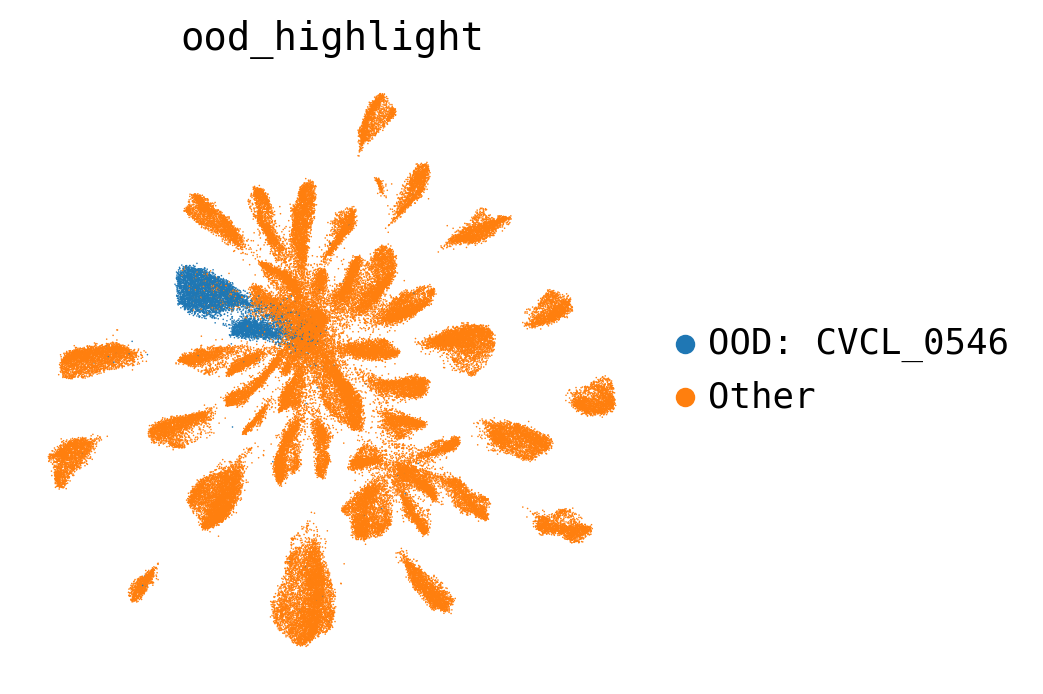

In [6]:
adata.obs["ood_highlight"]=np.where(adata.obs["split_CVCL_0546"]=="ood","OOD: CVCL_0546","Other")
sc.pp.neighbors(adata) 
sc.tl.umap(adata,random_state=0)
sc.pl.umap(adata,color="ood_highlight",frameon=False,legend_loc="right margin")



In [7]:
group = 'CVCL_0546_stimulated'  # or any other from the list above
print("Keys inside that group:", adata.uns['rank_genes_groups'][group].keys())

Keys inside that group: dict_keys(['logfoldchanges', 'names', 'pvals', 'pvals_adj', 'scores'])


In [8]:
# Build a new dictionary with just gene names per cov_cond
rg_cov = {}
for key in adata.uns['rank_genes_groups'].keys():
    rg_cov[key] = adata.uns['rank_genes_groups'][key]['names']

# Save under correct key
adata.uns['rank_genes_groups_cov'] = rg_cov


In [9]:
adata.obs['cell_line'].value_counts()

cell_line
CVCL_0546    6136
CVCL_0459    5791
CVCL_0480    4329
CVCL_0334    3476
CVCL_0428    3371
CVCL_1285    3215
CVCL_1693    2822
CVCL_0399    2736
CVCL_1119    2699
CVCL_1056    2633
CVCL_1550    2305
CVCL_1381    2243
CVCL_0023    2235
CVCL_0371    2124
CVCL_0504    2108
CVCL_0359    2081
CVCL_0293    2035
CVCL_0320    1997
CVCL_1495    1987
CVCL_1478    1915
CVCL_1635    1821
CVCL_0152    1771
CVCL_0397    1742
CVCL_0332    1716
CVCL_0131    1715
CVCL_0292    1688
CVCL_1717    1631
CVCL_1731    1602
CVCL_1097    1581
CVCL_1666    1565
CVCL_1547    1480
CVCL_0069    1480
CVCL_0099    1476
CVCL_1055    1460
CVCL_0218    1430
CVCL_1094    1410
CVCL_1517    1323
CVCL_C466    1257
CVCL_0366    1150
CVCL_1239    1123
CVCL_0179    1057
CVCL_1724     824
CVCL_1098     810
CVCL_1125     615
CVCL_0028     501
CVCL_1716     189
CVCL_1577     171
Name: count, dtype: int64

### CPA Model Configuration and Initialization

In [10]:
adata.X = adata.layers['counts'].copy()

In [11]:
#Setting Up AnnData for CPA Training

cpa.CPA.setup_anndata(adata,
                      perturbation_key='condition',
                      control_group='ctrl',
                      dosage_key='log_dose',
                      categorical_covariate_keys=['cell_line'],
                      is_count_data=True,
                      deg_uns_key='rank_genes_groups_cov',
                      deg_uns_cat_key='cov_cond',
                      max_comb_len=1,
                     )

100%|██████████| 94/94 [00:00<00:00, 3921.70it/s]


INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


In [12]:
# Trainer Hyperparameters

model_params = {
    "n_latent": 32,
    "recon_loss": "nb",
    "doser_type": "linear",
    "n_hidden_encoder": 128,
    "n_layers_encoder": 2,
    "n_hidden_decoder": 512,
    "n_layers_decoder": 2,
    "use_batch_norm_encoder": True,
    "use_layer_norm_encoder": False,
    "use_batch_norm_decoder": False,
    "use_layer_norm_decoder": True,
    "dropout_rate_encoder": 0.1,
    "dropout_rate_decoder": 0.1,
    "variational": False,
    "seed": 6977,
}

trainer_params = {
    "n_epochs_kl_warmup": None,
    "n_epochs_pretrain_ae": 30,
    "n_epochs_adv_warmup": 50,
    "n_epochs_mixup_warmup": 0,
    "mixup_alpha": 0.0,
    "adv_steps": None,
    "n_hidden_adv": 64,
    "n_layers_adv": 3,
    "use_batch_norm_adv": True,
    "use_layer_norm_adv": False,
    "dropout_rate_adv": 0.3,
    "reg_adv": 20.0,
    "pen_adv": 5.0,
    "lr": 0.0003,
    "wd": 4e-07,
    "adv_lr": 0.0003,
    "adv_wd": 4e-07,
    "adv_loss": "cce",
    "doser_lr": 0.0003,
    "doser_wd": 4e-07,
    "do_clip_grad": True,
    "gradient_clip_value": 1.0,
    "step_size_lr": 10,
}

In [13]:
# Initialize CPA Model with Data Splits and Hyperparameters

model = cpa.CPA(
    adata                = adata,
    split_key            = "split_CVCL_0546",   # <— use your new split
    train_split          = "train",
    valid_split          = "valid",
    test_split           = "ood",
    use_rdkit_embeddings = False,
    **model_params,
)

Global seed set to 6977


## Training CPA

In [14]:
model.train(max_epochs= 2000,
            use_gpu=False,
            train_size= 0.8,
            validation_size= 0.2,
            batch_size=512,
            plan_kwargs=trainer_params,
            early_stopping_patience=20,
            check_val_every_n_epoch=5,
            save_path='./cpa_pred_cell_training_final',         #save here 
           )

100%|██████████| 2/2 [00:00<00:00, 14.20it/s]
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 5/2000:   0%|          | 4/2000 [06:00<49:53:32, 89.99s/it, v_num=1, recon=223, r2_mean=0.68, adv_loss=2.63, acc_pert=0.544, acc_cell_line=0.472] 


Epoch 00004: cpa_metric reached. Module best state updated.


Epoch 10/2000:   0%|          | 9/2000 [15:09<61:49:13, 111.78s/it, v_num=1, recon=216, r2_mean=0.702, adv_loss=2.15, acc_pert=0.573, acc_cell_line=0.582, val_recon=215, disnt_basal=0.684, disnt_after=1.17, val_r2_mean=0.675, val_KL=nan]


Epoch 00009: cpa_metric reached. Module best state updated.


...

Epoch 100/2000:   5%|▍         | 99/2000 [2:35:48<43:38:36, 82.65s/it, v_num=1, recon=205, r2_mean=0.723, adv_loss=4.32, acc_pert=0.506, acc_cell_line=0.0683, val_recon=207, disnt_basal=0.528, disnt_after=1.17, val_r2_mean=0.701, val_KL=nan]
disnt_basal = 0.5286619742300969
disnt_after = 1.1731162205995507
val_r2_mean = 0.6961818516251517
val_r2_var = 0.4133675184034602
Epoch 110/2000:   5%|▌         | 109/2000 [2:52:53<56:05:08, 106.77s/it, v_num=1, recon=205, r2_mean=0.725, adv_loss=4.32, acc_pert=0.506, acc_cell_line=0.0686, val_recon=206, disnt_basal=0.527, disnt_after=1.17, val_r2_mean=0.695, val_KL=nan]
disnt_basal = 0.5259268405446756
disnt_after = 1.1703060046282552
val_r2_mean = 0.6973307882366719
val_r2_var = 0.417262059598931
Epoch 120/2000:   6%|▌         | 119/2000 [3:11:12<51:31:51, 98.62s/it, v_num=1, recon=205, r2_mean=0.726, adv_loss=4.32, acc_pert=0.504, acc_cell_line=0.0683, val_recon=207, disnt_basal=0.527, disnt_after=1.17, val_r2_mean=0.7, val_KL=nan]   


Epoch 00119: cpa_metric reached. Module best state updated.



disnt_basal = 0.5260071956471386
disnt_after = 1.1730999581278991
val_r2_mean = 0.70093653974179
val_r2_var = 0.4179607381353757
Epoch 130/2000:   6%|▋         | 129/2000 [3:24:48<41:24:56, 79.69s/it, v_num=1, recon=204, r2_mean=0.726, adv_loss=4.32, acc_pert=0.504, acc_cell_line=0.0673, val_recon=206, disnt_basal=0.526, disnt_after=1.17, val_r2_mean=0.699, val_KL=nan]
disnt_basal = 0.5266502091080416
disnt_after = 1.1725353488591503
val_r2_mean = 0.6979770759505269
val_r2_var = 0.416500337304577
Epoch 135/2000:   7%|▋         | 134/2000 [3:31:40<42:11:07, 81.39s/it, v_num=1, recon=204, r2_mean=0.727, adv_loss=4.32, acc_pert=0.505, acc_cell_line=0.0682, val_recon=207, disnt_basal=0.527, disnt_after=1.17, val_r2_mean=0.698, val_KL=nan]


Epoch 00134: cpa_metric reached. Module best state updated.


Epoch 140/2000:   7%|▋         | 139/2000 [3:38:31<42:16:31, 81.78s/it, v_num=1, recon=204, r2_mean=0.729, adv_loss=4.32, acc_pert=0.506, acc_cell_line=0.0678, val_recon=207, disnt_basal=0.527, disnt_after=1.17, val_r2_mean=0.705, val_KL=nan]
disnt_basal = 0.5261405458300181
disnt_after = 1.1718757207909667
val_r2_mean = 0.6965485939537825
val_r2_var = 0.416462090233008
Epoch 150/2000:   7%|▋         | 149/2000 [3:52:06<41:25:33, 80.57s/it, v_num=1, recon=204, r2_mean=0.728, adv_loss=4.32, acc_pert=0.504, acc_cell_line=0.0686, val_recon=207, disnt_basal=0.525, disnt_after=1.17, val_r2_mean=0.704, val_KL=nan]
disnt_basal = 0.5267831911634749
disnt_after = 1.169894820648064
val_r2_mean = 0.6977852021562219
val_r2_var = 0.4189646121878696
Epoch 160/2000:   8%|▊         | 159/2000 [4:05:28<40:35:52, 79.39s/it, v_num=1, recon=204, r2_mean=0.729, adv_loss=4.32, acc_pert=0.505, acc_cell_line=0.0682, val_recon=207, disnt_basal=0.525, disnt_after=1.17, val_r2_mean=0.702, val_KL=nan]
disnt_basal

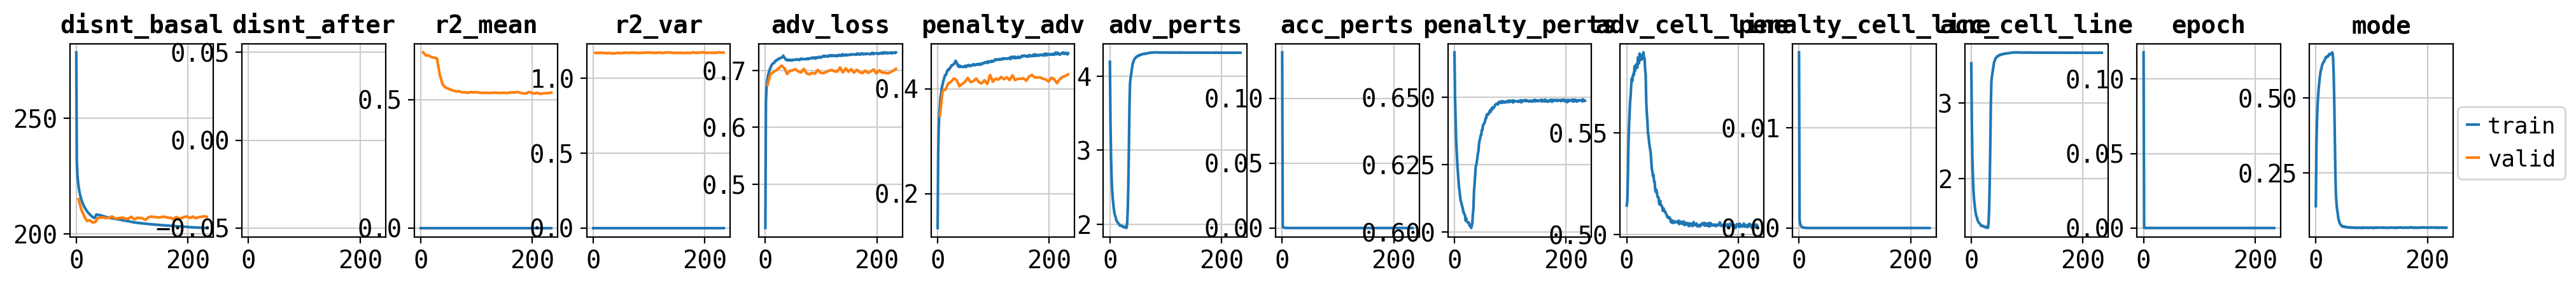

In [15]:
cpa.pl.plot_history(model)

# Load the saved Model

INFO     File ./cpa_pred_cell_training_final\model.pt already downloaded                                           


100%|██████████| 94/94 [00:00<00:00, 1980.88it/s]
Global seed set to 6977


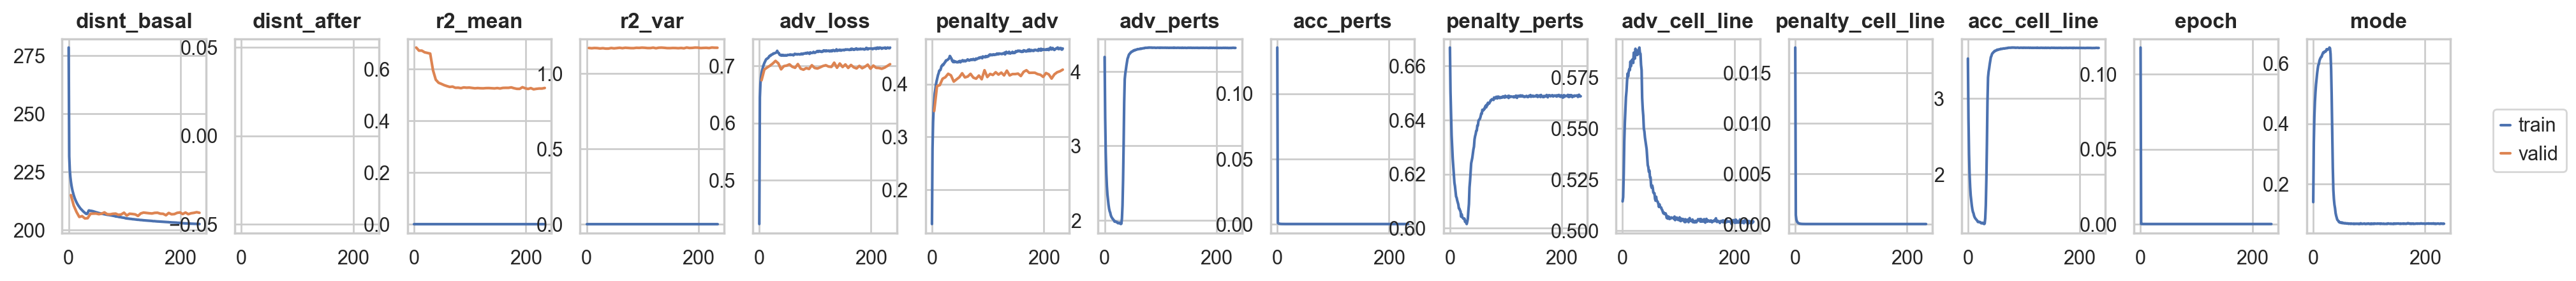

In [36]:
# Restore model 
model = cpa.CPA.load(dir_path='./cpa_pred_cell_training_final',
                     adata=adata,
                     use_gpu=False)

cpa.pl.plot_history(model)

## Latent Space Visualization

  0%|          | 0/46 [00:00<?, ?it/s]

100%|██████████| 46/46 [00:08<00:00,  5.28it/s]


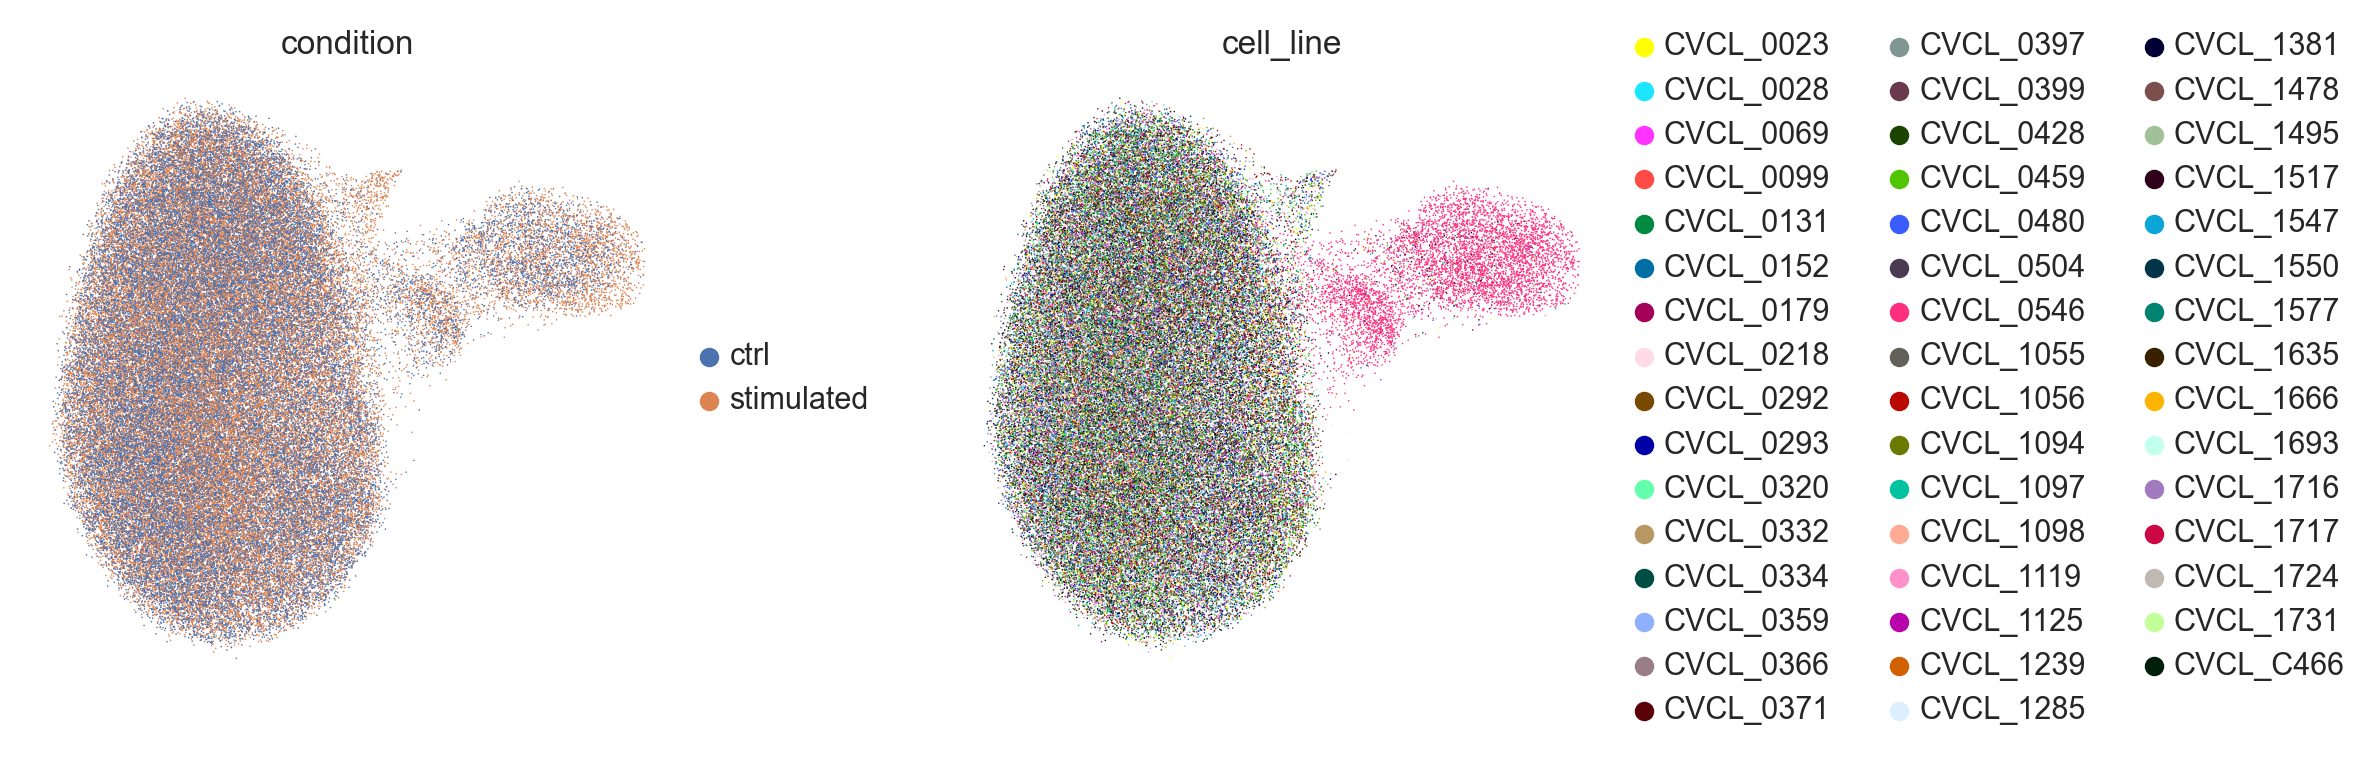

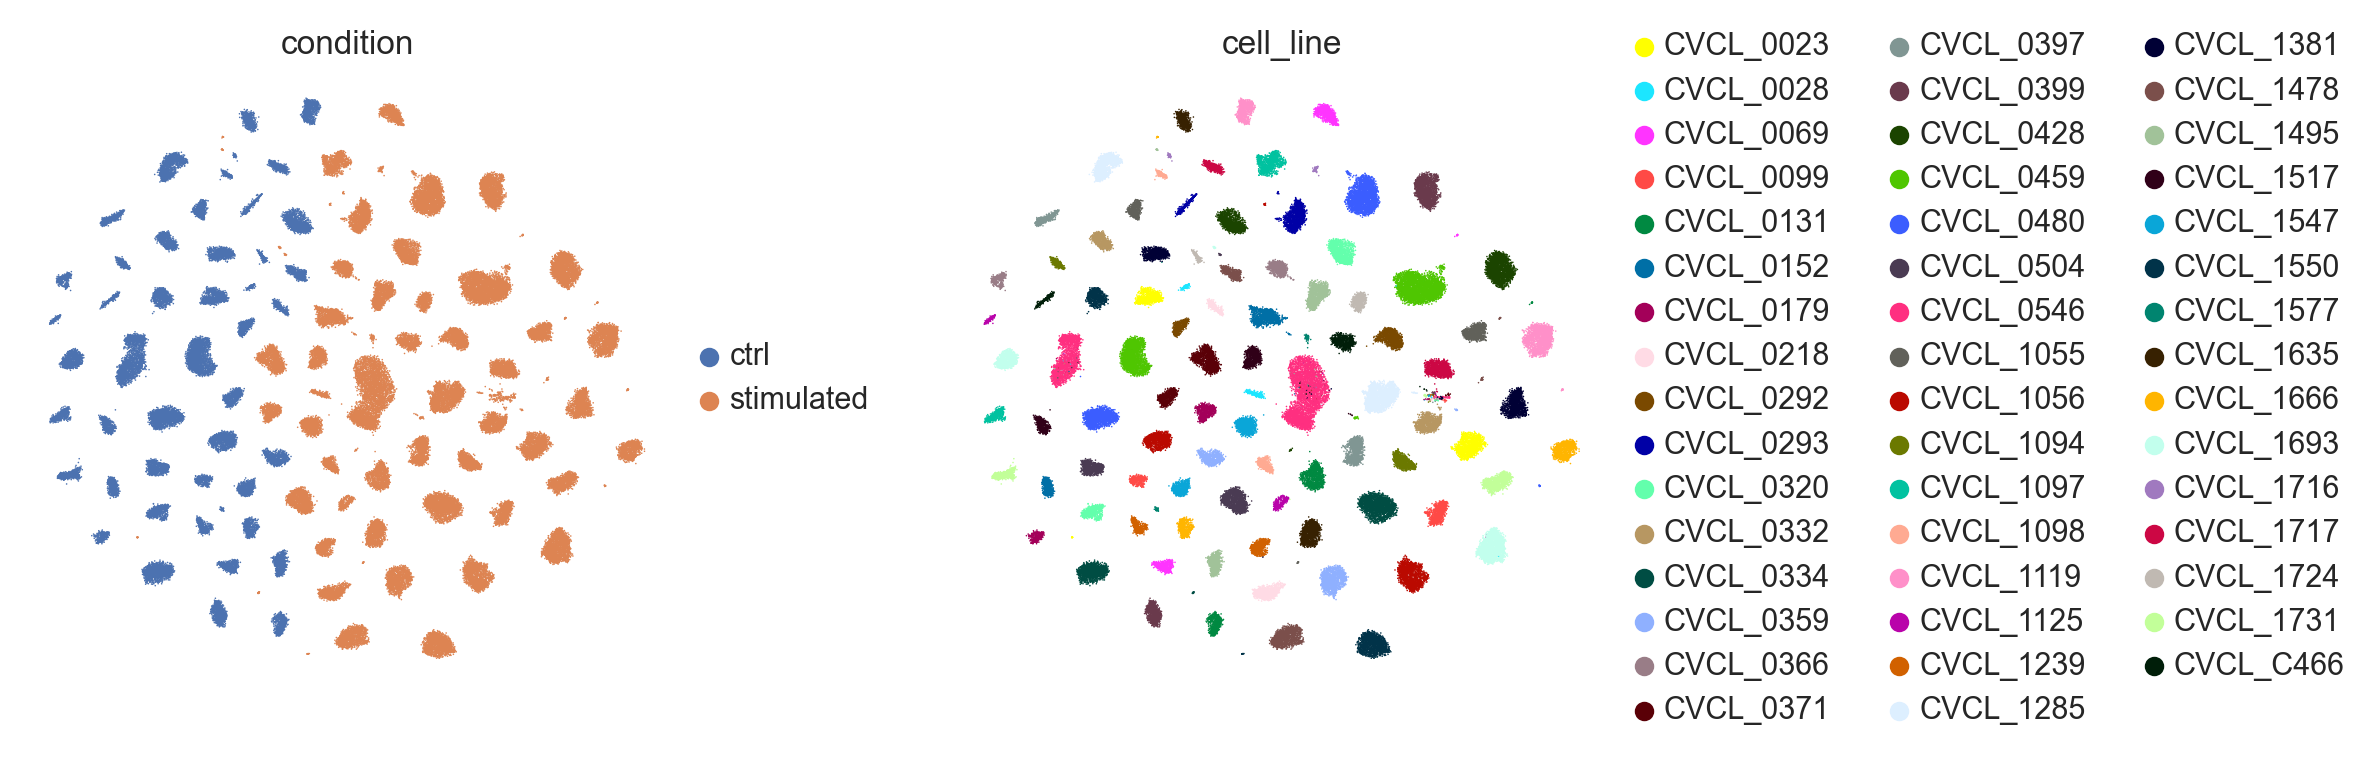

In [37]:
latent_outputs = model.get_latent_representation(adata, batch_size=2048)
latent_outputs.keys()
sc.pp.neighbors(latent_outputs['latent_basal'])
sc.tl.umap(latent_outputs['latent_basal'])
sc.pl.umap(latent_outputs['latent_basal'],
           color=['condition', 'cell_line'],
           frameon=False,
           wspace=0.3)

sc.pp.neighbors(latent_outputs['latent_after'])
sc.tl.umap(latent_outputs['latent_after'])

sc.pl.umap(latent_outputs['latent_after'],
           color=['condition', 'cell_line'],
           frameon=False,
           wspace=0.3)

## Evaluation

In [38]:
model.predict(adata, batch_size=2048)

  0%|          | 0/46 [00:00<?, ?it/s]

100%|██████████| 46/46 [00:22<00:00,  2.02it/s]


In [39]:
n_top_degs = [10, 20, 50, None] # None means all genes

results = defaultdict(list)                       #here it saves the performance results
for cat in tqdm(adata.obs['cov_cond'].unique()):  #loops over experimental conditions
    if 'ctrl' not in cat:
        cov, condition = cat.rsplit('_',1)
        cat_adata = adata[adata.obs['cov_cond'] == cat].copy()            #cat_adata: All cells for the current stimulated condition
        print("cat-data:", cat_adata)
        ctrl_adata = adata[adata.obs['cov_cond'] == f'{cov}_ctrl'].copy() #ctrl_adata: All cells for the corresponding control condition
        print("ctr-data:", ctrl_adata)

        #break

        deg_cat = f'{cat}'                                                  #retrive the DEGs
        deg_list = adata.uns['rank_genes_groups'][deg_cat]['names']
        print("deg_list:", deg_list)

        print(f"Number of DEGs in {deg_cat}: {len(deg_list)}")              
        
        x_true = cat_adata.layers['counts']                                 #assign the true vs predicted data
        x_pred = cat_adata.obsm['CPA_pred']
        x_ctrl = ctrl_adata.layers['counts']

        #break
        x_true = np.log1p(x_true)
        x_pred = np.log1p(x_pred)
        x_ctrl = np.log1p(x_ctrl)

        for n_top_deg in n_top_degs:                                        #evaluate the n top DEGs
            if n_top_deg is not None:
                degs = np.where(np.isin(adata.var_names, deg_list[:n_top_deg]))[0]
            else:
                degs = np.arange(adata.n_vars)
                n_top_deg = 'all'

        
            x_true_deg = x_true[:, degs]
            x_pred_deg = x_pred[:, degs]
            x_ctrl_deg = x_ctrl[:, degs]

            if x_true_deg.shape[0] < 2 or x_pred_deg.shape[0] < 2:
                print(f" Skipping R² computation for {cat}, n_top_deg={n_top_deg} due to insufficient samples.")
                continue
            if x_true_deg.shape[1] != x_pred_deg.shape[1]:
                print(f" Skipping due to mismatch in DEG count: x_true_deg {x_true_deg.shape}, x_pred_deg {x_pred_deg.shape}")
                continue
            if len(degs) == 0:
                print(f" Skipping R² for {cat} @top-{n_top_deg}: No DEGs found")
                continue



            print(f"\n Shapes before R² computation for {cat}, top-{n_top_deg}:")
            print("x_true shape:", x_true.shape)
            print("x_pred shape:", x_pred.shape)
            print("x_ctrl shape:", x_ctrl.shape)
            print("x_true_deg shape:", x_true_deg.shape)
            print("x_pred_deg shape:", x_pred_deg.shape)
            print("x_ctrl_deg shape:", x_ctrl_deg.shape)
            print("degs shape:", degs.shape)
            print("degs indices:", degs)
            print("Number of DEGs used:", len(degs))

            # Convert to 1D numpy arrays (flattened) for compatibility
            # Means
            true_mean = np.asarray(x_true_deg.mean(0)).flatten()
            pred_mean = np.asarray(x_pred_deg.mean(0)).flatten()
            ctrl_mean = np.asarray(x_ctrl_deg.mean(0)).flatten()

            # Variances
            true_var = np.var(x_true_deg.toarray(), axis=0)
            pred_var = np.var(x_pred_deg, axis=0)
            ctrl_var = np.var(x_ctrl_deg.toarray(), axis=0)


            # R² computations
            r2_mean_deg = r2_score(true_mean, pred_mean)
            r2_var_deg = r2_score(true_var, pred_var)

            r2_mean_lfc_deg = r2_score(true_mean - ctrl_mean, pred_mean - ctrl_mean)
            r2_var_lfc_deg = r2_score(true_var - ctrl_var, pred_var - ctrl_var)

            # RMSE metrics
            rmse_mean = np.sqrt(mean_squared_error(true_mean, pred_mean))
            rmse_lfc = np.sqrt(mean_squared_error(true_mean - ctrl_mean, pred_mean - ctrl_mean))

            # Cosine similarity
            cos_sim = cosine_similarity(
                (true_mean - ctrl_mean).reshape(1, -1),
                (pred_mean - ctrl_mean).reshape(1, -1)
            )[0][0]

            # E-distance
            e_dist = energy_distance(true_mean, pred_mean)


            # store results 
            results['condition'].append(condition)
            results['cell_type'].append(cov)
            results['n_top_deg'].append(n_top_deg)
            results['r2_mean_deg'].append(r2_mean_deg)
            results['r2_var_deg'].append(r2_var_deg)
            results['r2_mean_lfc_deg'].append(r2_mean_lfc_deg)
            results['r2_var_lfc_deg'].append(r2_var_lfc_deg)
            results['rmse_mean'].append(rmse_mean)
            results['rmse_lfc'].append(rmse_lfc)
            results['cosine_sim'].append(cos_sim)
            results['e_distance'].append(e_dist)

df = pd.DataFrame(results)  #convert to Dataframe

  0%|          | 0/94 [00:00<?, ?it/s]

cat-data: AnnData object with n_obs × n_vars = 852 × 2000
    obs: 'sample', 'gene_count', 'tscp_count', 'mread_count', 'drugname_drugconc', 'drug', 'cell_line', 'sublibrary', 'BARCODE', 'pcnt_mito', 'S_score', 'G2M_score', 'phase', 'pass_filter', 'cell_name', 'plate', 'condition_ID', 'dose', 'log_dose', 'n_counts', 'condition', 'cov_cond', 'split_CVCL_0546', 'ood_highlight', 'CPA_cat', 'CPA_ctrl', '_scvi_condition', '_scvi_cell_line', '_scvi_CPA_cat', 'treatment_group'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'rank_genes_groups', 'neighbors', 'umap', 'ood_highlight_colors', 'rank_genes_groups_cov', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'perts', 'perts_doses', 'deg_mask', 'deg_mask_r2', 'CPA_pred'
    layers: 'counts'
    obsp: 'distances', 'connectivities'


  1%|          | 1/94 [00:01<01:41,  1.09s/it]

ctr-data: AnnData object with n_obs × n_vars = 628 × 2000
    obs: 'sample', 'gene_count', 'tscp_count', 'mread_count', 'drugname_drugconc', 'drug', 'cell_line', 'sublibrary', 'BARCODE', 'pcnt_mito', 'S_score', 'G2M_score', 'phase', 'pass_filter', 'cell_name', 'plate', 'condition_ID', 'dose', 'log_dose', 'n_counts', 'condition', 'cov_cond', 'split_CVCL_0546', 'ood_highlight', 'CPA_cat', 'CPA_ctrl', '_scvi_condition', '_scvi_cell_line', '_scvi_CPA_cat', 'treatment_group'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'rank_genes_groups', 'neighbors', 'umap', 'ood_highlight_colors', 'rank_genes_groups_cov', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'perts', 'perts_doses', 'deg_mask', 'deg_mask_r2', 'CPA_pred'
    layers: 'counts'
    obsp: 'distances', 'connectivities'
deg_list: ['PTPRN2' 'COL4A5' 'ROBO1' ... 'RPS16' 'MT2A' 'EGR1']
Number of DEGs in CVCL_1547_stimulated: 2000

 Shapes before R² computation for CVCL_15

  2%|▏         | 2/94 [00:02<01:41,  1.10s/it]

...

 48%|████▊     | 45/94 [00:32<00:25,  1.94it/s]


 Shapes before R² computation for CVCL_1094_stimulated, top-10:
x_true shape: (968, 2000)
x_pred shape: (968, 2000)
x_ctrl shape: (442, 2000)
x_true_deg shape: (968, 10)
x_pred_deg shape: (968, 10)
x_ctrl_deg shape: (442, 10)
degs shape: (10,)
degs indices: [ 56  72 105 398 405 463 492 577 632 760]
Number of DEGs used: 10

 Shapes before R² computation for CVCL_1094_stimulated, top-20:
x_true shape: (968, 2000)
x_pred shape: (968, 2000)
x_ctrl shape: (442, 2000)
x_true_deg shape: (968, 20)
x_pred_deg shape: (968, 20)
x_ctrl_deg shape: (442, 20)
degs shape: (20,)
degs indices: [   8   56   72   74  105  339  394  398  405  439  463  492  577  632
  760  830  872  938  940 1829]
Number of DEGs used: 20

 Shapes before R² computation for CVCL_1094_stimulated, top-50:
x_true shape: (968, 2000)
x_pred shape: (968, 2000)
x_ctrl shape: (442, 2000)
x_true_deg shape: (968, 50)
x_pred_deg shape: (968, 50)
x_ctrl_deg shape: (442, 50)
degs shape: (50,)
degs indices: [   8   31   56   72   74   98

 49%|████▉     | 46/94 [00:33<00:24,  1.95it/s]


 Shapes before R² computation for CVCL_1125_stimulated, top-20:
x_true shape: (409, 2000)
x_pred shape: (409, 2000)
x_ctrl shape: (206, 2000)
x_true_deg shape: (409, 20)
x_pred_deg shape: (409, 20)
x_ctrl_deg shape: (206, 20)
degs shape: (20,)
degs indices: [ 51  63 105 273 305 322 341 403 422 436 534 552 574 575 627 630 642 683
 810 933]
Number of DEGs used: 20

 Shapes before R² computation for CVCL_1125_stimulated, top-50:
x_true shape: (409, 2000)
x_pred shape: (409, 2000)
x_ctrl shape: (206, 2000)
x_true_deg shape: (409, 50)
x_pred_deg shape: (409, 50)
x_ctrl_deg shape: (206, 50)
degs shape: (50,)
degs indices: [   8   19   51   63   73  103  105  107  114  119  159  169  195  209
  219  273  305  322  341  371  403  422  426  436  443  457  475  486
  492  534  552  555  574  575  592  611  627  630  642  683  688  761
  810  933  986 1031 1461 1576 1741 1865]
Number of DEGs used: 50

 Shapes before R² computation for CVCL_1125_stimulated, top-all:
x_true shape: (409, 2000)
x_pr

100%|██████████| 94/94 [00:33<00:00,  2.78it/s]


In [40]:
df


,condition,cell_type,n_top_deg,r2_mean_deg,r2_var_deg,r2_mean_lfc_deg,r2_var_lfc_deg,rmse_mean,rmse_lfc,cosine_sim,e_distance
0,stimulated,CVCL_1547,10,0.926956,0.063139,-0.972869,-20.502043,0.108008,0.108008,0.985087,0.174537
1,stimulated,CVCL_1547,20,0.930305,0.389757,-0.385217,-6.654944,0.088850,0.088850,0.988368,0.147094
2,stimulated,CVCL_1547,50,0.929728,0.426208,-0.220067,-6.309089,0.072450,0.072450,0.988184,0.101410
3,stimulated,CVCL_1547,all,0.945030,0.726428,0.087217,-2.419055,0.022327,0.022327,0.947745,0.015308
4,stimulated,CVCL_1285,10,0.832683,-0.065913,-1.201982,-5.417731,0.092587,0.092587,0.995880,0.183774
...,...,...,...,...,...,...,...,...,...,...,...
183,stimulated,CVCL_1125,all,0.929234,0.704145,-0.776377,-4.166532,0.024414,0.024414,0.836697,0.015492
184,stimulated,CVCL_1577,10,0.914759,-0.183917,0.194532,-6.475260,0.060395,0.060395,0.986393,0.105044
185,stimulated,CVCL_1577,20,0.901684,0.582515,0.055667,-5.662771,0.073487,0.073487,0.969992,0.066746
186,stimulated,CVCL_1577,50,0.929420,0.660511,0.260983,-3.943891,0.059938,0.059938,0.962284,0.043398


In [41]:
ood_cell_line = "CVCL_0546"  # chosen ood cell line
df_ood = df[df['cell_type'] == ood_cell_line]
print(df_ood)


     condition  cell_type n_top_deg  r2_mean_deg  r2_var_deg  r2_mean_lfc_deg  \
32  stimulated  CVCL_0546        10    -0.329894    0.078236        -7.512424   
33  stimulated  CVCL_0546        20    -0.364832    0.028487        -9.519428   
34  stimulated  CVCL_0546        50     0.429567   -0.054372        -6.057883   
35  stimulated  CVCL_0546       all     0.788576    0.621451        -2.653844   

    r2_var_lfc_deg  rmse_mean  rmse_lfc  cosine_sim  e_distance  
32       -1.394696   0.230049  0.230049    0.917104    0.287365  
33       -2.169876   0.210020  0.210020    0.907061    0.237873  
34       -4.824752   0.150055  0.150055    0.850477    0.125875  
35       -3.945598   0.038785  0.038785    0.775973    0.016164  


In [42]:
print("=== Per Cell Line Metrics ===")
cell_line_summary = df.groupby('cell_type').mean(numeric_only=True)
print(cell_line_summary)

=== Per Cell Line Metrics ===
           r2_mean_deg  r2_var_deg  r2_mean_lfc_deg  r2_var_lfc_deg  \
cell_type                                                             
CVCL_0023     0.935191    0.479032         0.131112       -6.470372   
CVCL_0028     0.815725    0.433154        -0.672396       -4.282249   
CVCL_0069     0.871667    0.341974        -1.019264       -9.678672   
CVCL_0099     0.929138    0.476317        -0.421196      -10.038609   
CVCL_0131     0.867932   -0.321496        -0.529975      -20.797812   
CVCL_0152     0.954473    0.546772         0.229763       -6.662391   
CVCL_0179     0.778695   -0.091870        -1.011415       -5.113520   
CVCL_0218     0.914053    0.317782        -0.735275      -19.422129   
CVCL_0292     0.903587    0.486934        -0.451931       -7.716078   
CVCL_0293     0.905979    0.700777        -1.686738       -6.816733   
CVCL_0320     0.883881   -0.096045        -1.014052      -20.351112   
CVCL_0332     0.943014   -0.078020        -0.29

# Evaluation metrics 

### RMSE 
RMSE is calculated by taking the square root of the average of the squared differences between predicted and actual values. A smaller RMSE indicates better model performance.

In [43]:
mean_rmse_all = df['rmse_mean'].mean()
print("Mean RMSE across all cell lines:", mean_rmse_all)


Mean RMSE across all cell lines: 0.07177874077660319


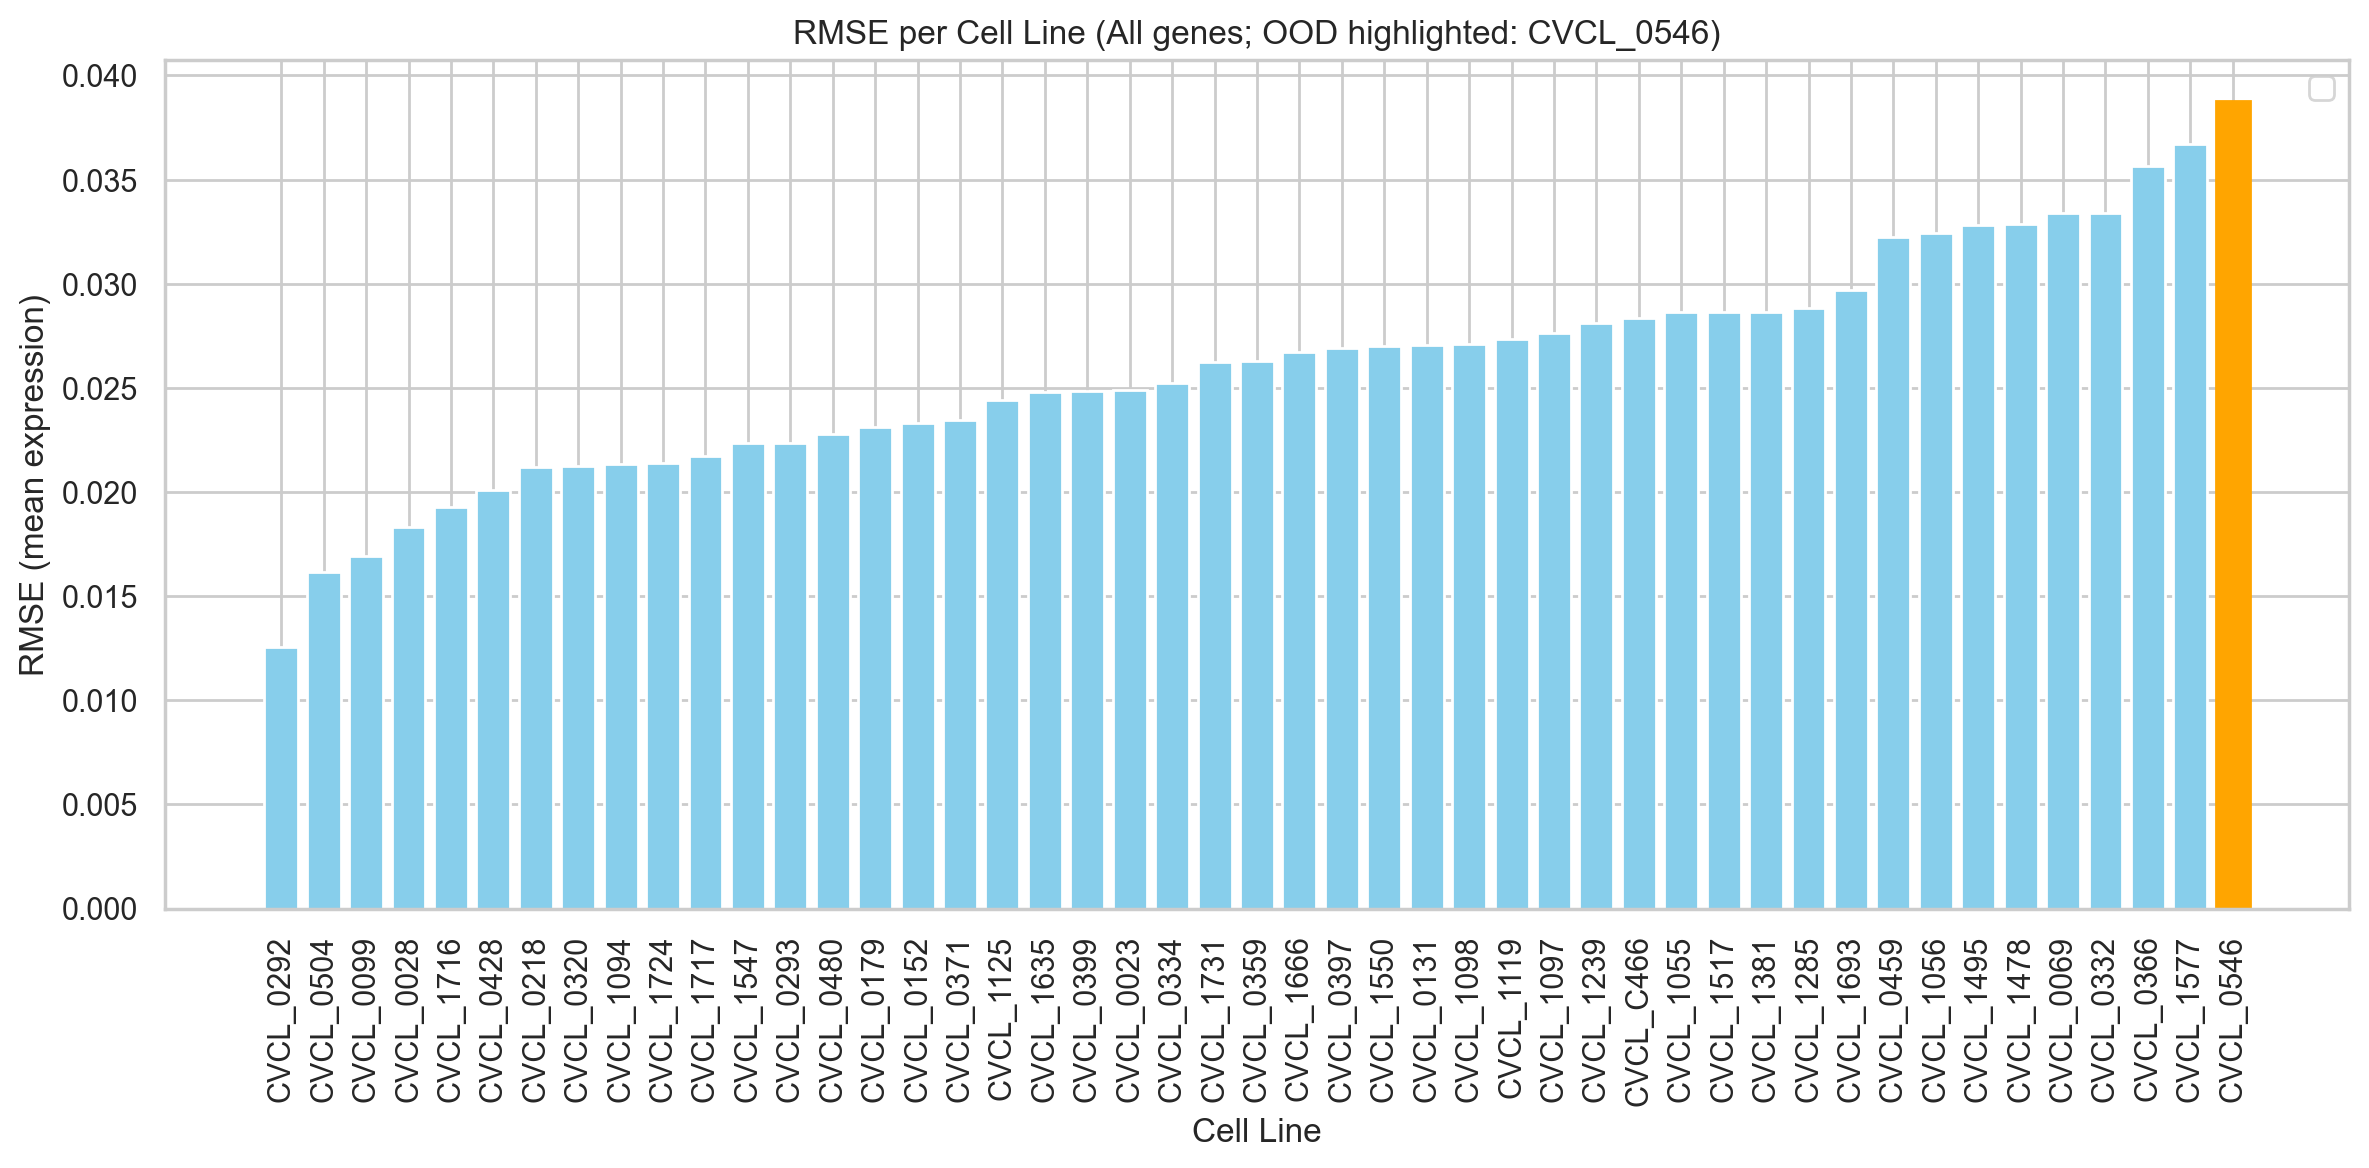

In [44]:

deg_to_plot = "all"  # choose from {10, 20, 50, "all"}

if str(deg_to_plot).lower() == "all":
    mask_deg = df["n_top_deg"].isna() | df["n_top_deg"].astype(str).str.lower().eq("all")
    df_use = df[mask_deg]
else:
    df_use = df[df["n_top_deg"].astype(str) == str(deg_to_plot)]

rmse_per_cell = df_use.groupby('cell_type')['rmse_mean'].mean().sort_values()

plt.figure(figsize=(12, 6))
bars = plt.bar(rmse_per_cell.index, rmse_per_cell.values, color='skyblue')

# highlight OOD in orange
for bar, cell in zip(bars, rmse_per_cell.index):
    if cell == ood_cell_line:
        bar.set_color('orange')


title_deg = "All genes" if str(deg_to_plot).lower() == "all" else f"DEGs = {deg_to_plot}"
plt.title(f"RMSE per Cell Line ({title_deg}; OOD highlighted: {ood_cell_line})")
plt.ylabel("RMSE (mean expression)")
plt.xlabel("Cell Line")
plt.xticks(rotation=90)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()



### Cosine similarity 
Measures the angle between two vectors, which compares predicted vs observed log fold-change (LFC) profiles of gene expression. 
-1 ≤ cosine similarity ≤ 1   Perfect alignment (predicted and observed profiles have the same direction and shape. )



In [45]:
mean_cosine = df['cosine_sim'].mean()
print("Mean Cosine Similarity across all cell lines:", mean_cosine)


Mean Cosine Similarity across all cell lines: 0.96725285


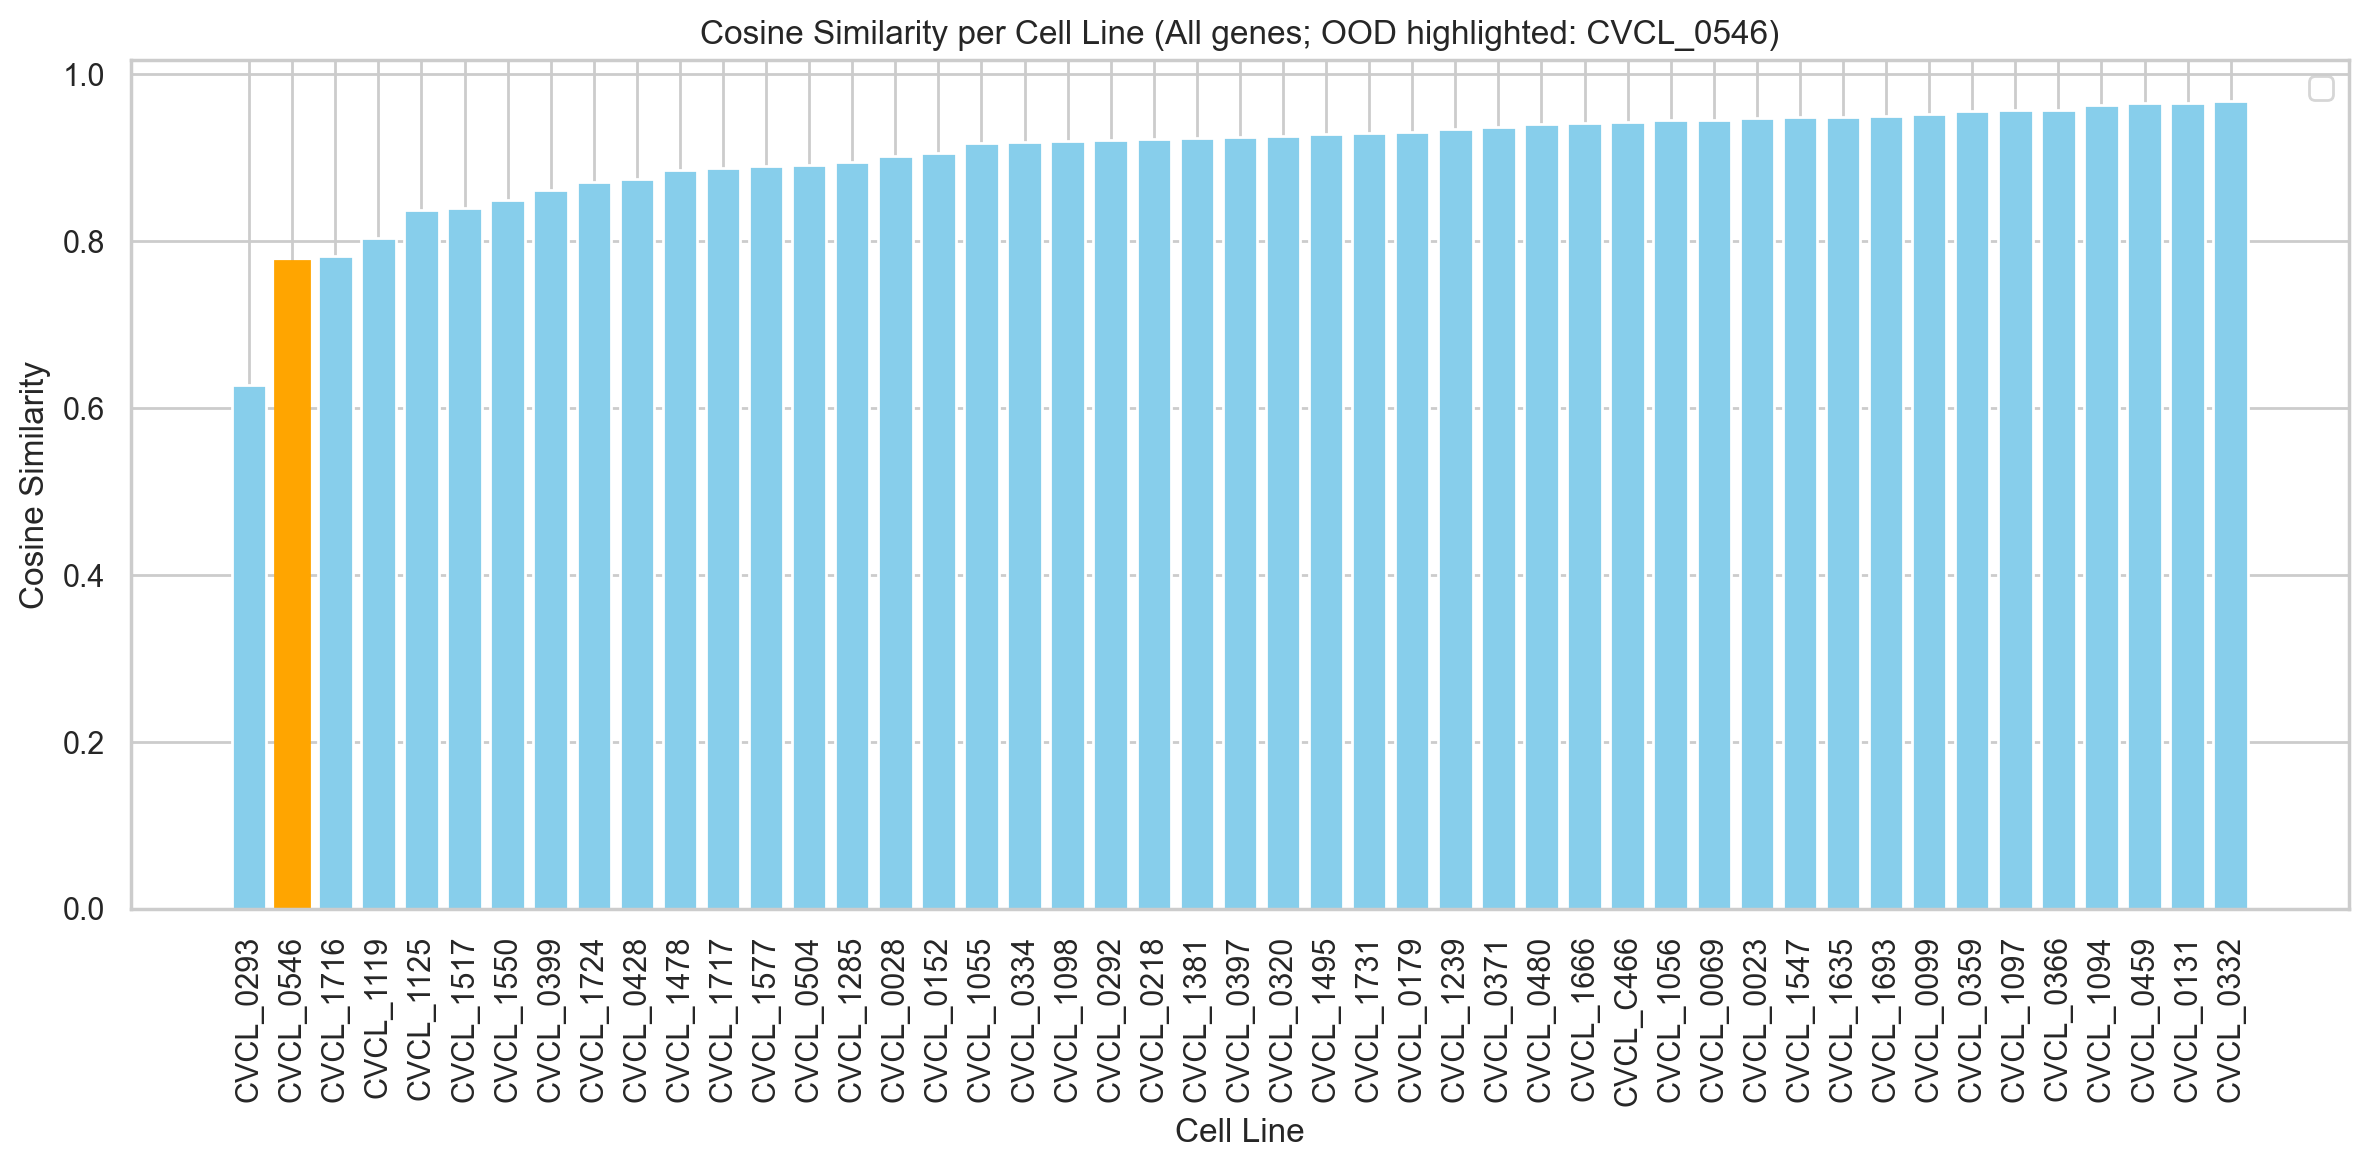

In [46]:
deg_to_plot = "all"  # choose from {10, 20, 50, "all"}

if str(deg_to_plot).lower() == "all":
    mask_deg = df["n_top_deg"].isna() | df["n_top_deg"].astype(str).str.lower().eq("all")
    df_use = df[mask_deg]
else:
    df_use = df[df["n_top_deg"].astype(str) == str(deg_to_plot)]

cosine_per_cell = df_use.groupby('cell_type')['cosine_sim'].mean().sort_values()

plt.figure(figsize=(12, 6))
bars = plt.bar(cosine_per_cell.index, cosine_per_cell.values, color='skyblue')

# Highlight OOD in orange
for bar, cell in zip(bars, cosine_per_cell.index):
    if cell == ood_cell_line:
        bar.set_color('orange')

title_deg = "All genes" if str(deg_to_plot).lower() == "all" else f"DEGs = {deg_to_plot}"
plt.title(f"Cosine Similarity per Cell Line ({title_deg}; OOD highlighted: {ood_cell_line})")
plt.ylabel("Cosine Similarity")  # (on LFC, if that's your setup)
plt.xlabel("Cell Line")
plt.xticks(rotation=90)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


### R² score 
(coefficient of determination) measures how much of the variance in the observed data is explained by the predictions.

R² > 0.5: Generally good alignment.

R²= 1 Perfect prediction (predicted values match true vaαlues exactly).

Mean R² (mean expression) across all cell lines: 0.9456127641048837


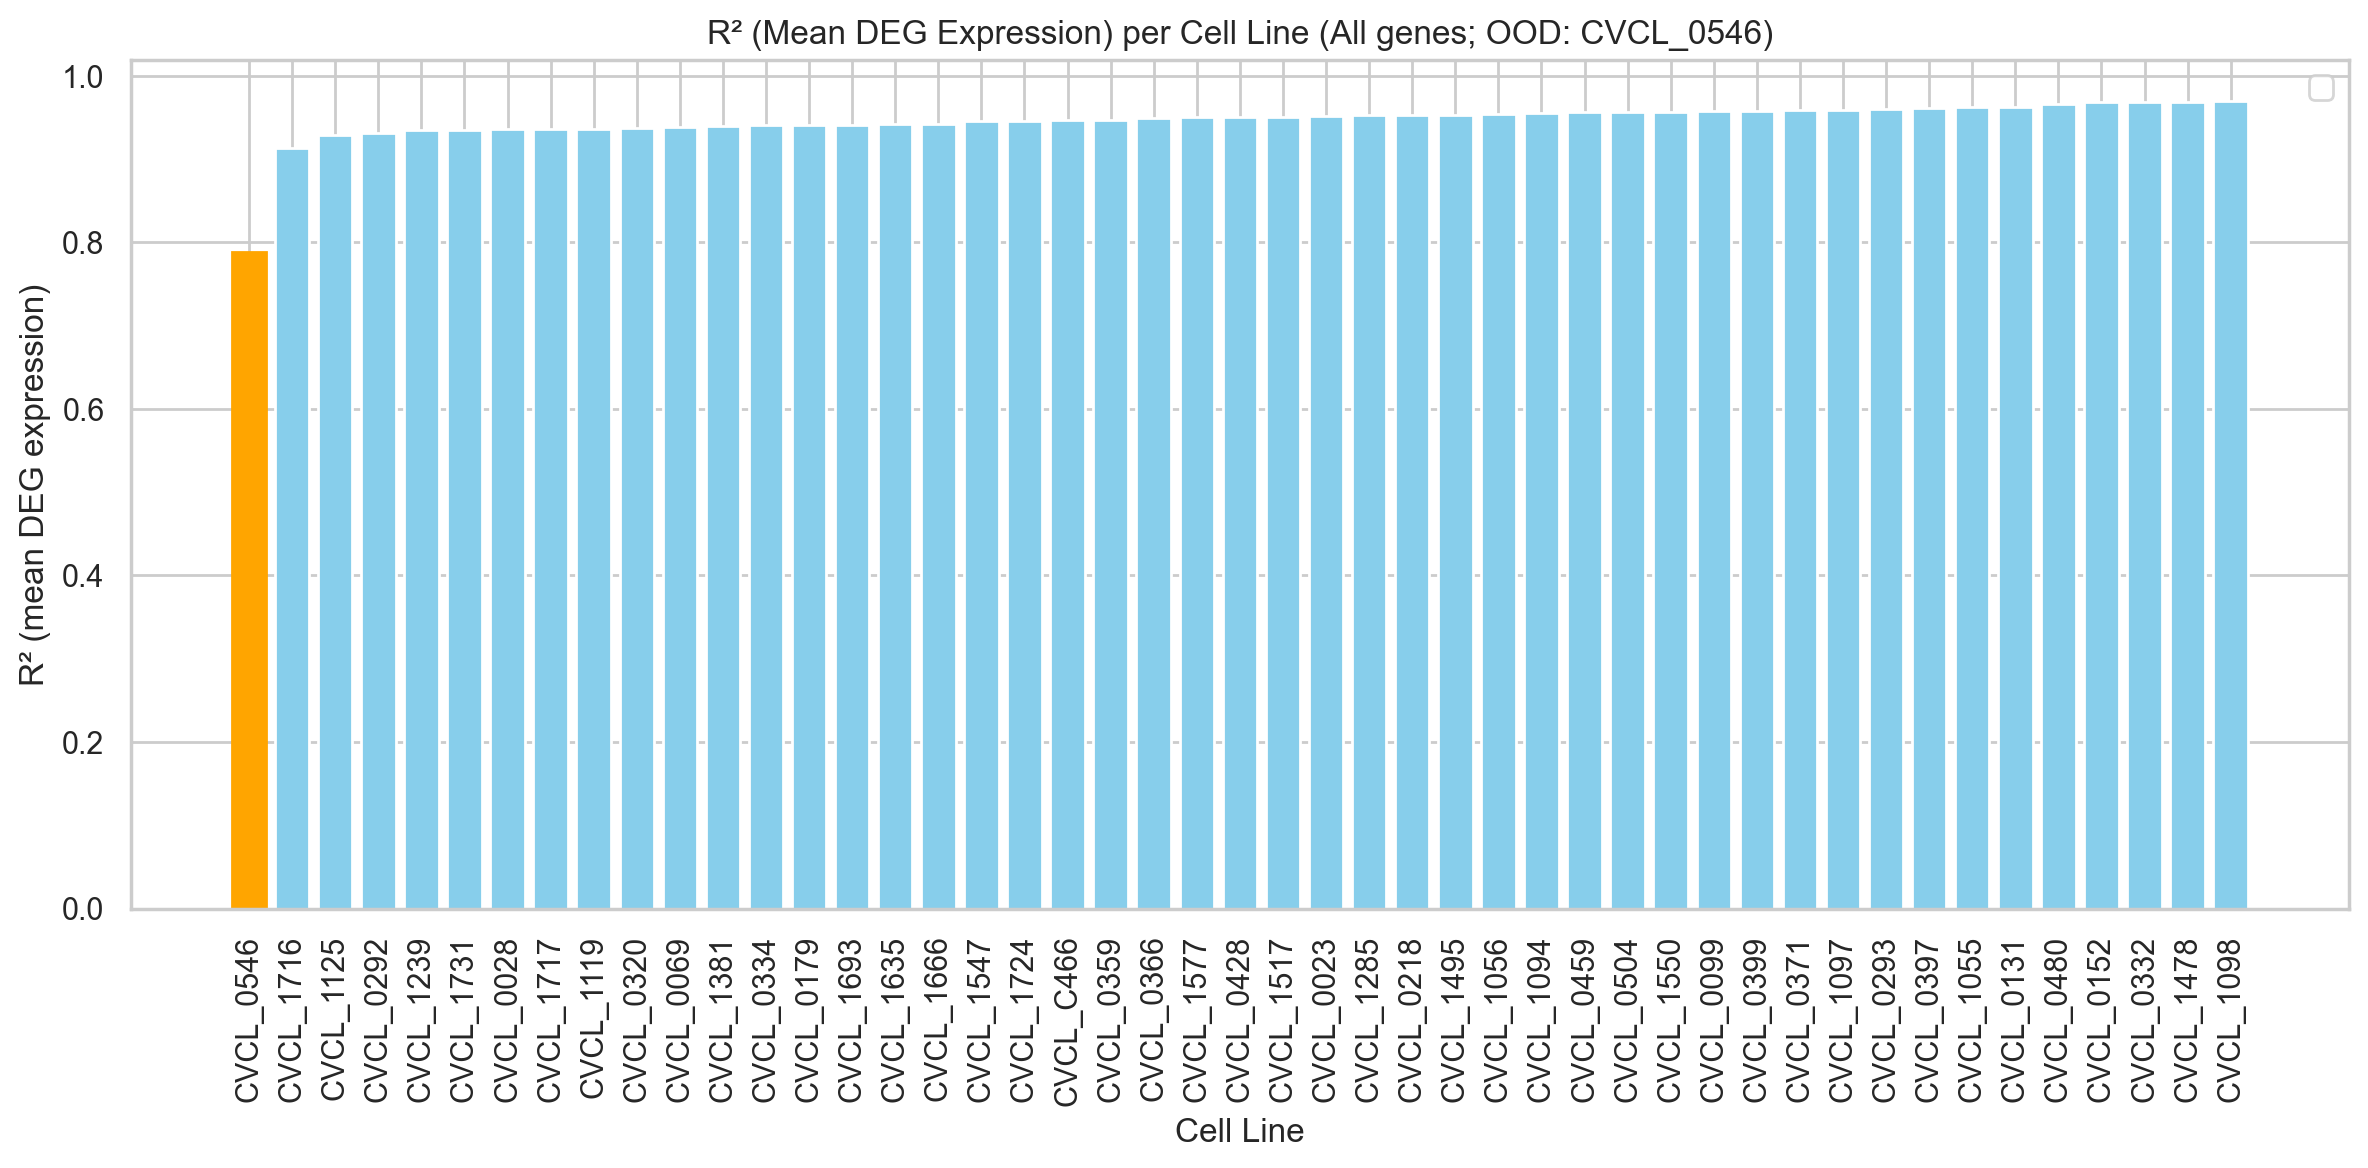

In [47]:
deg_to_plot = "all"  # choose from {10, 20, 50, "all"}

if str(deg_to_plot).lower() == "all":
    mask_deg = df["n_top_deg"].isna() | df["n_top_deg"].astype(str).str.lower().eq("all")
    df_use = df[mask_deg]
else:
    df_use = df[df["n_top_deg"].astype(str) == str(deg_to_plot)]

mean_r2_mean_deg = df_use['r2_mean_deg'].mean()
print("Mean R² (mean expression) across all cell lines:", mean_r2_mean_deg)

r2_mean_per_cell = df_use.groupby('cell_type')['r2_mean_deg'].mean().sort_values()

plt.figure(figsize=(12, 6))
bars = plt.bar(r2_mean_per_cell.index, r2_mean_per_cell.values, color='skyblue')

# Highlight OOD cell line
ood_cell_line = 'CVCL_0546'
for bar, cell in zip(bars, r2_mean_per_cell.index):
    if cell == ood_cell_line:
        bar.set_color('orange')

title_deg = "All genes" if str(deg_to_plot).lower() == "all" else f"DEGs = {deg_to_plot}"
plt.title(f"R² (Mean DEG Expression) per Cell Line ({title_deg}; OOD: {ood_cell_line})")
plt.ylabel("R² (mean DEG expression)")
plt.xlabel("Cell Line")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()



###  E-distance (energy distance)

Distance between two probability distributions (e.g., predicted vs observed gene expression distributions).

Smaller values close to 0 indicate good alighnment.

Mean E-Distance across all cell lines: 0.015036129238010017


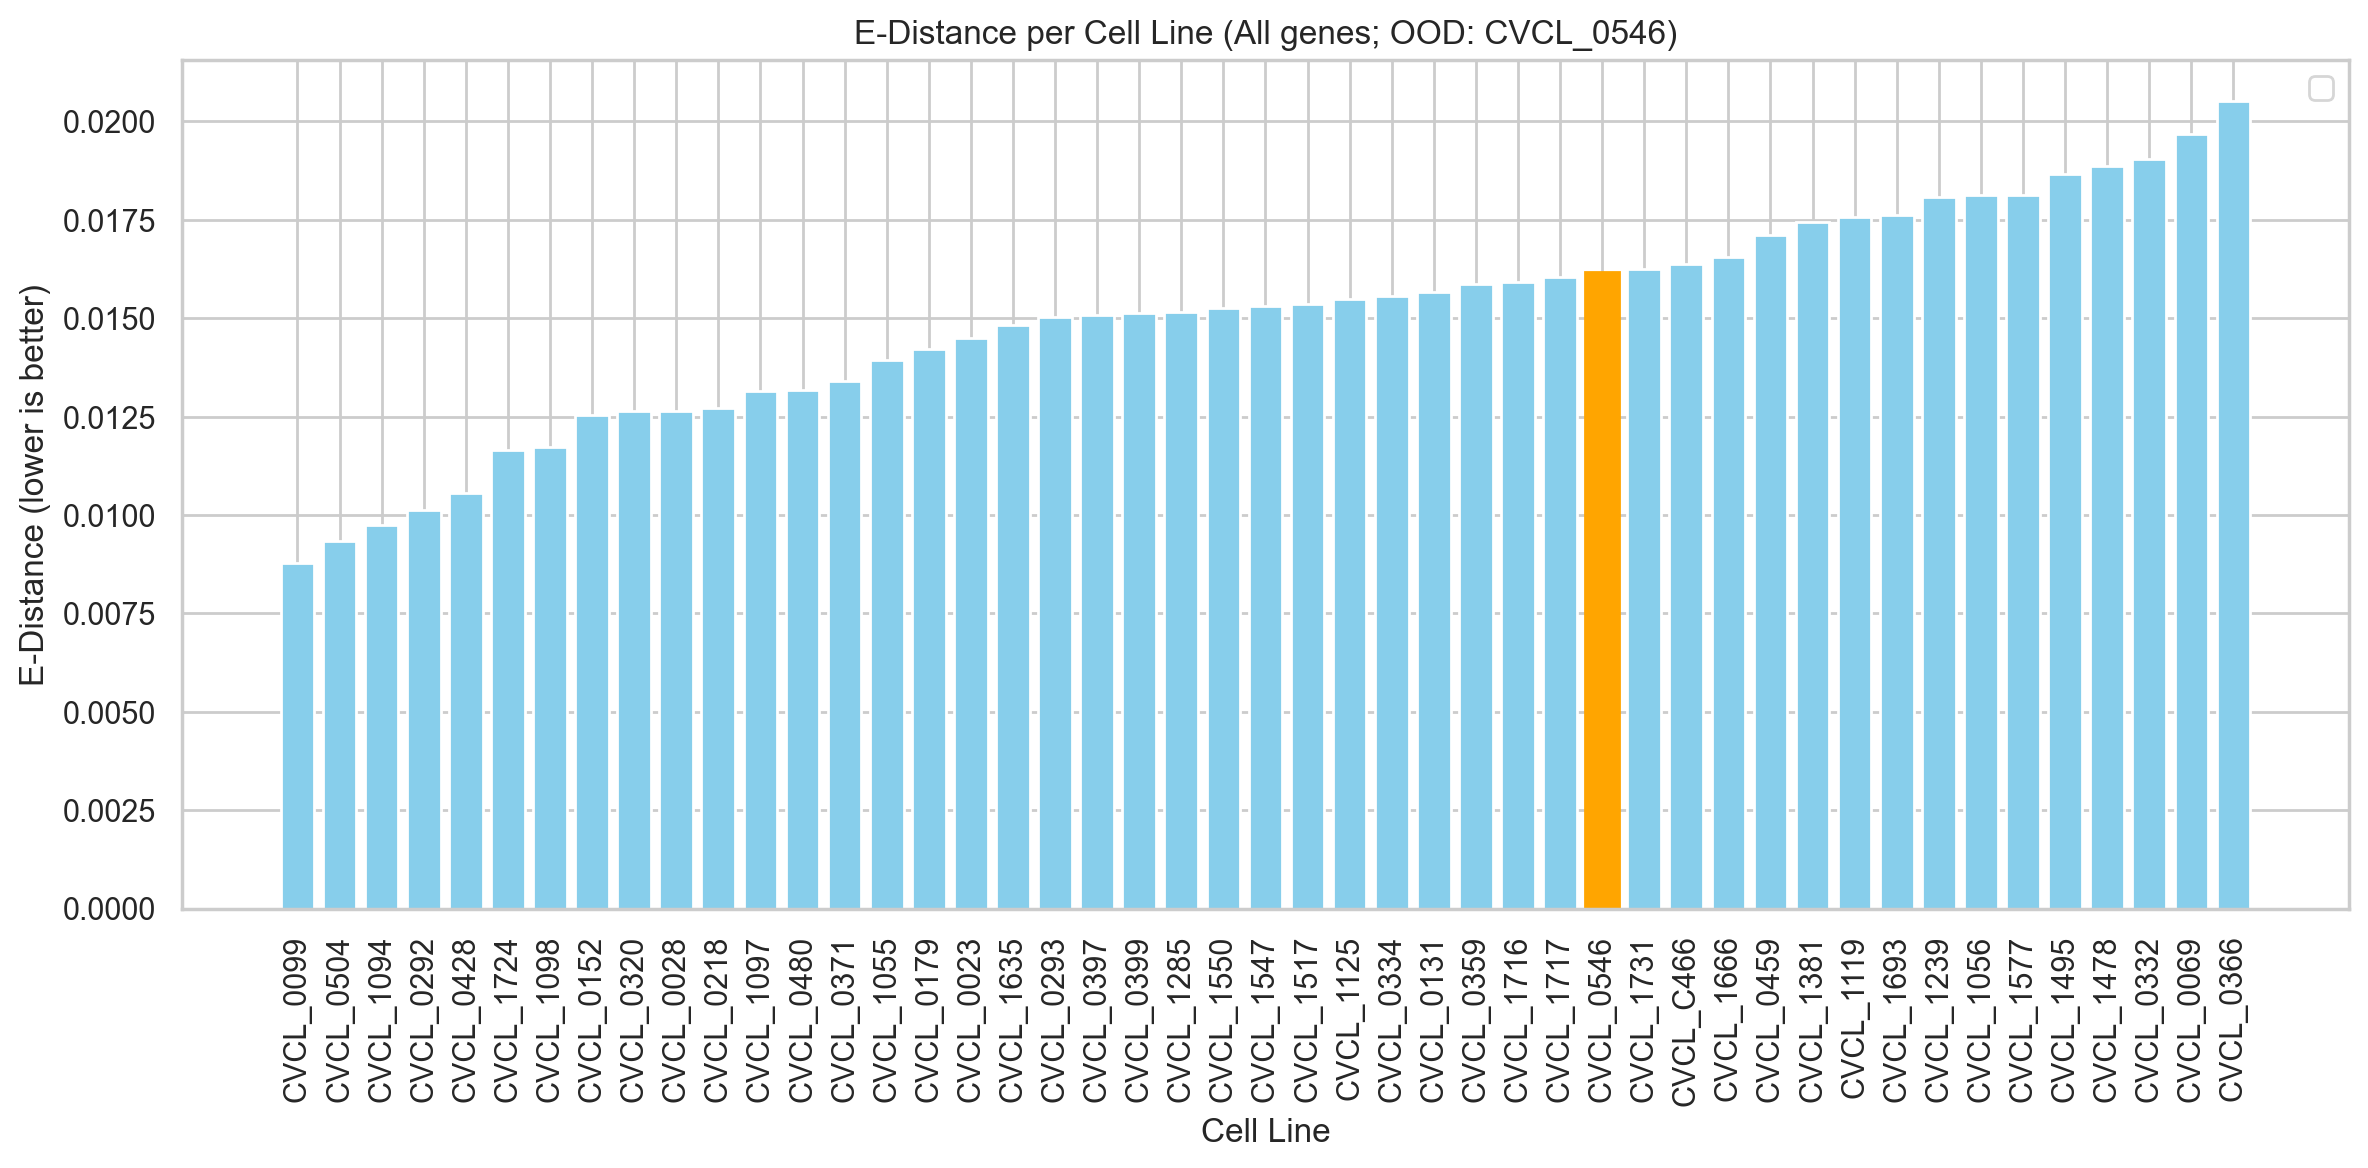

In [48]:
deg_to_plot = "all"  # choose from {10, 20, 50, "all"}

if str(deg_to_plot).lower() == "all":
    mask_deg = df["n_top_deg"].isna() | df["n_top_deg"].astype(str).str.lower().eq("all")
    df_use = df[mask_deg]
else:
    df_use = df[df["n_top_deg"].astype(str) == str(deg_to_plot)]

mean_e_dist = df_use['e_distance'].mean()
print("Mean E-Distance across all cell lines:", mean_e_dist)

e_dist_per_cell = df_use.groupby('cell_type')['e_distance'].mean().sort_values()

plt.figure(figsize=(12, 6))
bars = plt.bar(e_dist_per_cell.index, e_dist_per_cell.values, color='skyblue')

# Highlight OOD cell line
ood_cell_line = 'CVCL_0546'  # ensure this matches your OOD line
for bar, cell in zip(bars, e_dist_per_cell.index):
    if cell == ood_cell_line:
        bar.set_color('orange')


title_deg = "All genes" if str(deg_to_plot).lower() == "all" else f"DEGs = {deg_to_plot}"
plt.title(f"E-Distance per Cell Line ({title_deg}; OOD: {ood_cell_line})")
plt.ylabel("E-Distance (lower is better)")
plt.xlabel("Cell Line")
plt.xticks(rotation=90)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


## Visualisation of the Dataset


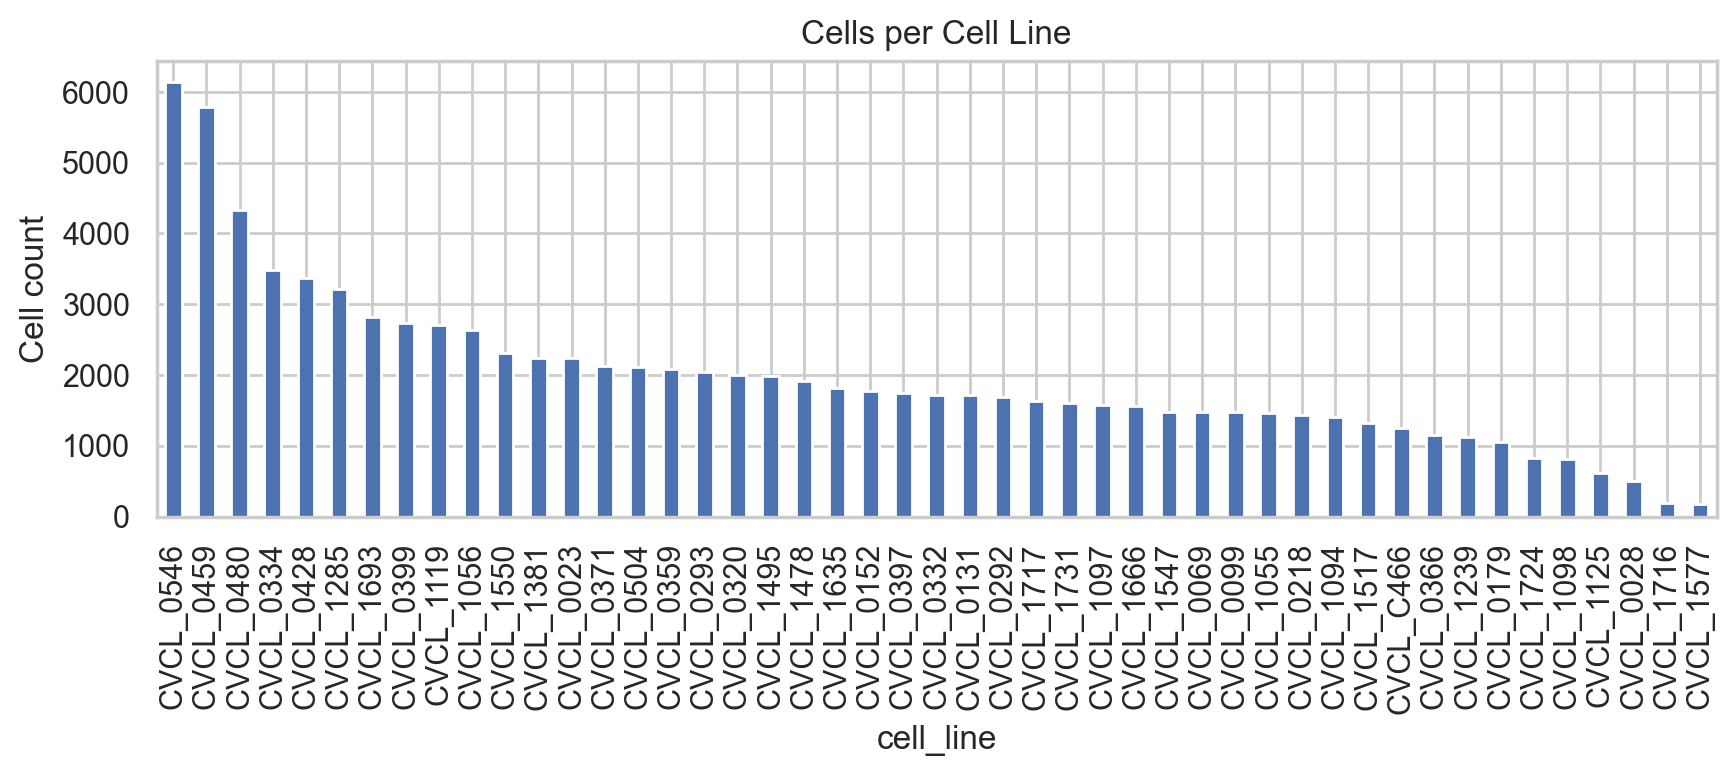

In [49]:
# Barplot: Cells per cell line
adata.obs['cell_line'].value_counts().plot.bar(figsize=(10,3), title='Cells per Cell Line')
plt.ylabel('Cell count')
plt.show()


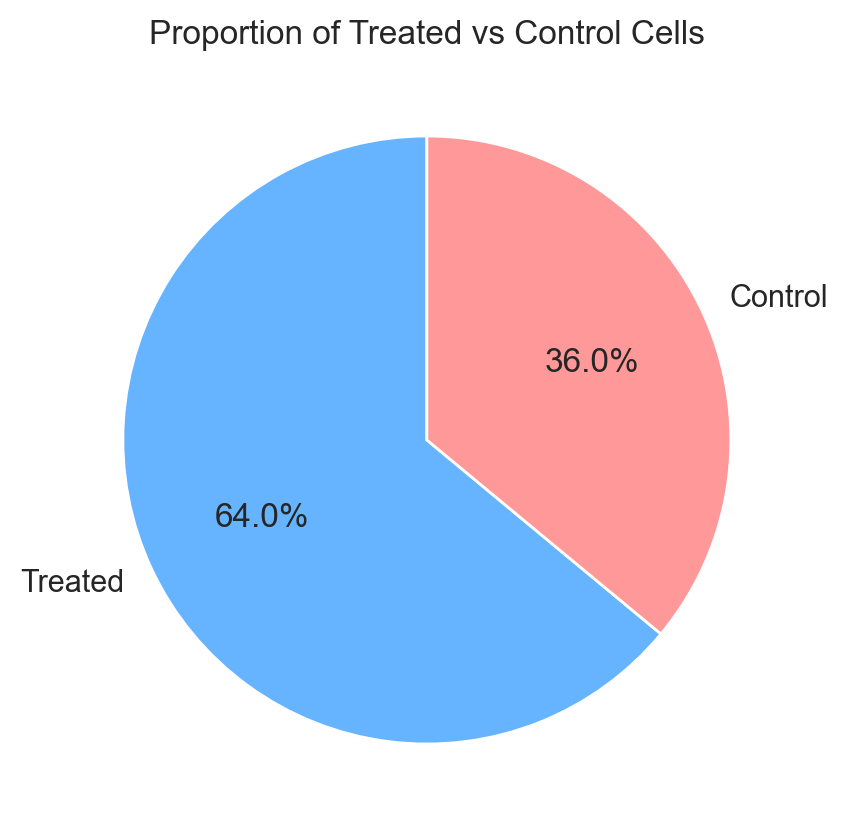

In [50]:
# Create a simplified column with labels "Treated" or "Control"
adata.obs['treatment_group'] = adata.obs['condition'].apply(lambda x: 'Control' if x == 'ctrl' else 'Treated')

# Count Treated vs Control
group_counts = adata.obs['treatment_group'].value_counts()

# Plot the pie chart
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
group_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Proportion of Treated vs Control Cells')
plt.ylabel('')  # Hides the y-axis label
plt.show()


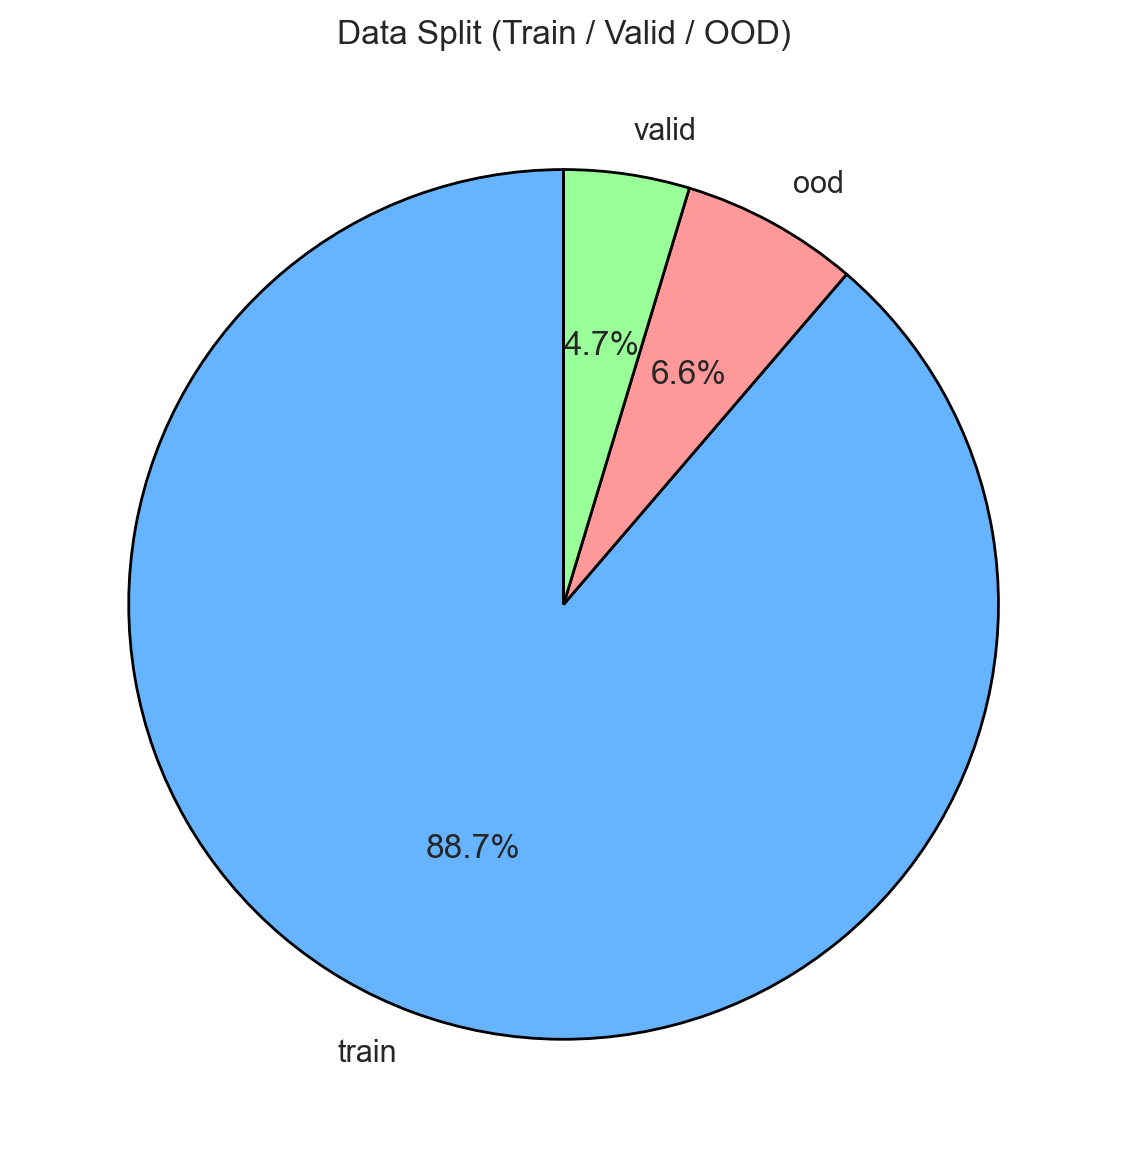

In [51]:
# Get value counts for each split
split_counts = adata.obs['split_CVCL_0546'].value_counts()

# Plot pie chart
plt.figure(figsize=(6, 6))
split_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff', '#ff9999', '#99ff99'],  # Optional: custom colors
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Data Split (Train / Valid / OOD)')
plt.ylabel('')  # Hide y-axis label
plt.tight_layout()
plt.show()


In [52]:
pert_counts = adata.obs['condition'].value_counts()


## Visialization of results

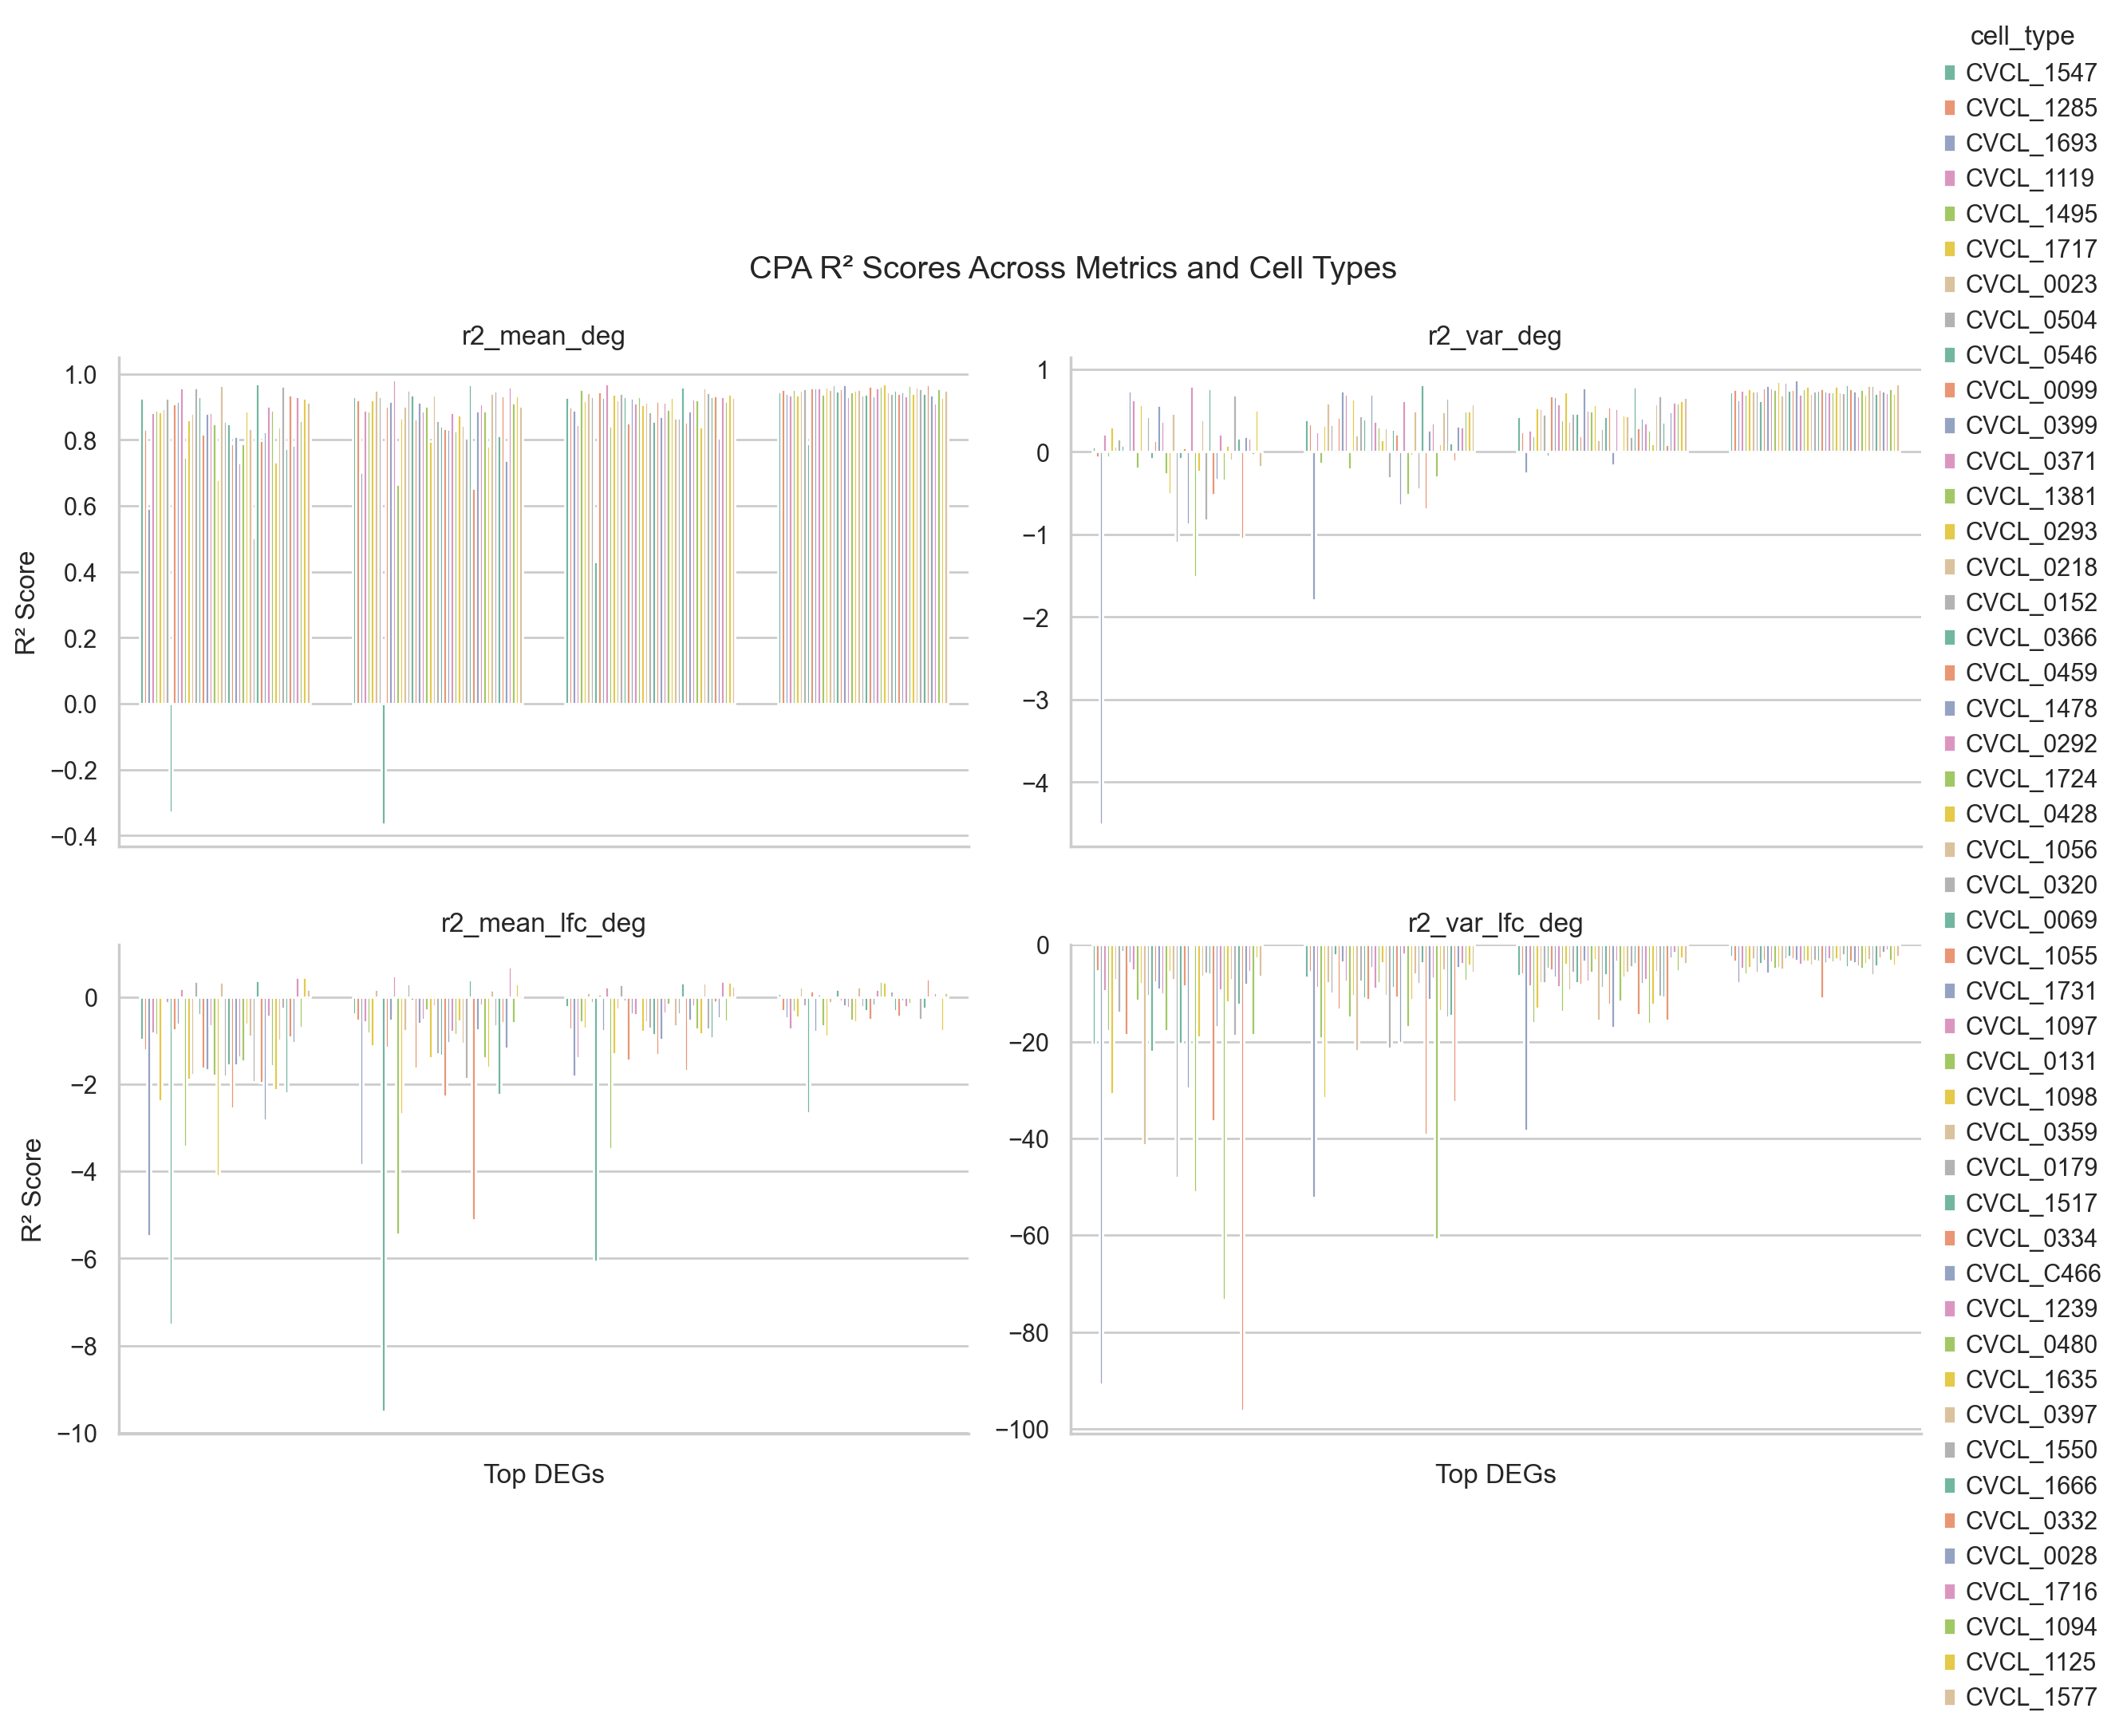

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named `df`

# Convert to long format
df_melted = df.melt(
    id_vars=["condition", "cell_type", "n_top_deg"],
    value_vars=[
        "r2_mean_deg", "r2_var_deg",
        "r2_mean_lfc_deg", "r2_var_lfc_deg"
    ],
    var_name="metric",
    value_name="R2_score"
)

# Plot
sns.set(style="whitegrid", context="notebook")
g = sns.catplot(
    data=df_melted,
    x="n_top_deg", y="R2_score",
    hue="cell_type",
    col="metric",
    kind="bar",
    col_wrap=2,
    height=4, aspect=1.5,
    palette="Set2",
    sharey=False
)

g.set_titles("{col_name}")
g.set_axis_labels("Top DEGs", "R² Score")
g.set_xticklabels(rotation=45)
plt.subplots_adjust(top=0.9)
g.fig.suptitle("CPA R² Scores Across Metrics and Cell Types")
plt.show()


## Plotting: Compare OOD vs ID performance

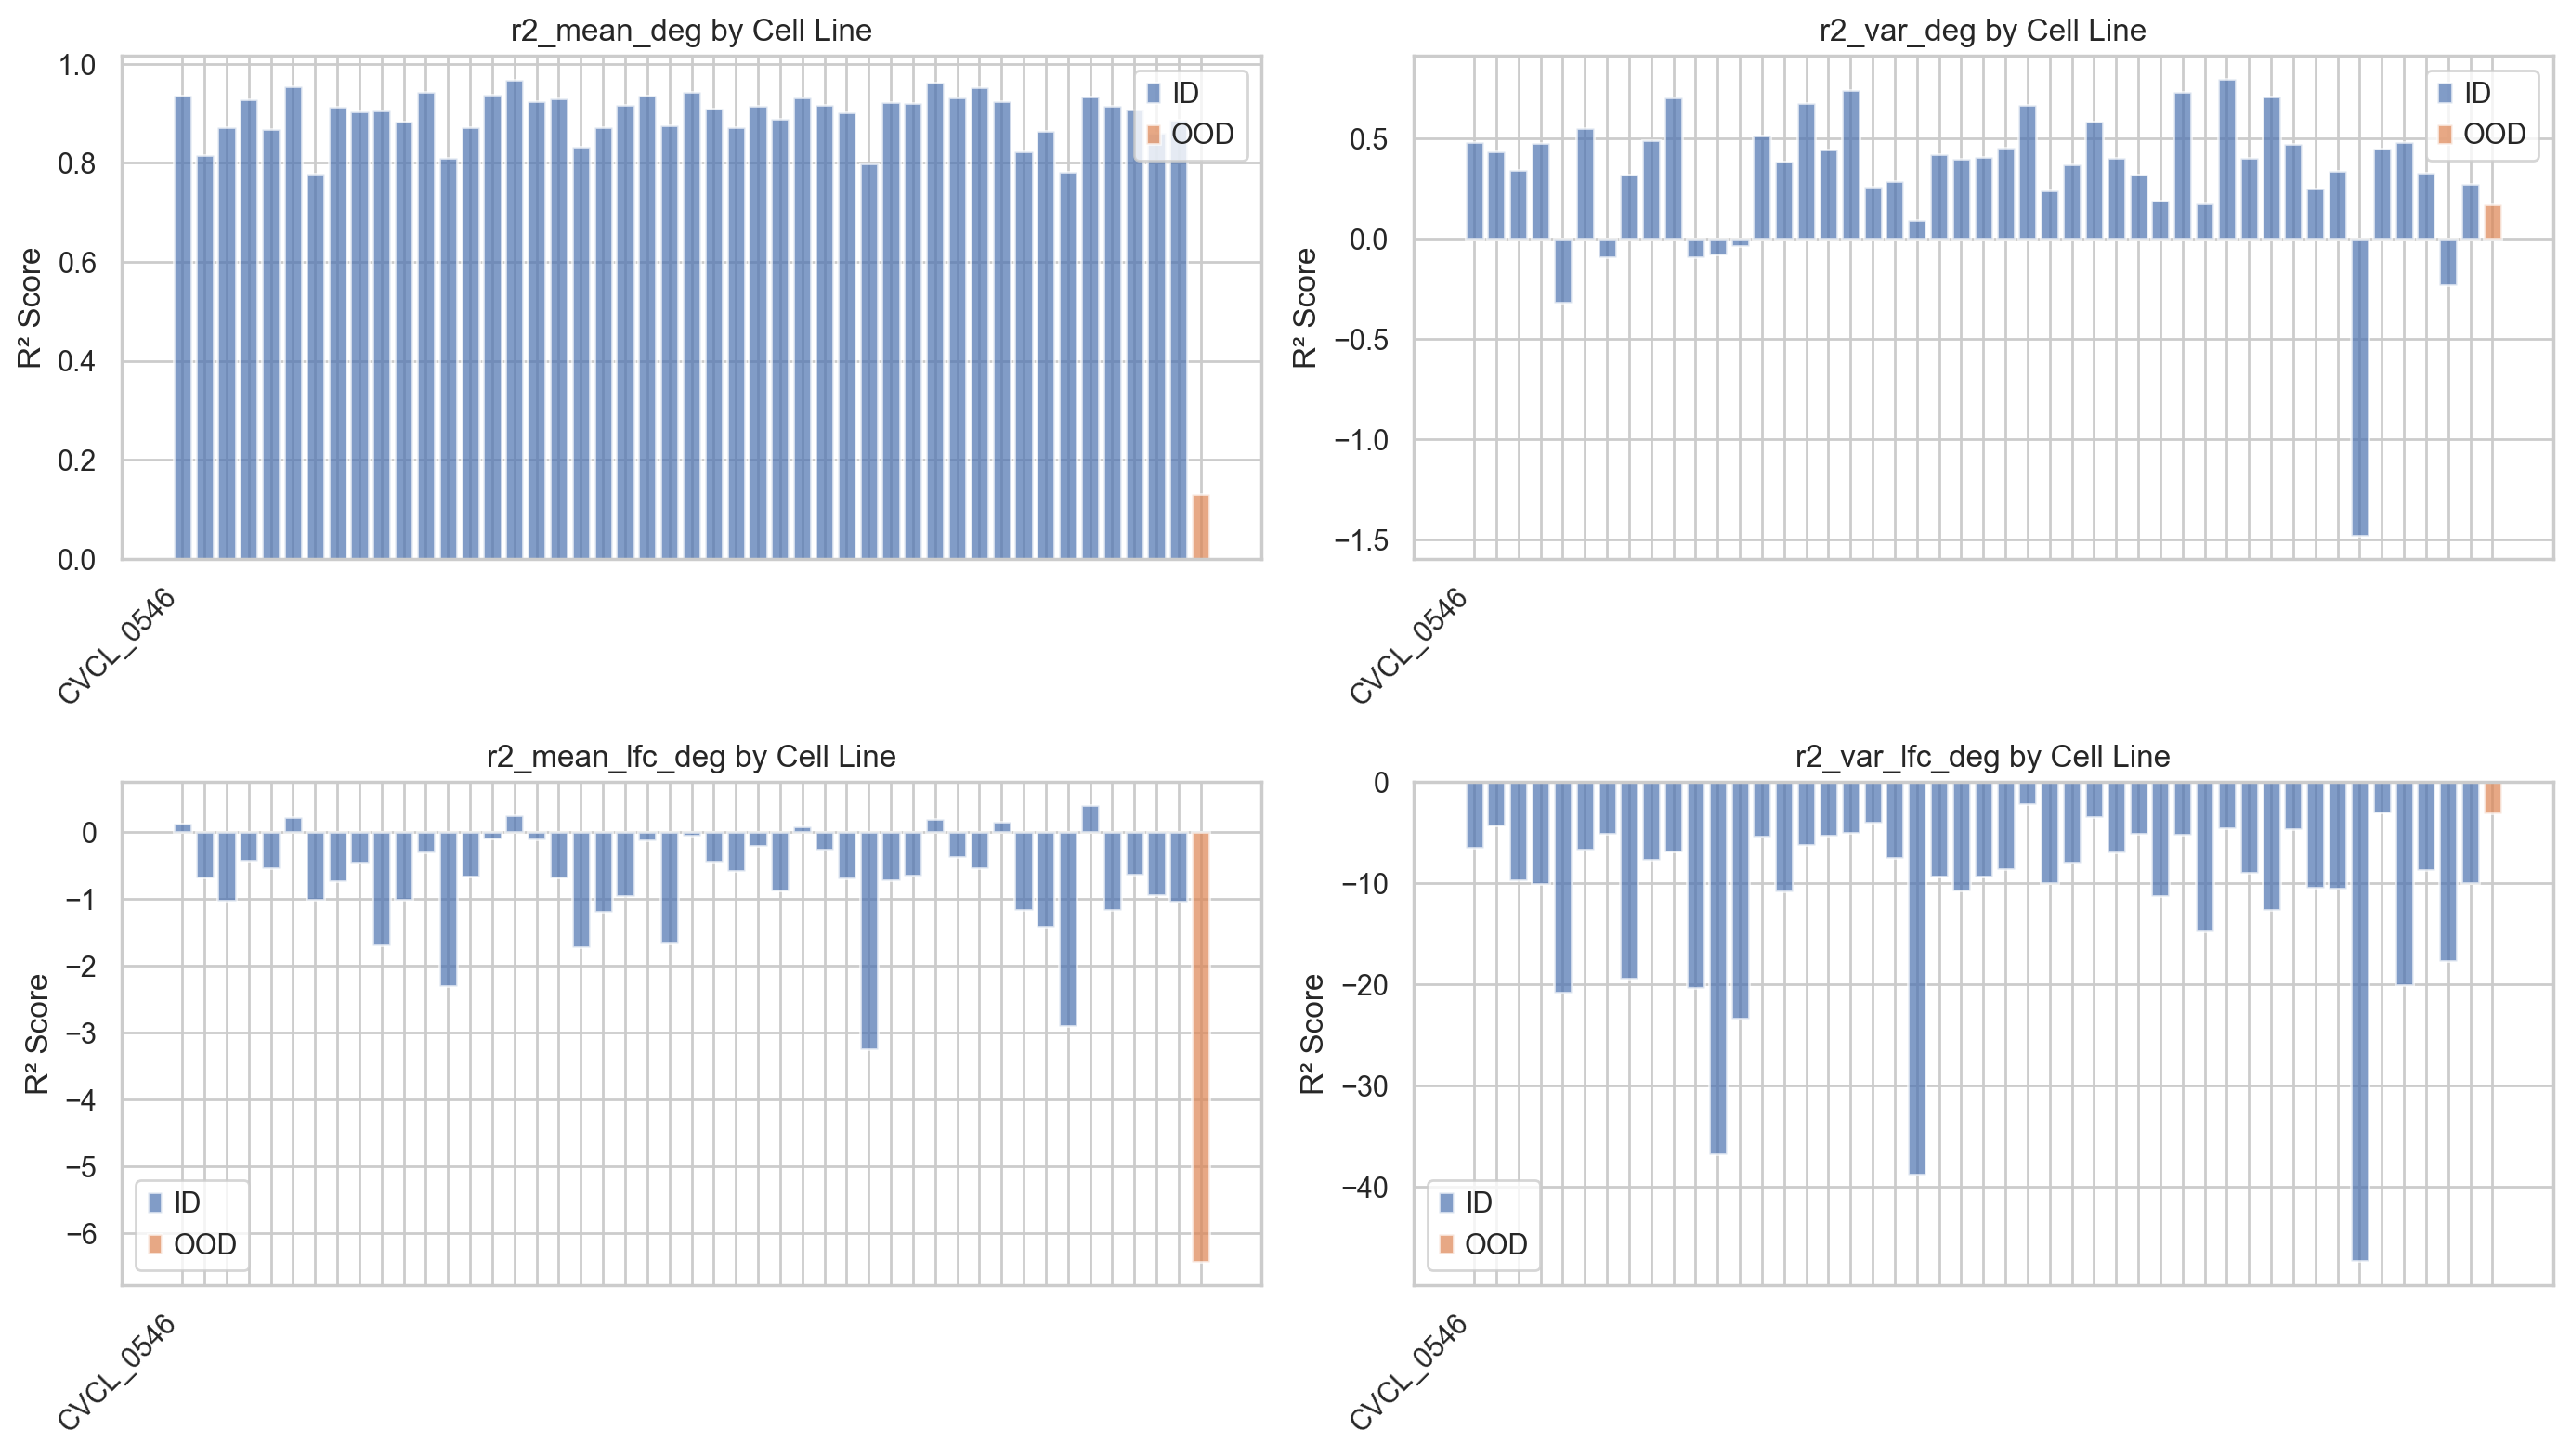

In [54]:
# Assume df already exists and contains R² results
# Define OOD cell line
ood_cell_line = "CVCL_0546"

# Mark whether each row is OOD or not
df['is_ood'] = df['cell_type'] == ood_cell_line

# Define metrics to visualize
metrics = ['r2_mean_deg', 'r2_var_deg', 'r2_mean_lfc_deg', 'r2_var_lfc_deg']
ncols = 2
nrows = (len(metrics) + 1) // ncols

# Create subplots
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows))
axs = axs.flatten()

# Plot each metric
for i, metric in enumerate(metrics):
    ax = axs[i]
    summary = df.groupby(['is_ood', 'cell_type'])[metric].mean().reset_index()
    summary['OOD status'] = summary['is_ood'].map({True: 'OOD', False: 'ID'})
    
    for ood_status, group in summary.groupby('OOD status'):
        ax.bar(group['cell_type'], group[metric], label=ood_status, alpha=0.7)

    ax.set_title(f"{metric} by Cell Line")
    ax.set_ylabel("R² Score")
    ax.set_xticklabels(group['cell_type'], rotation=45, ha='right')
    ax.legend()

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()


### CPA Prediction vs True for Stimulated per Cell Line
Diagonal alignment → Good agreement between CPA predictions and true data.

Points above the line → CPA overestimates gene expression.

Points below the line → CPA underestimates gene expression.

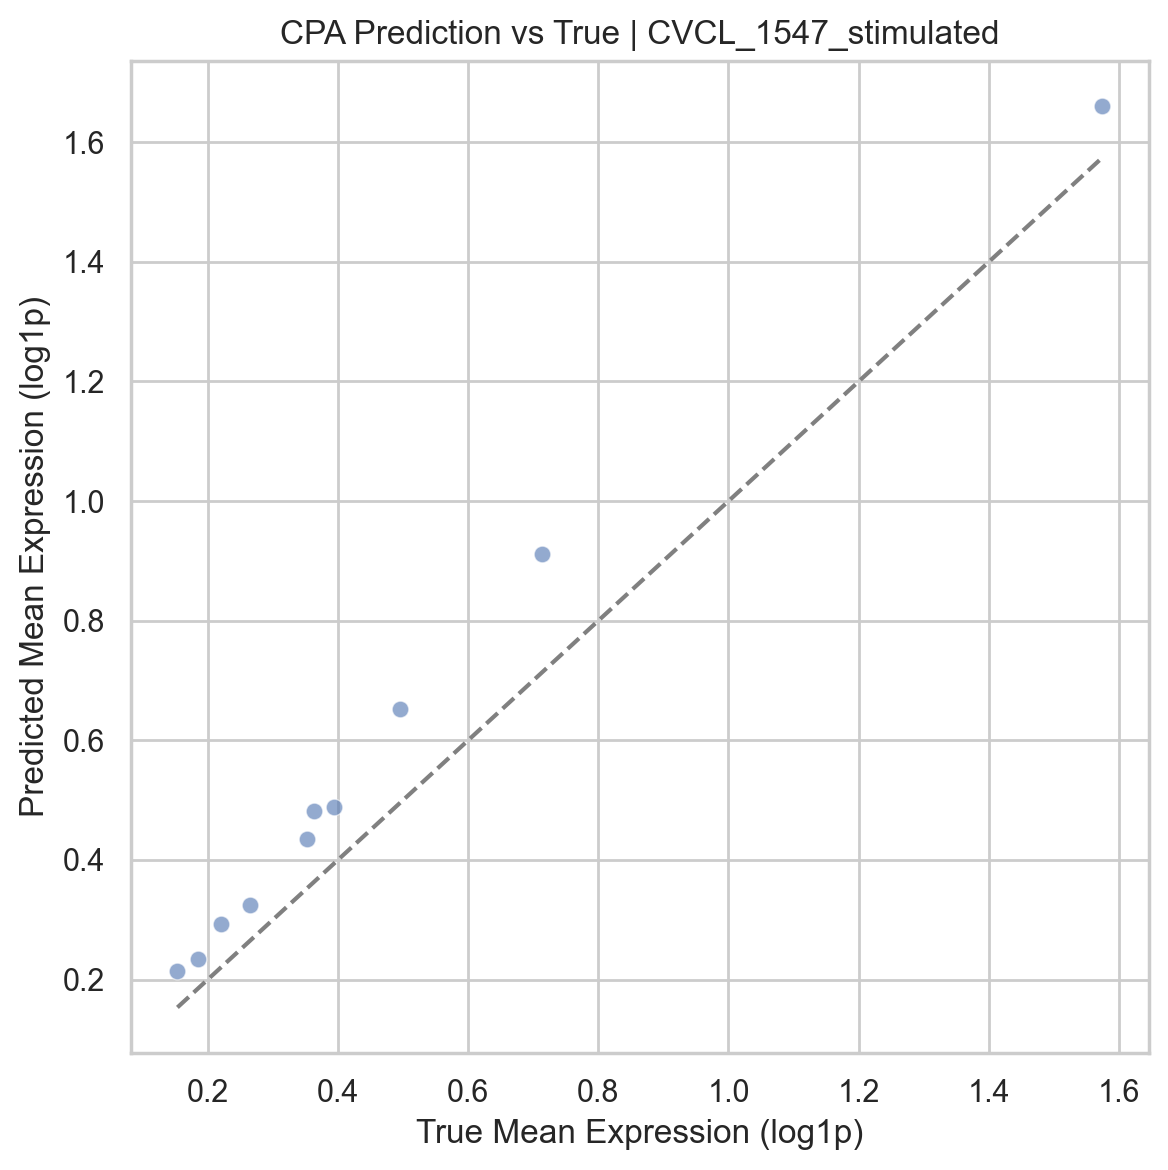

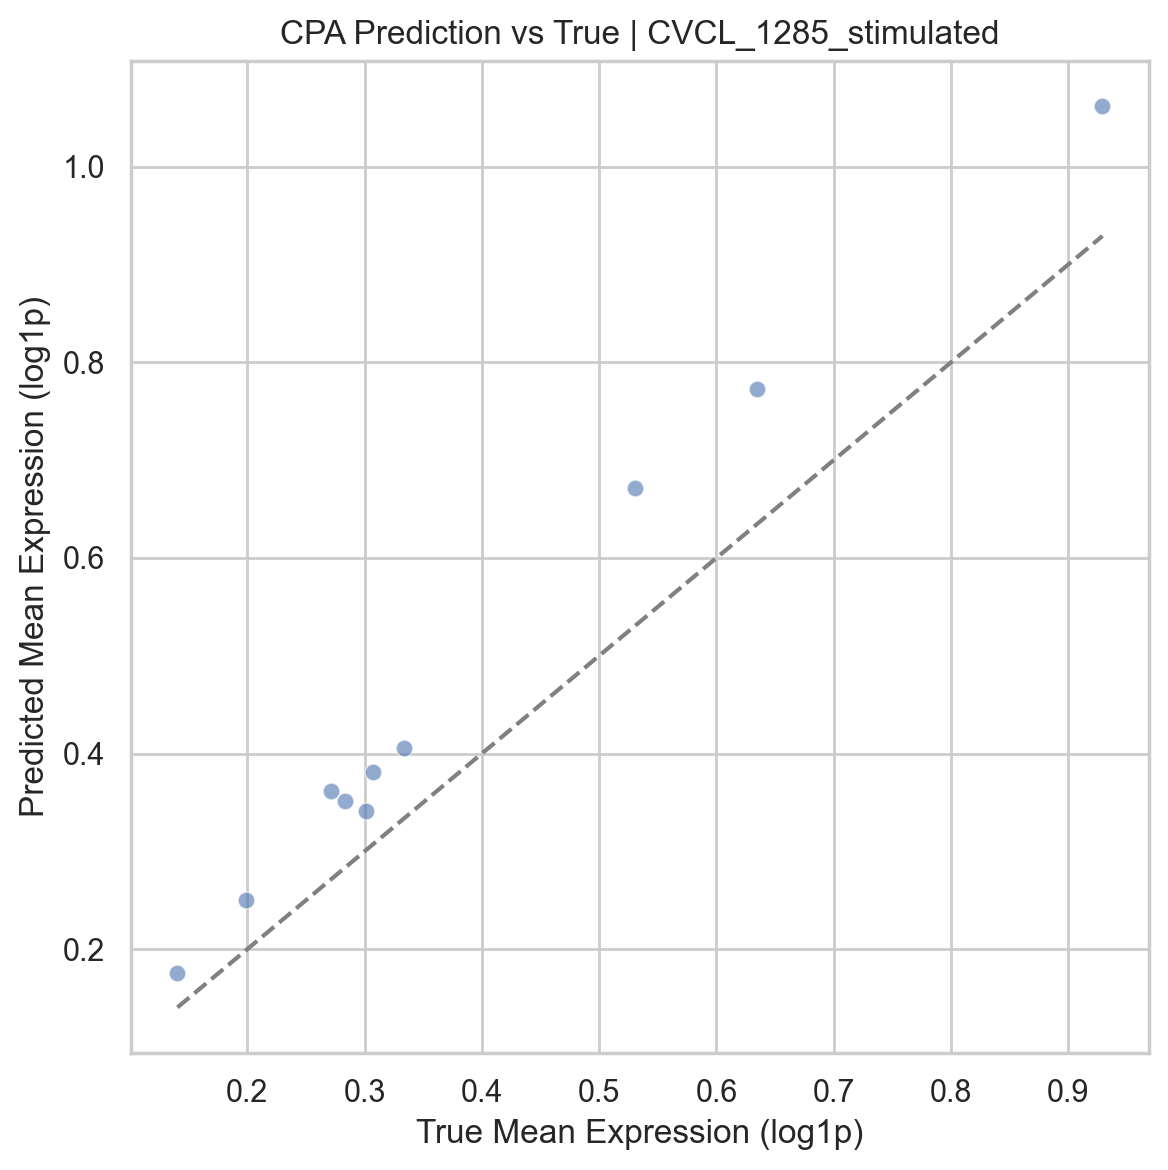

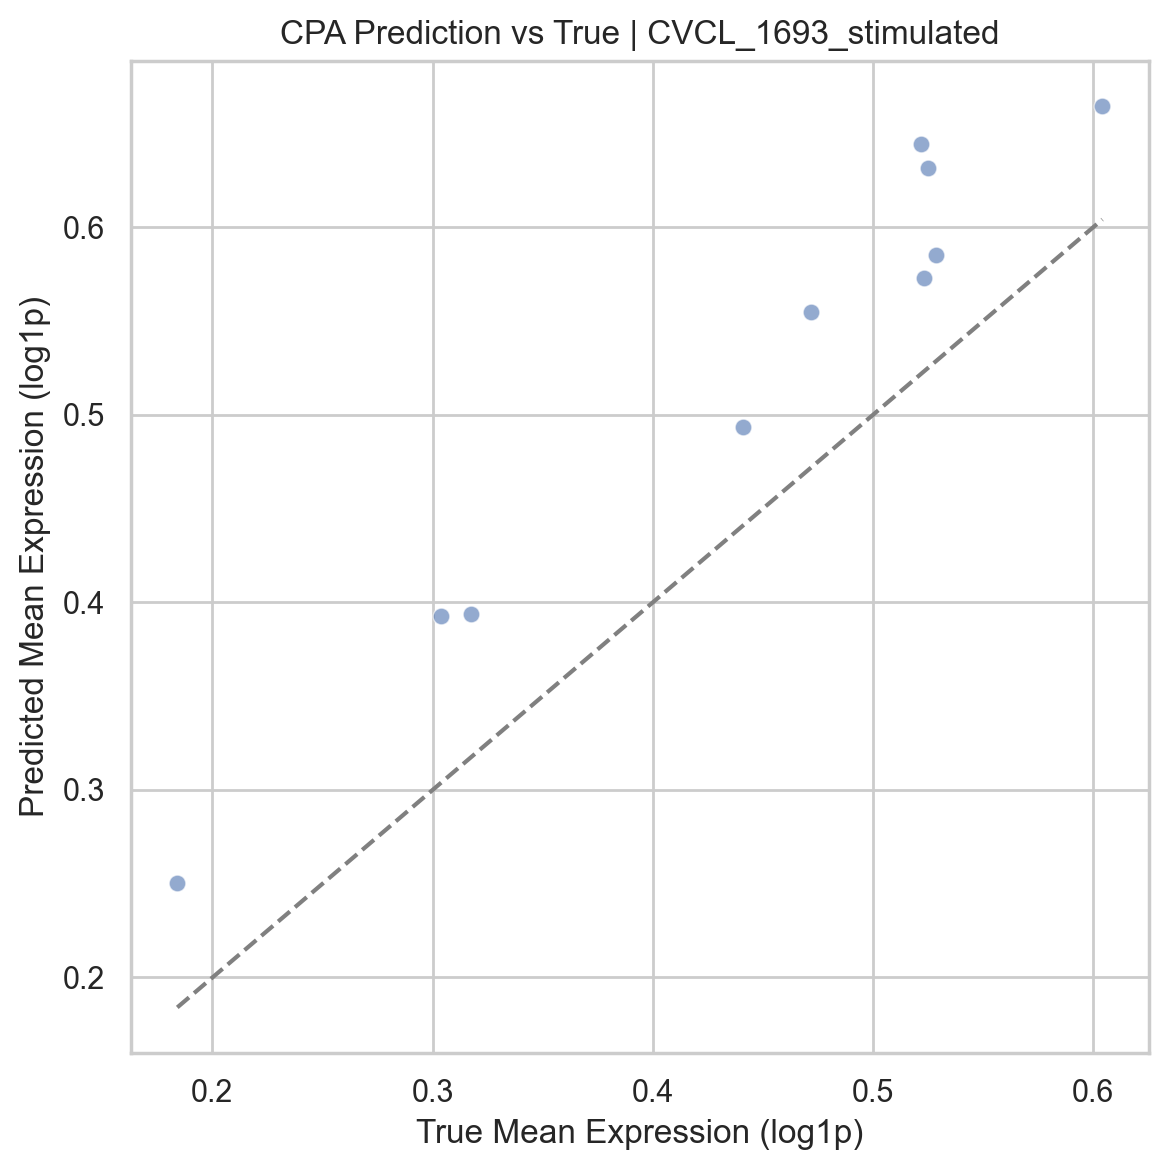

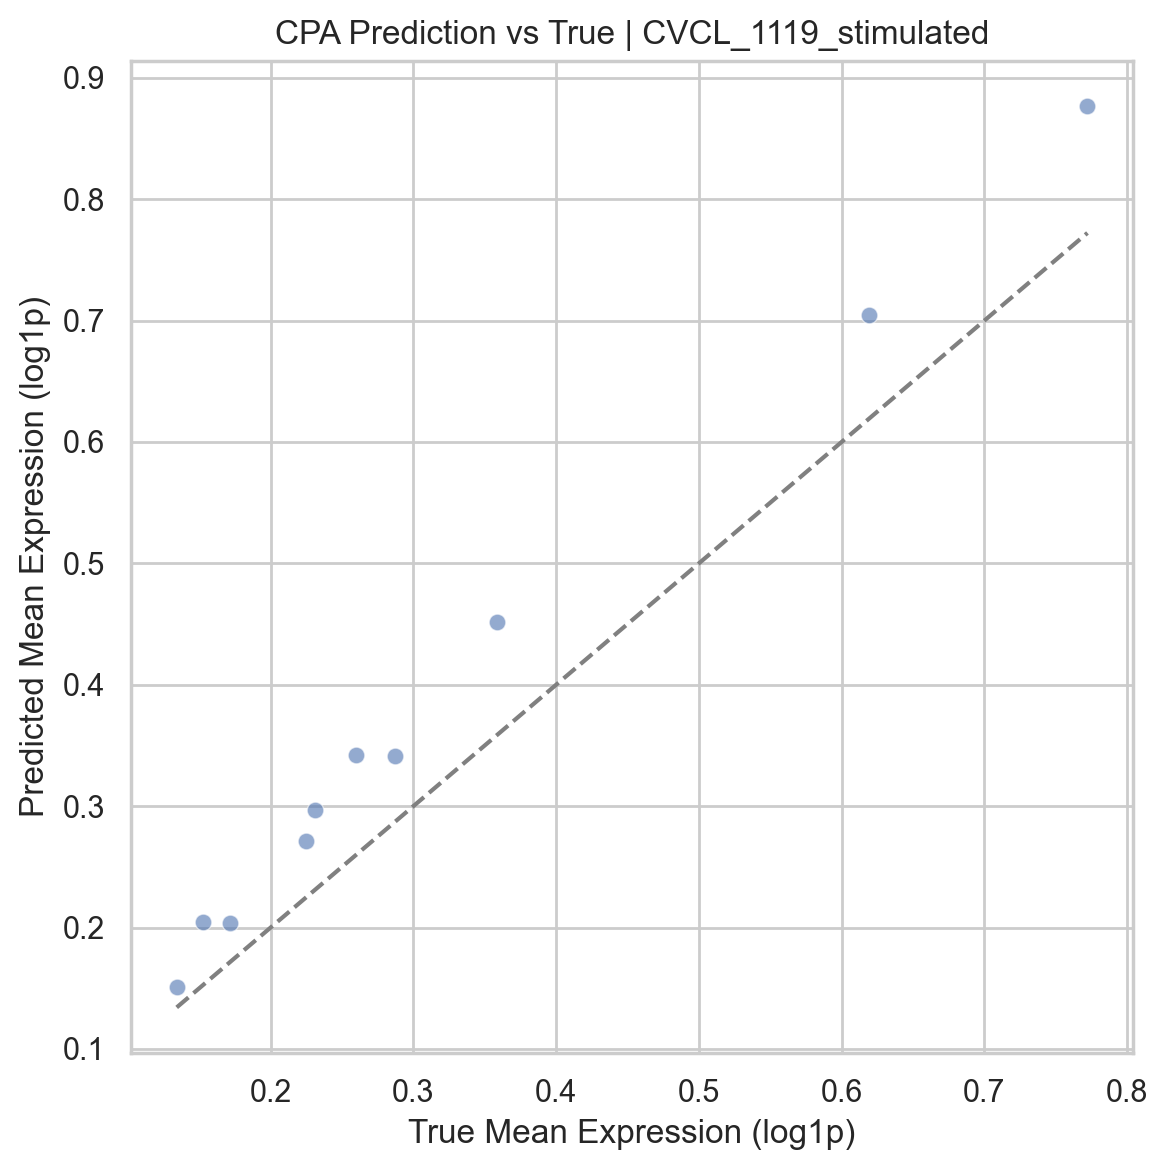

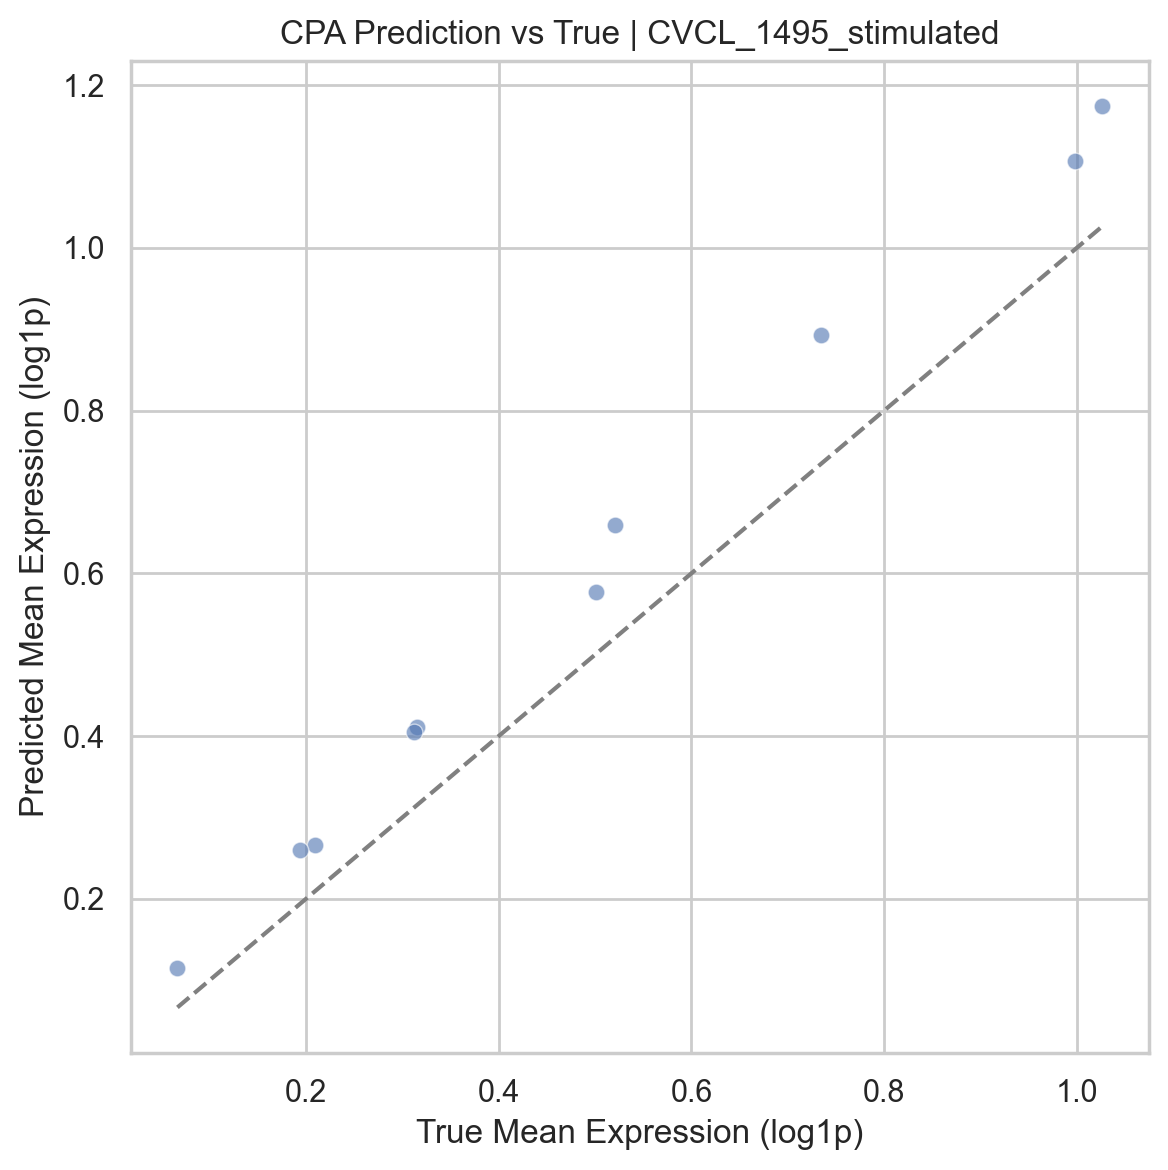

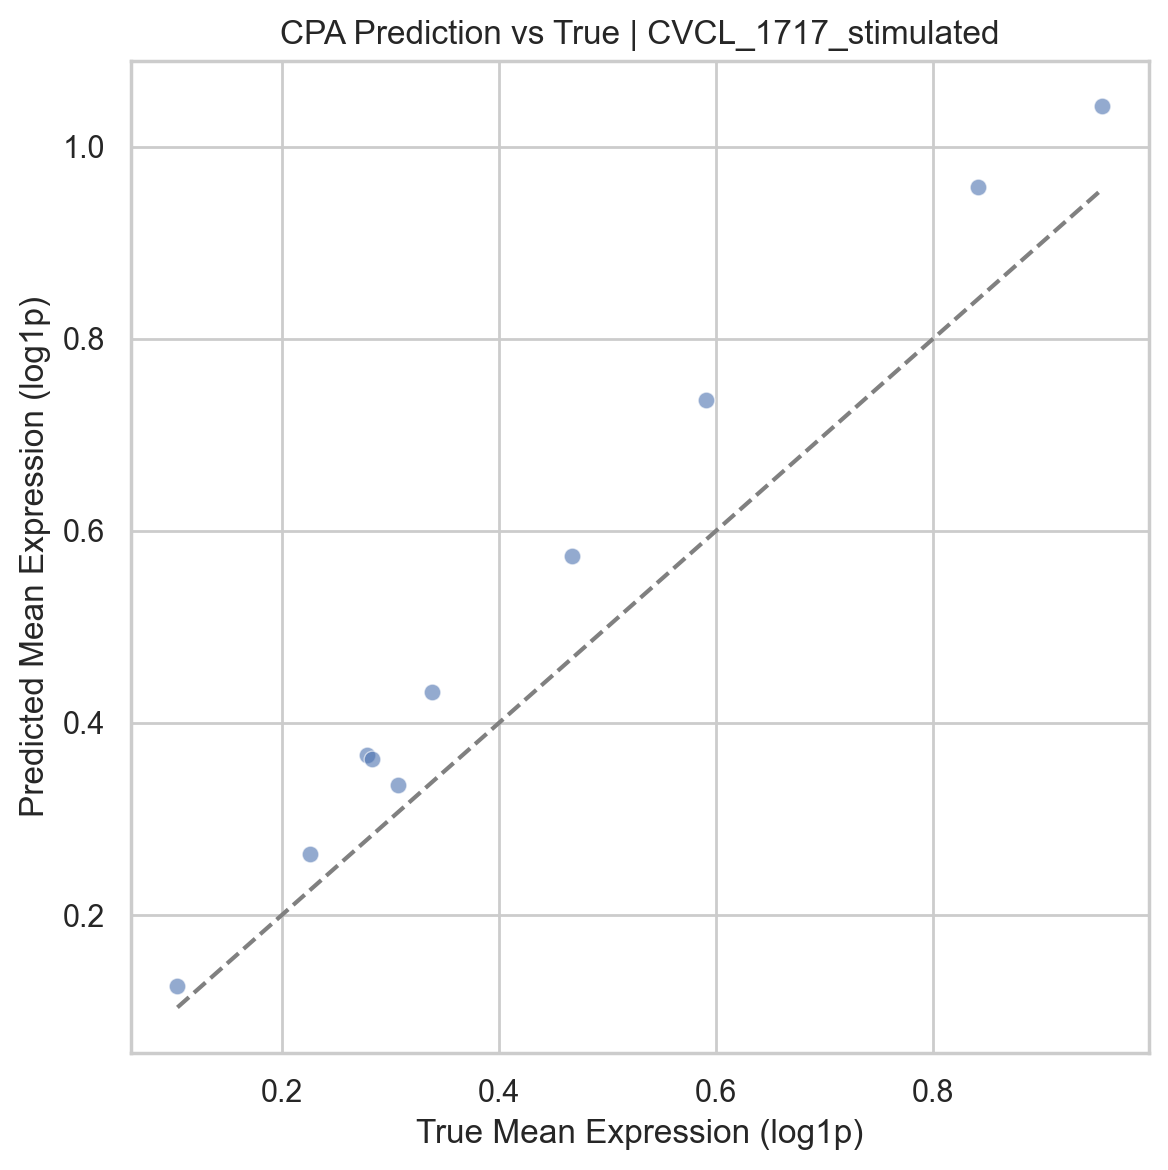

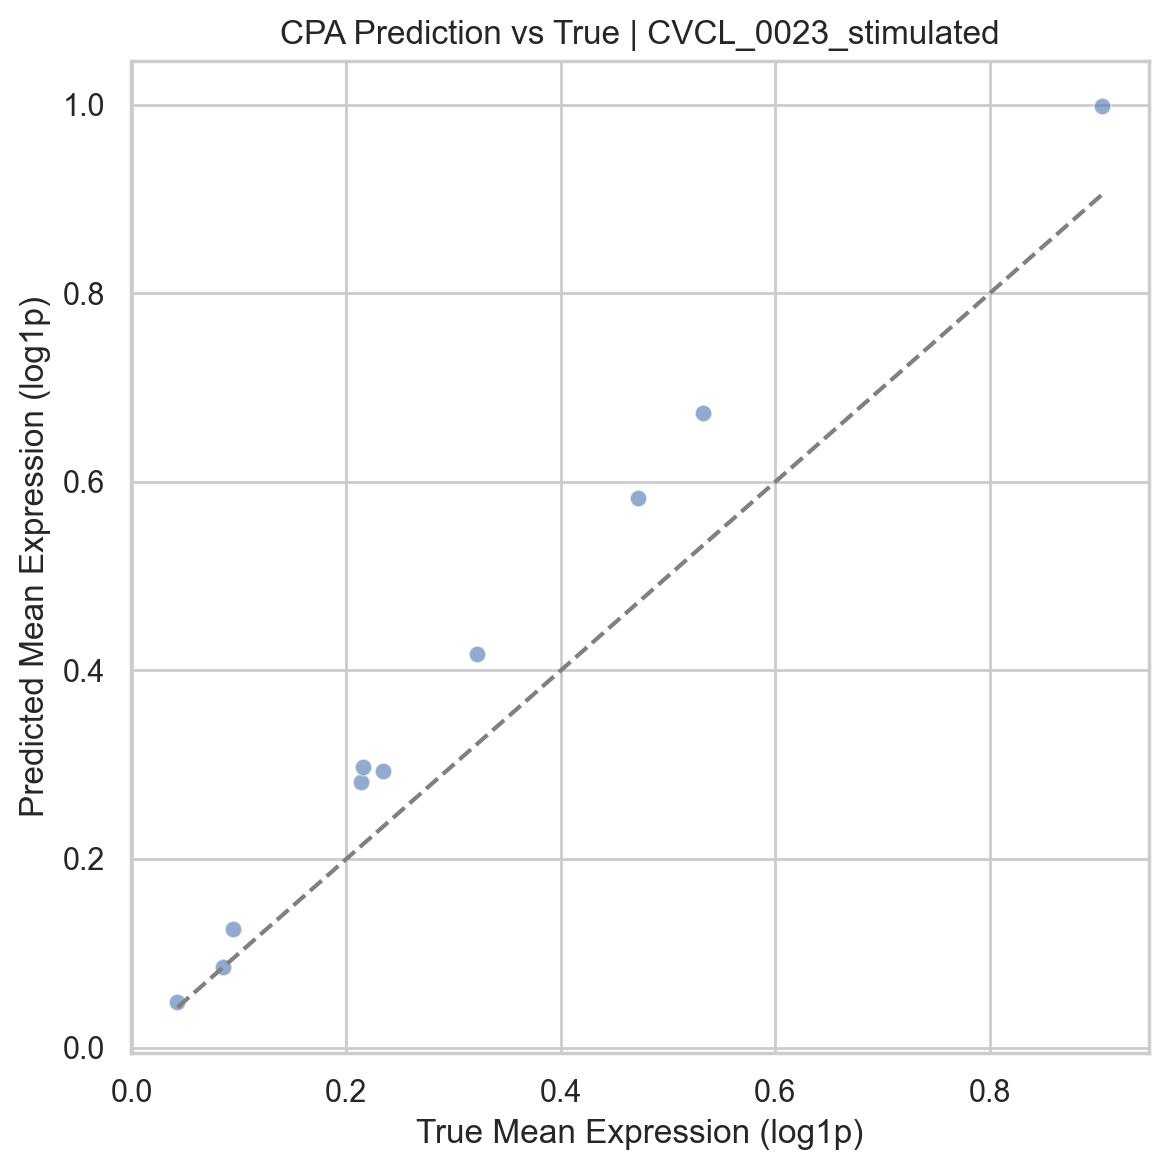

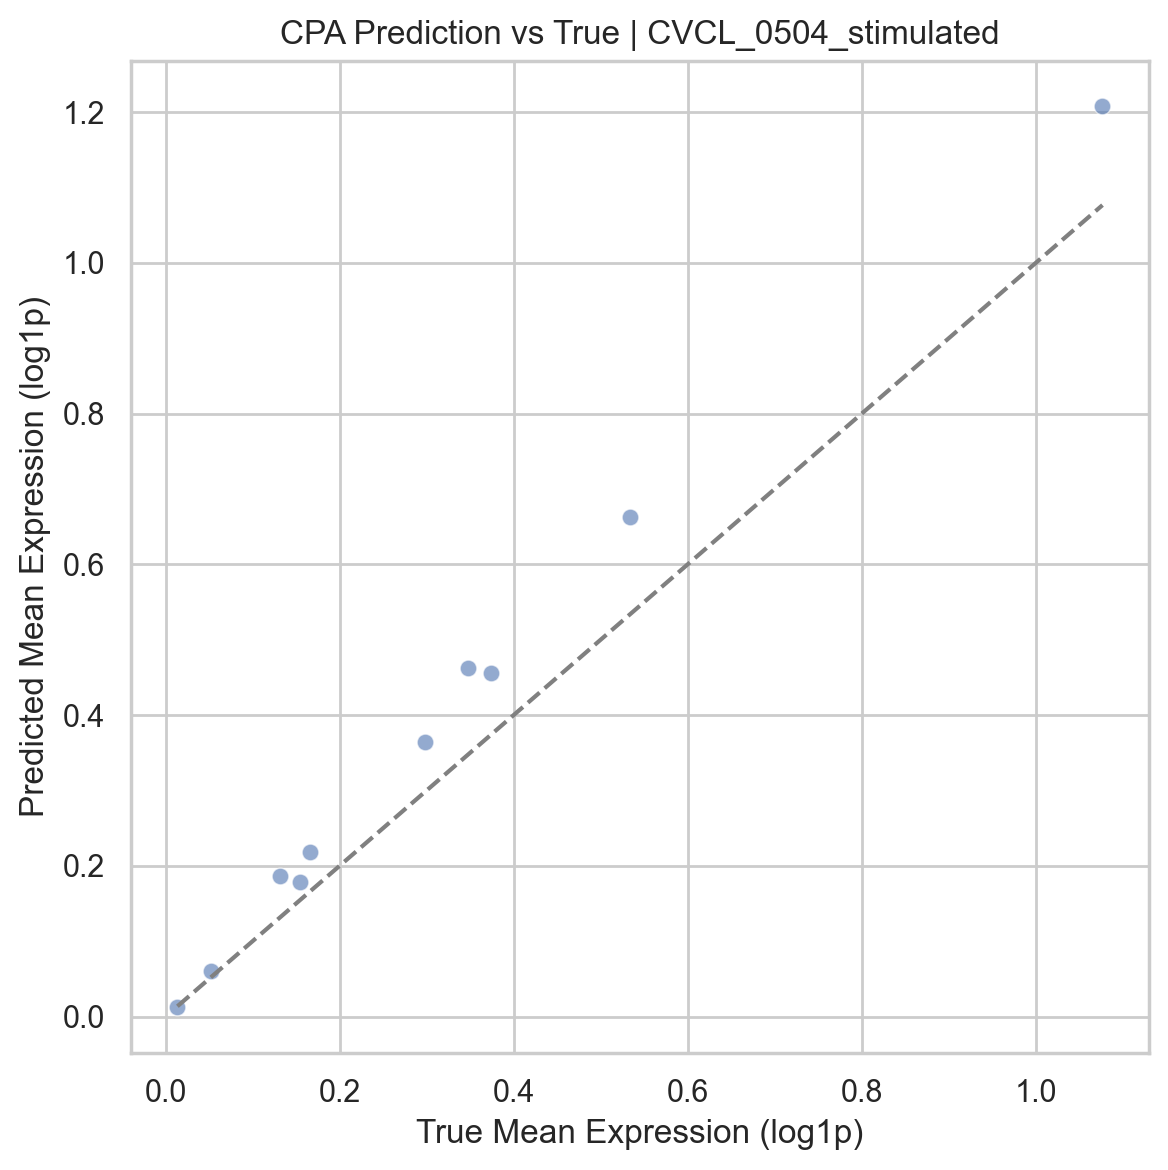

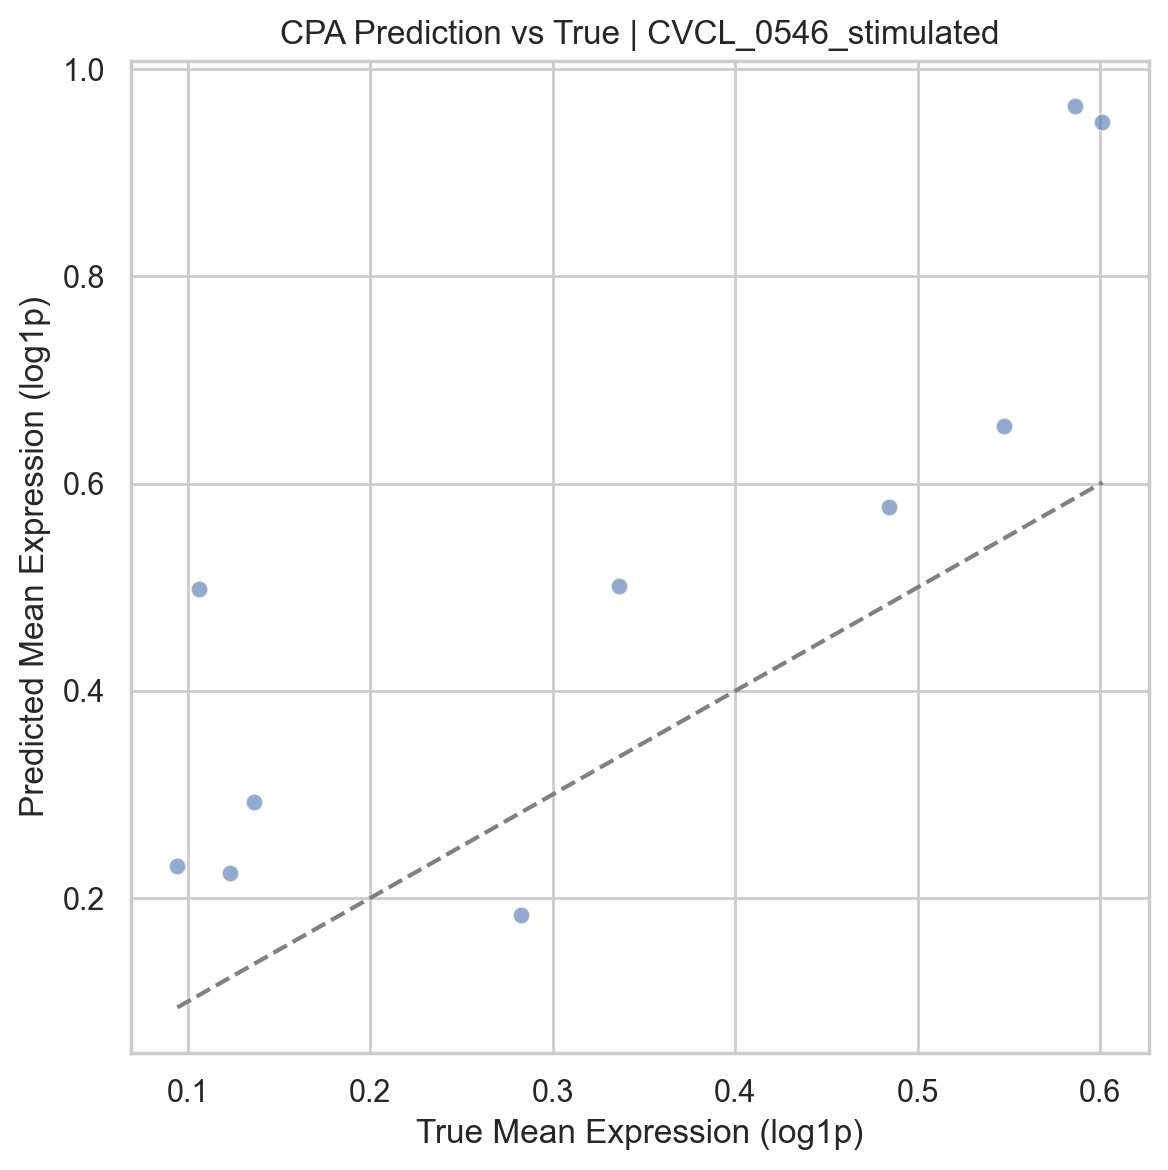

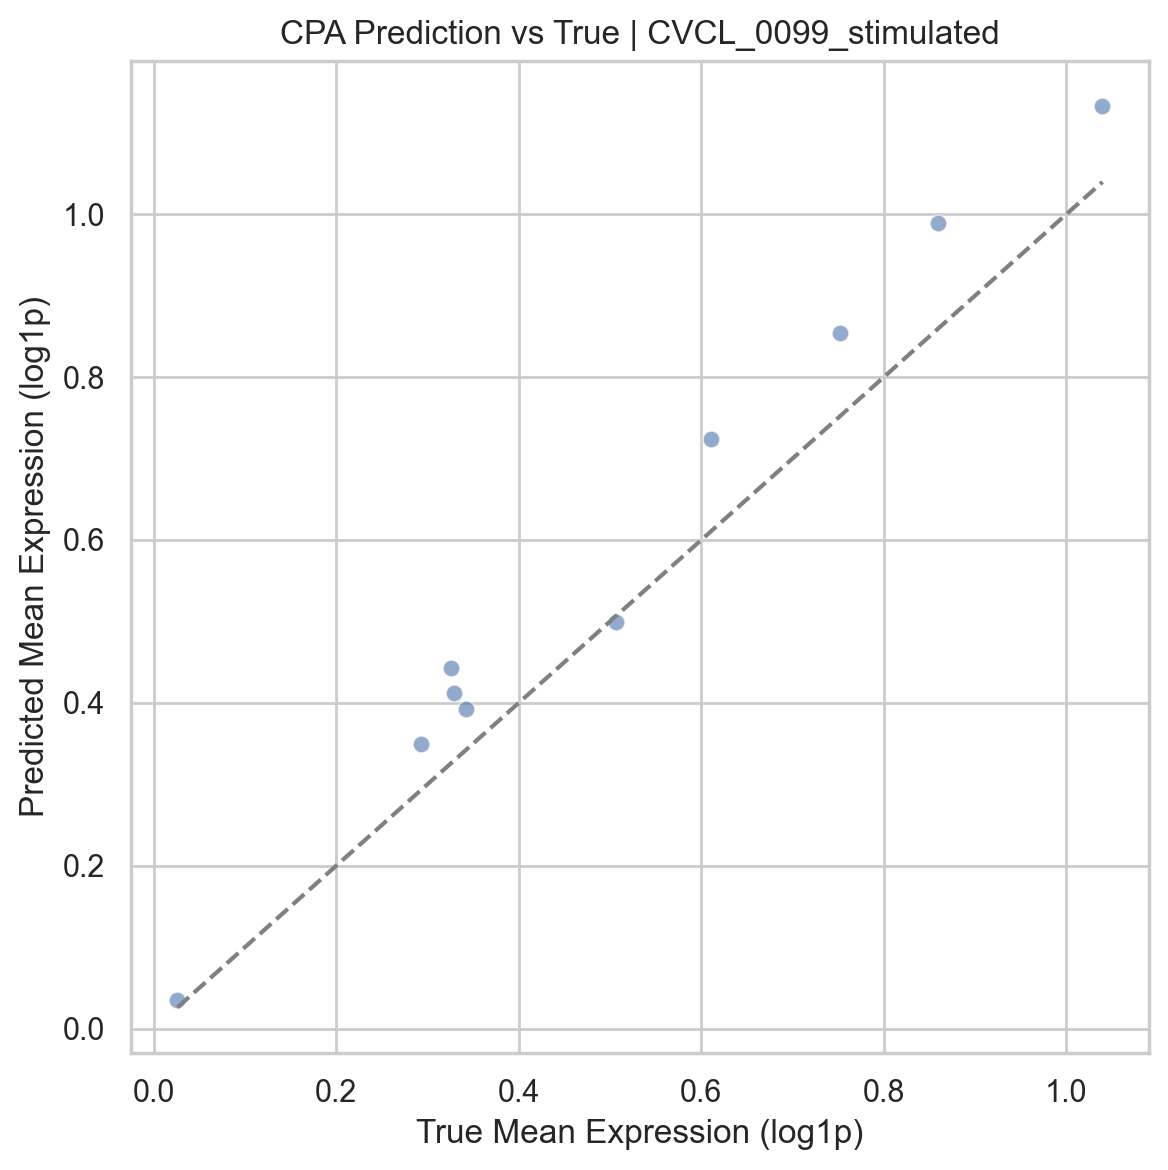

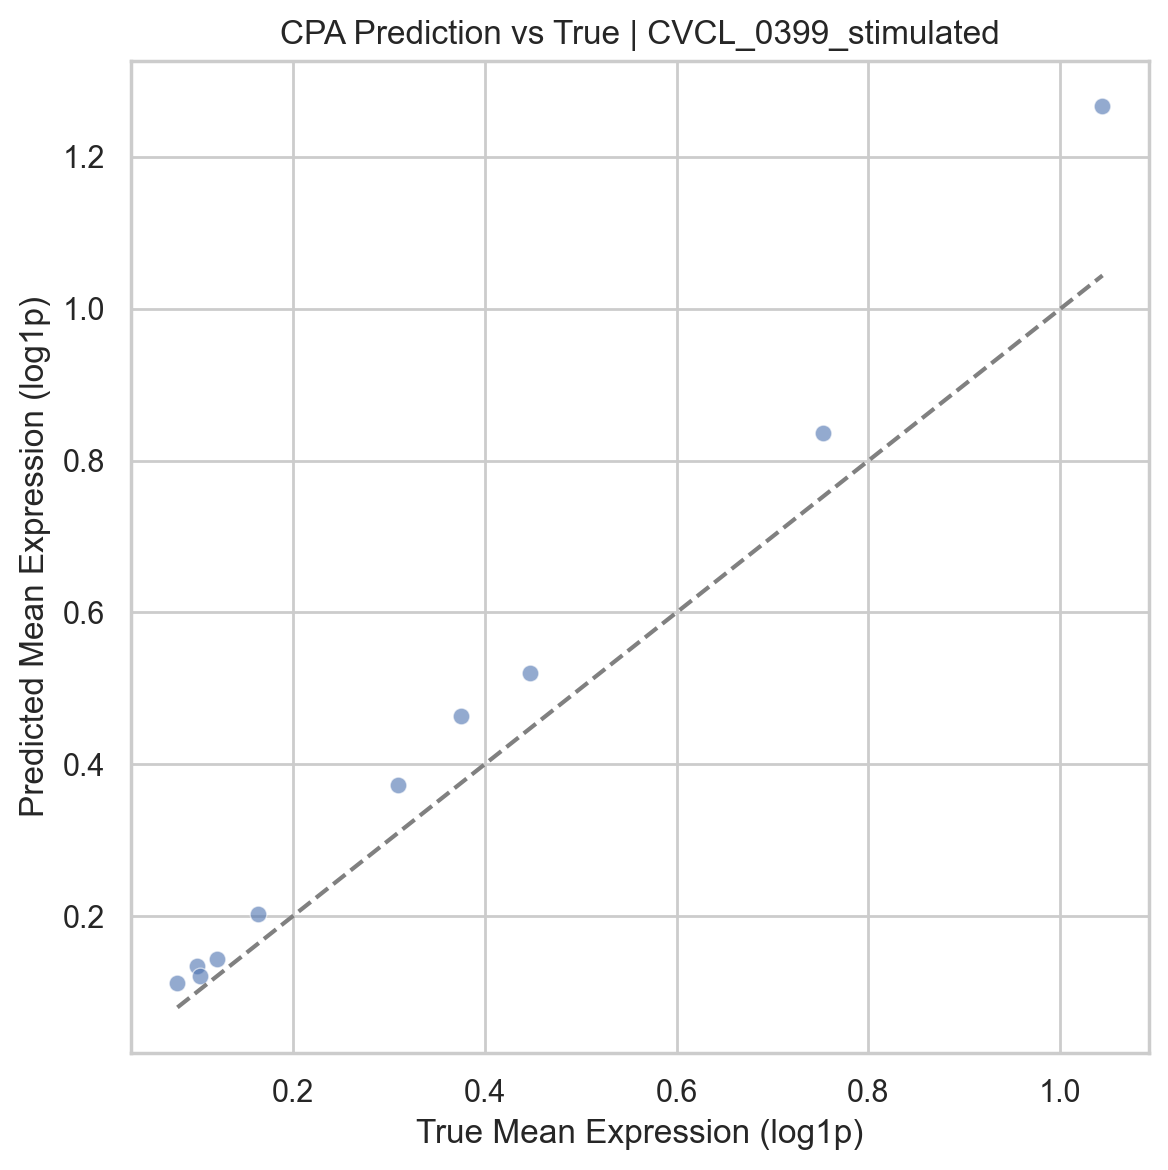

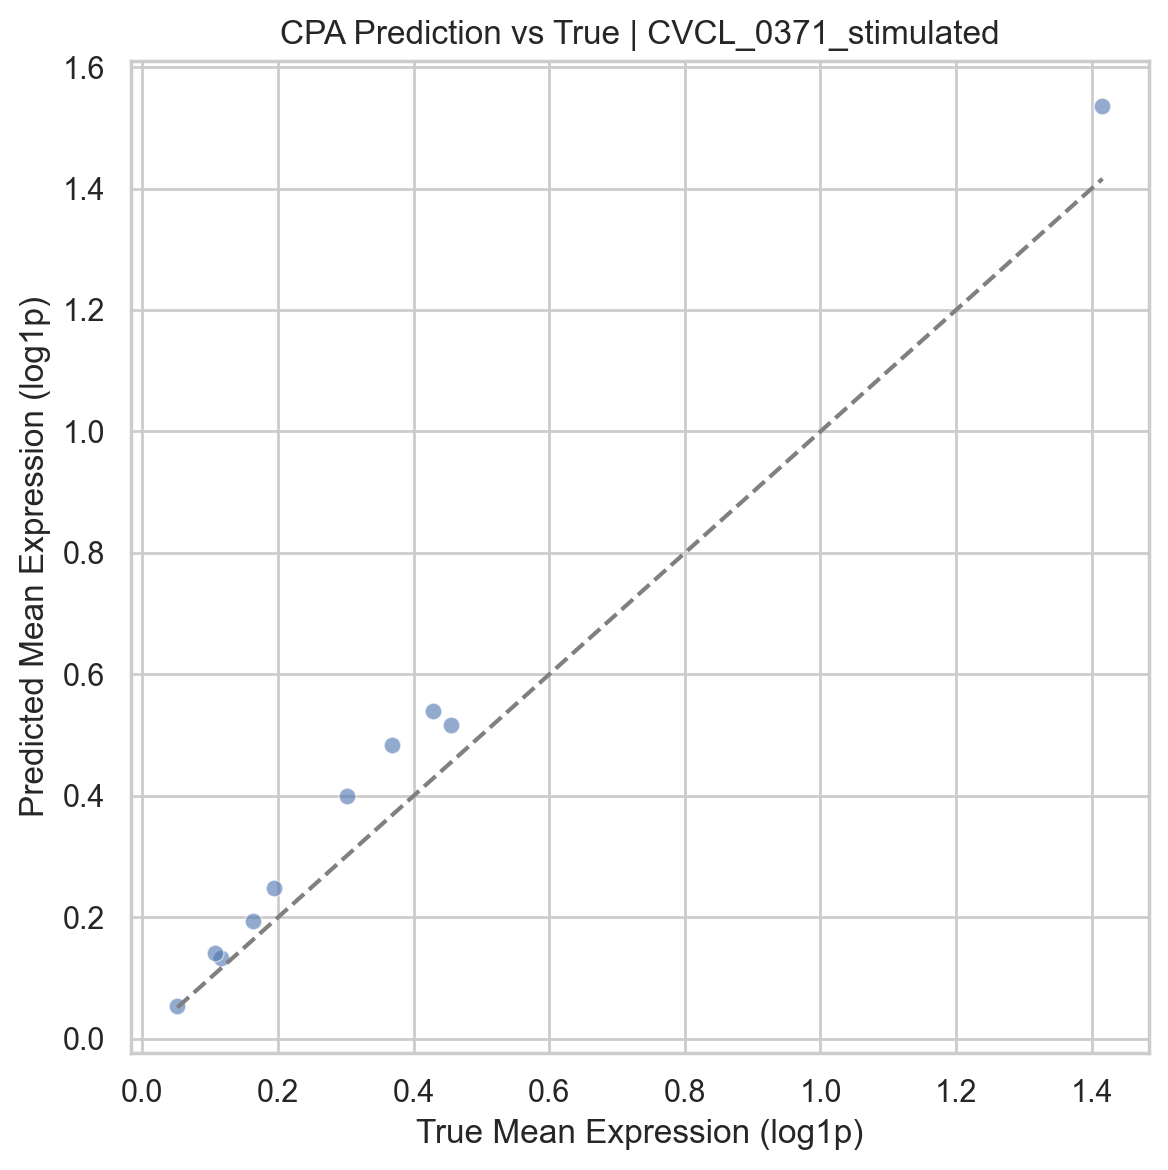

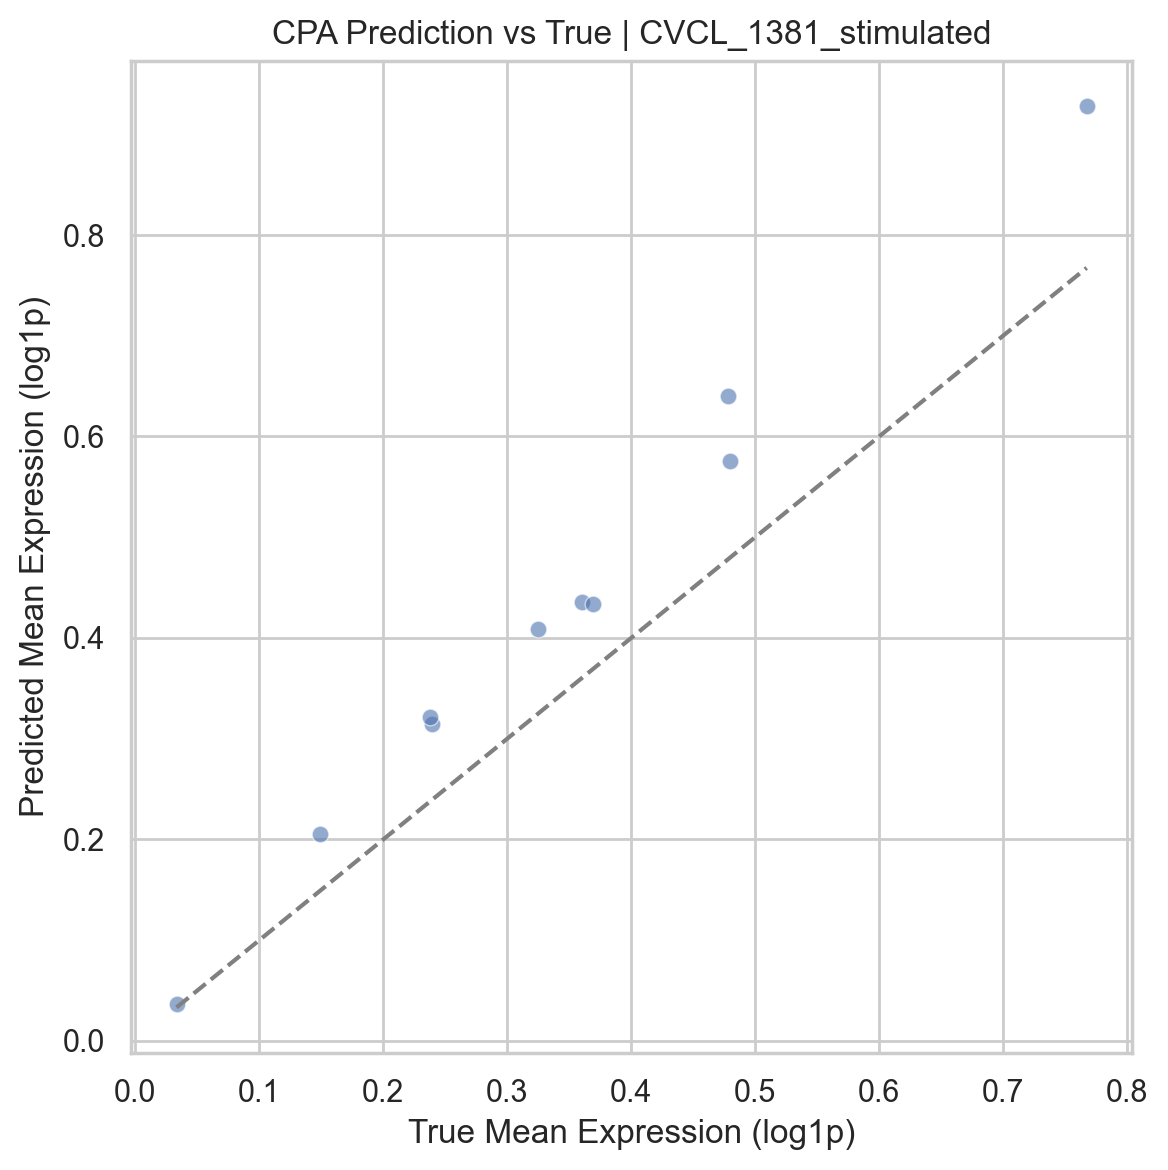

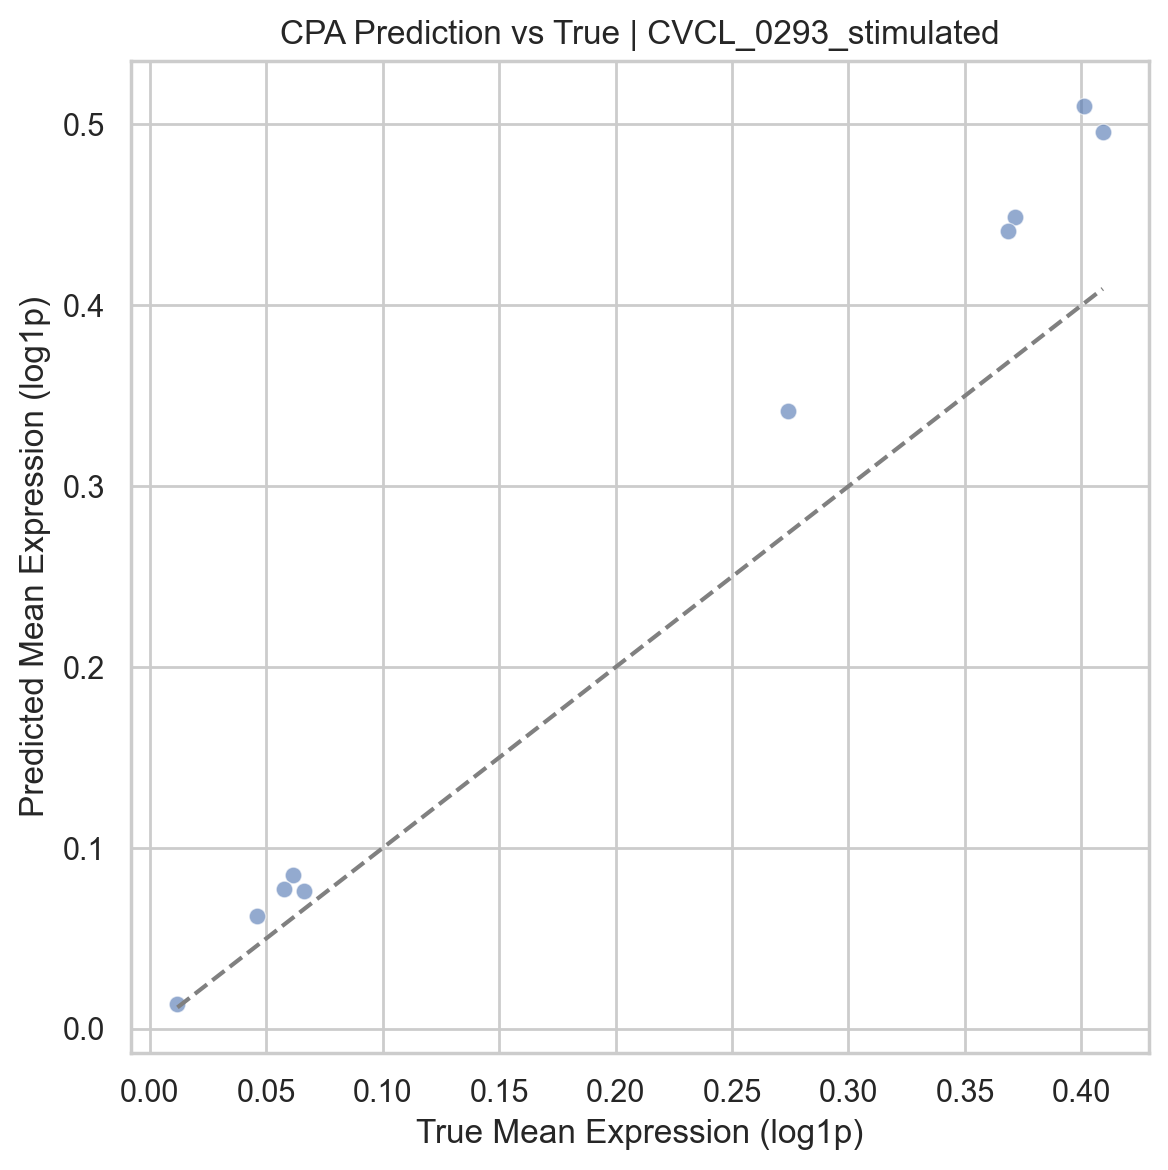

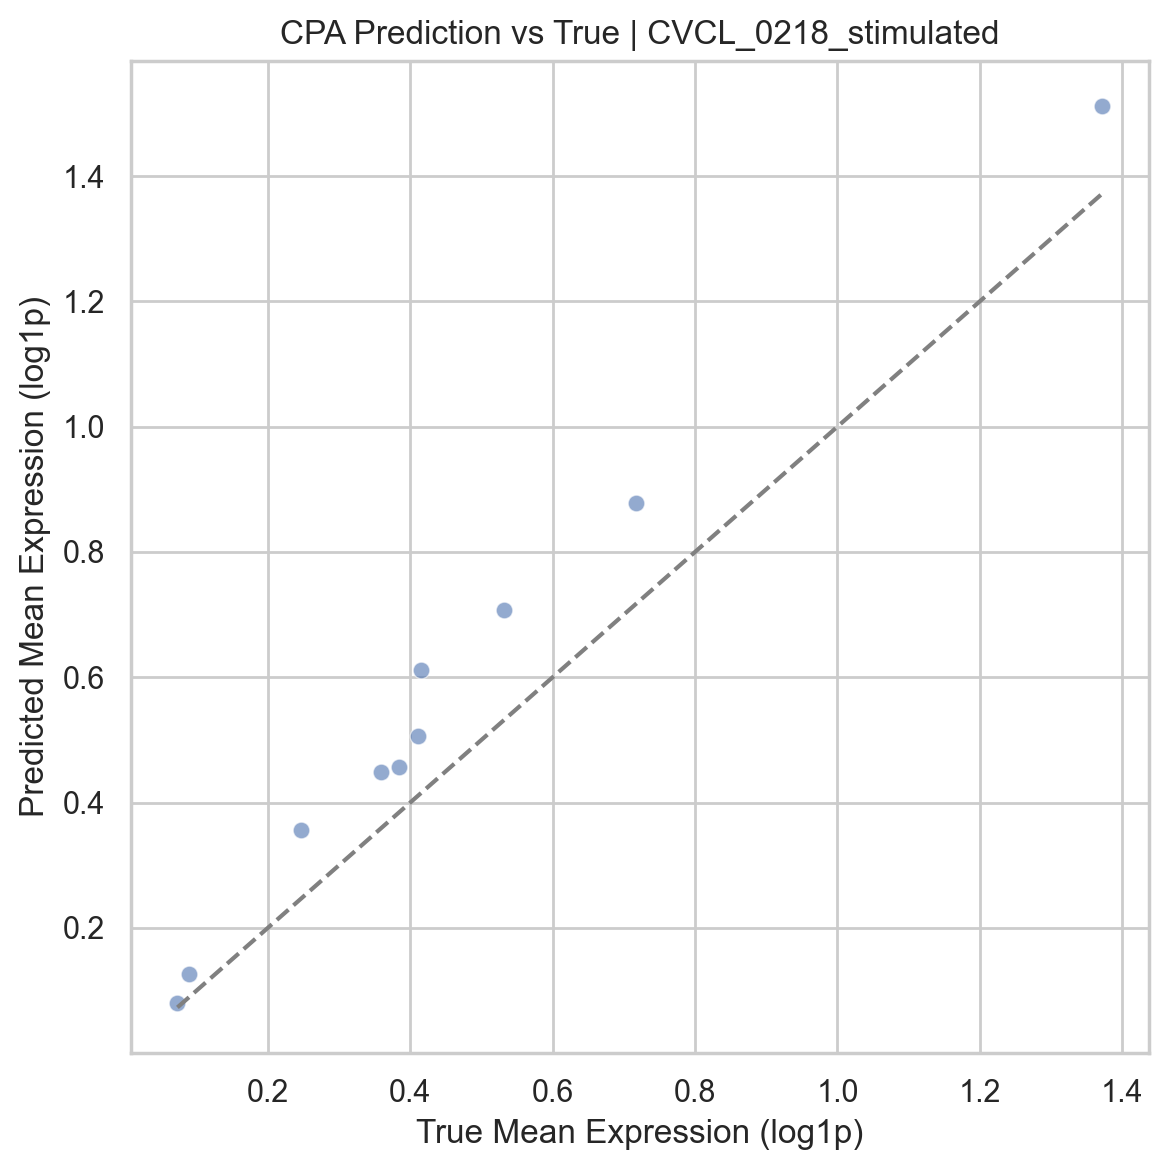

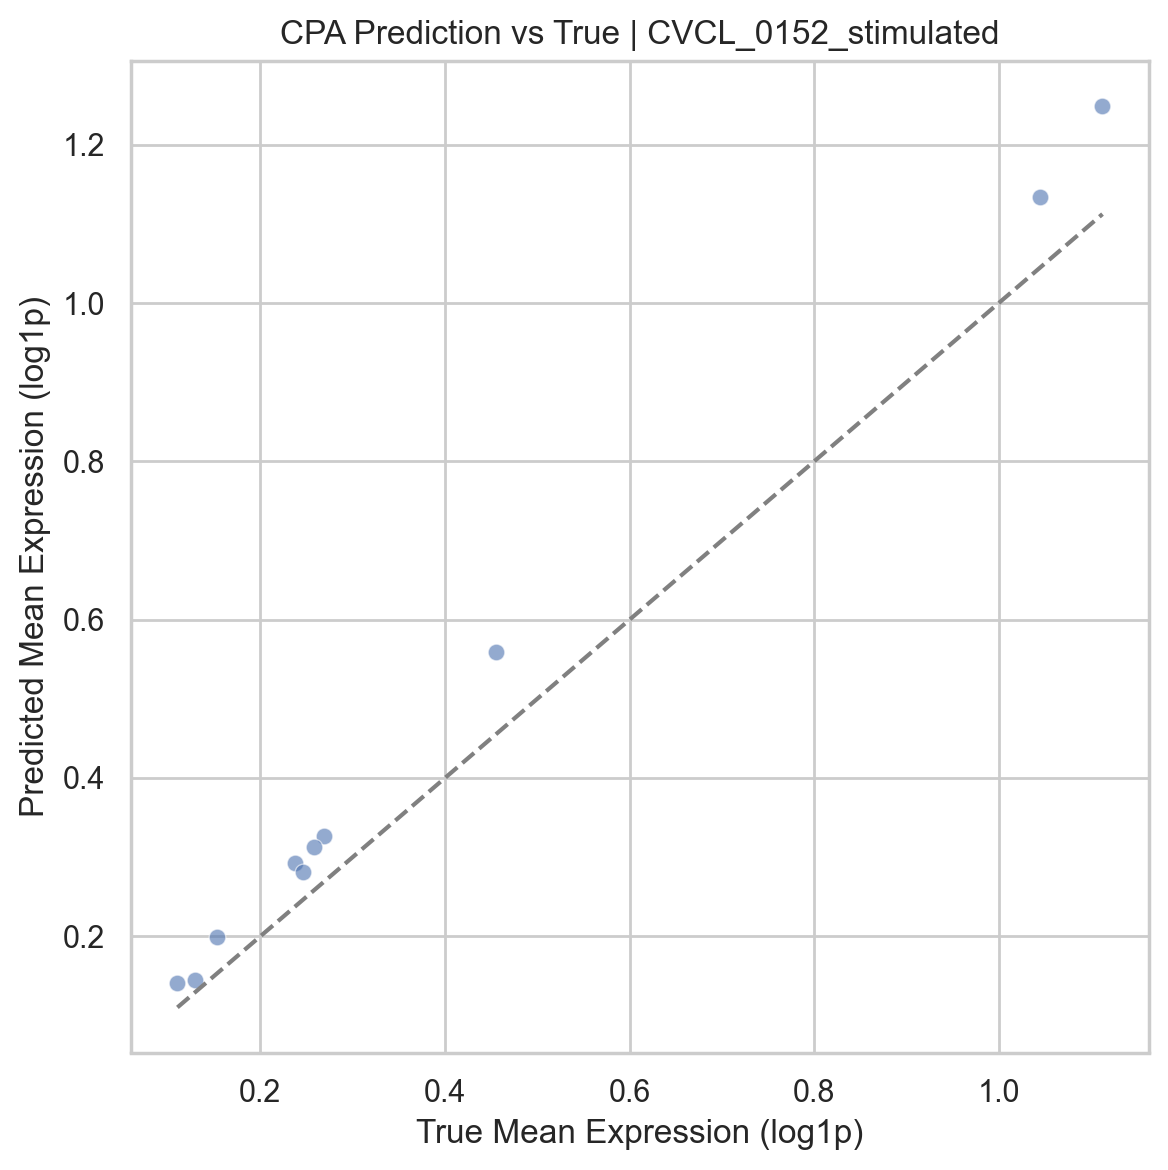

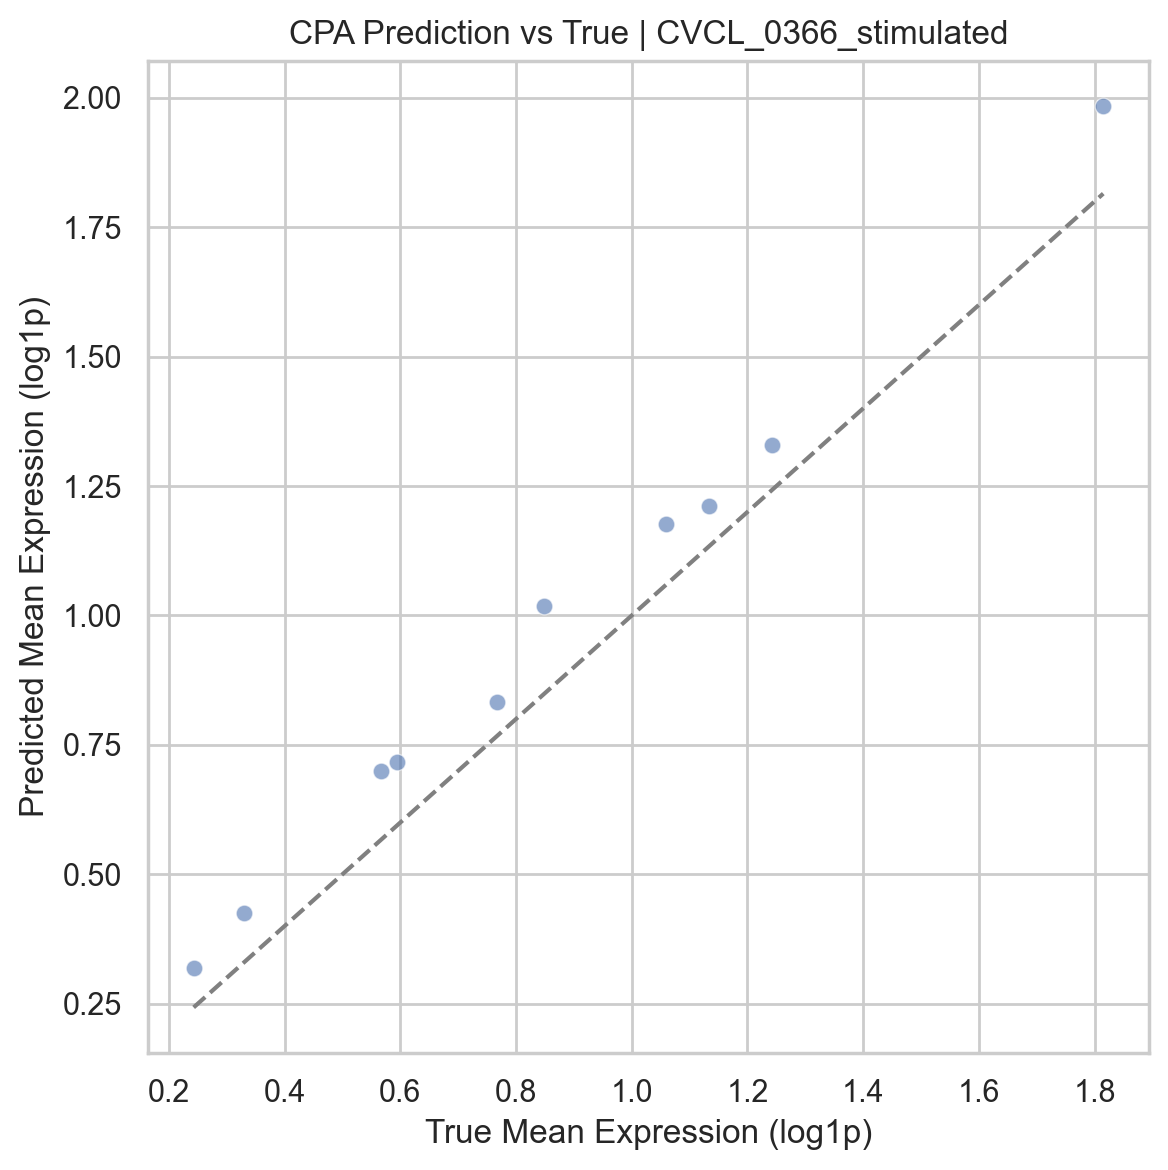

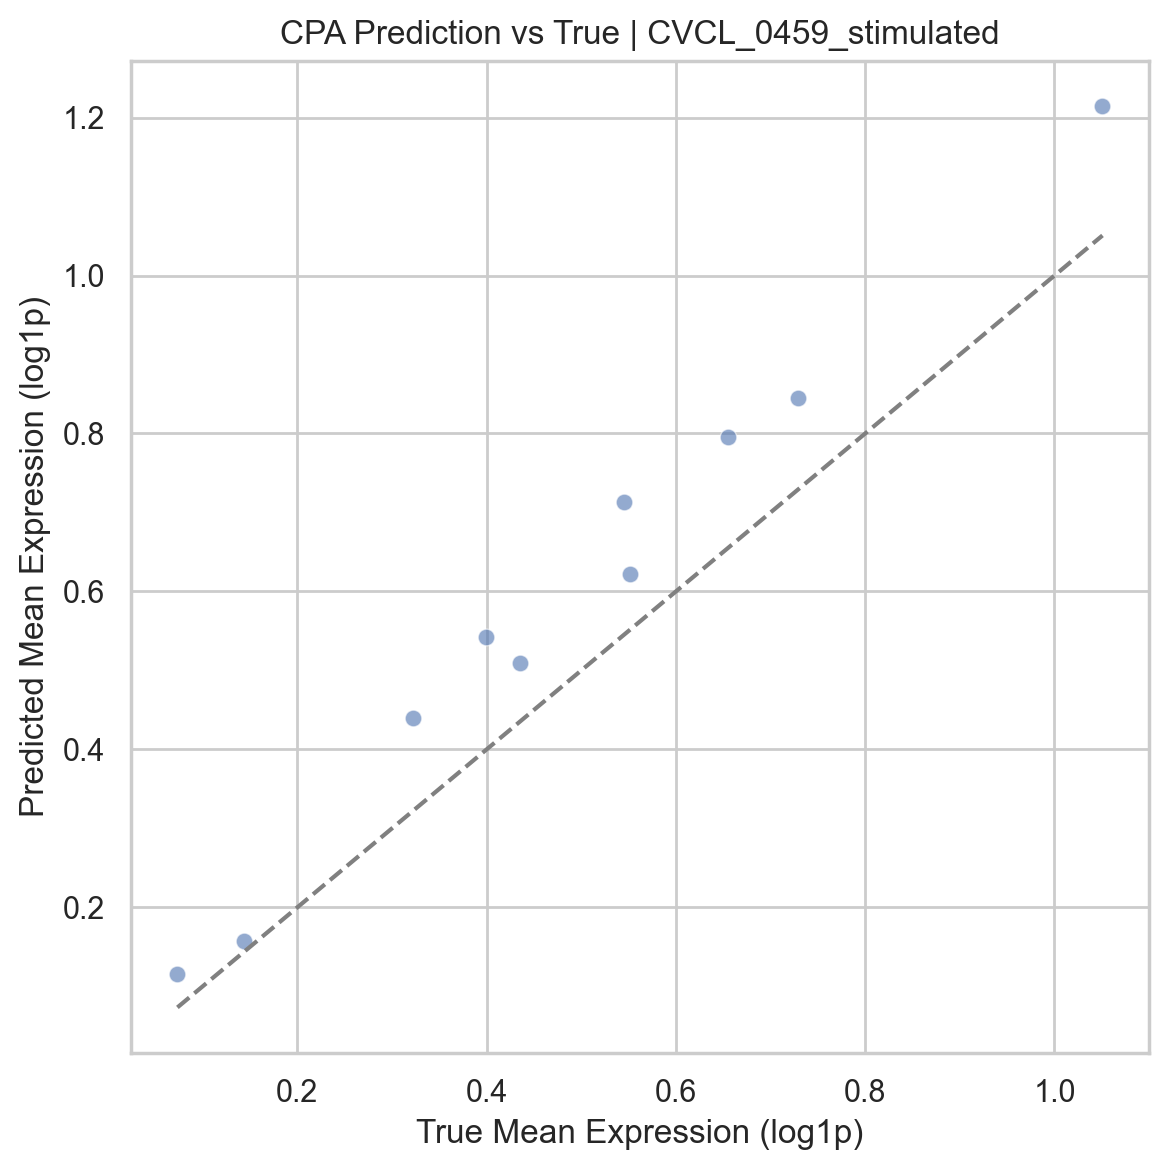

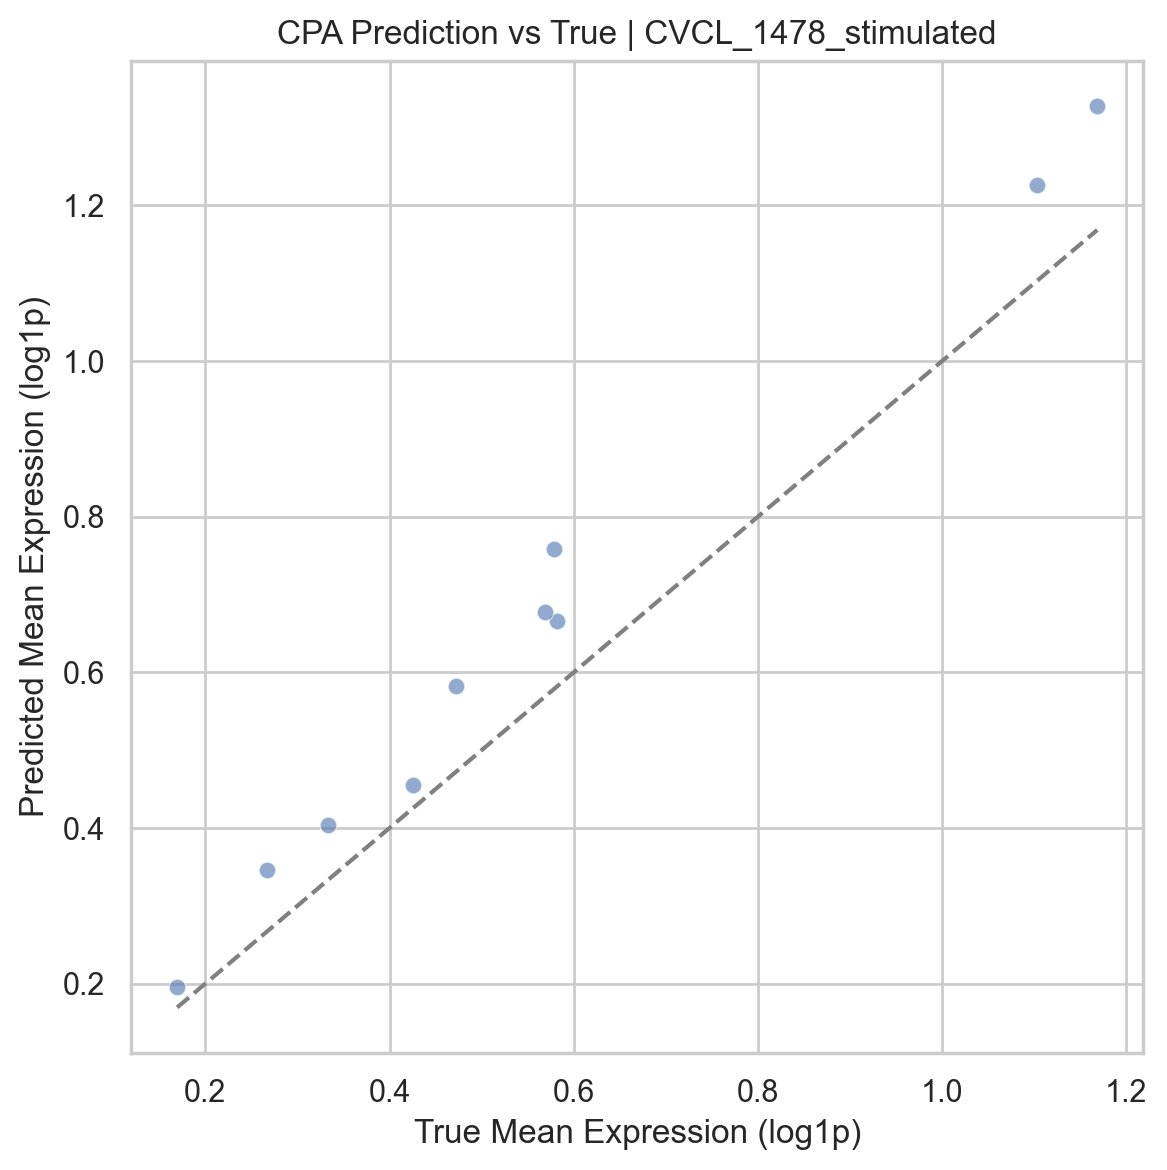

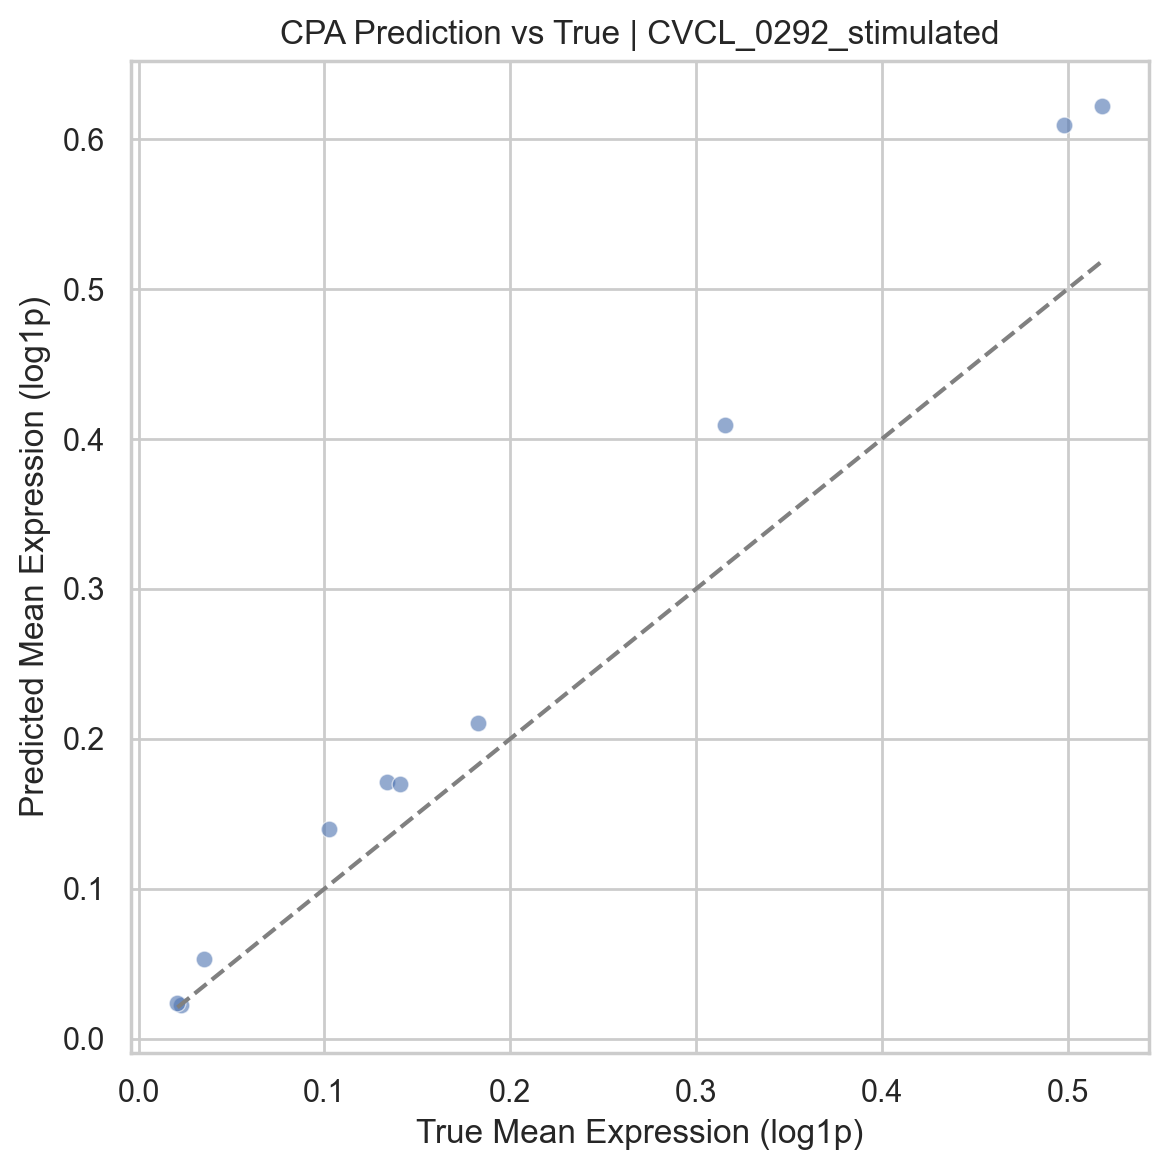

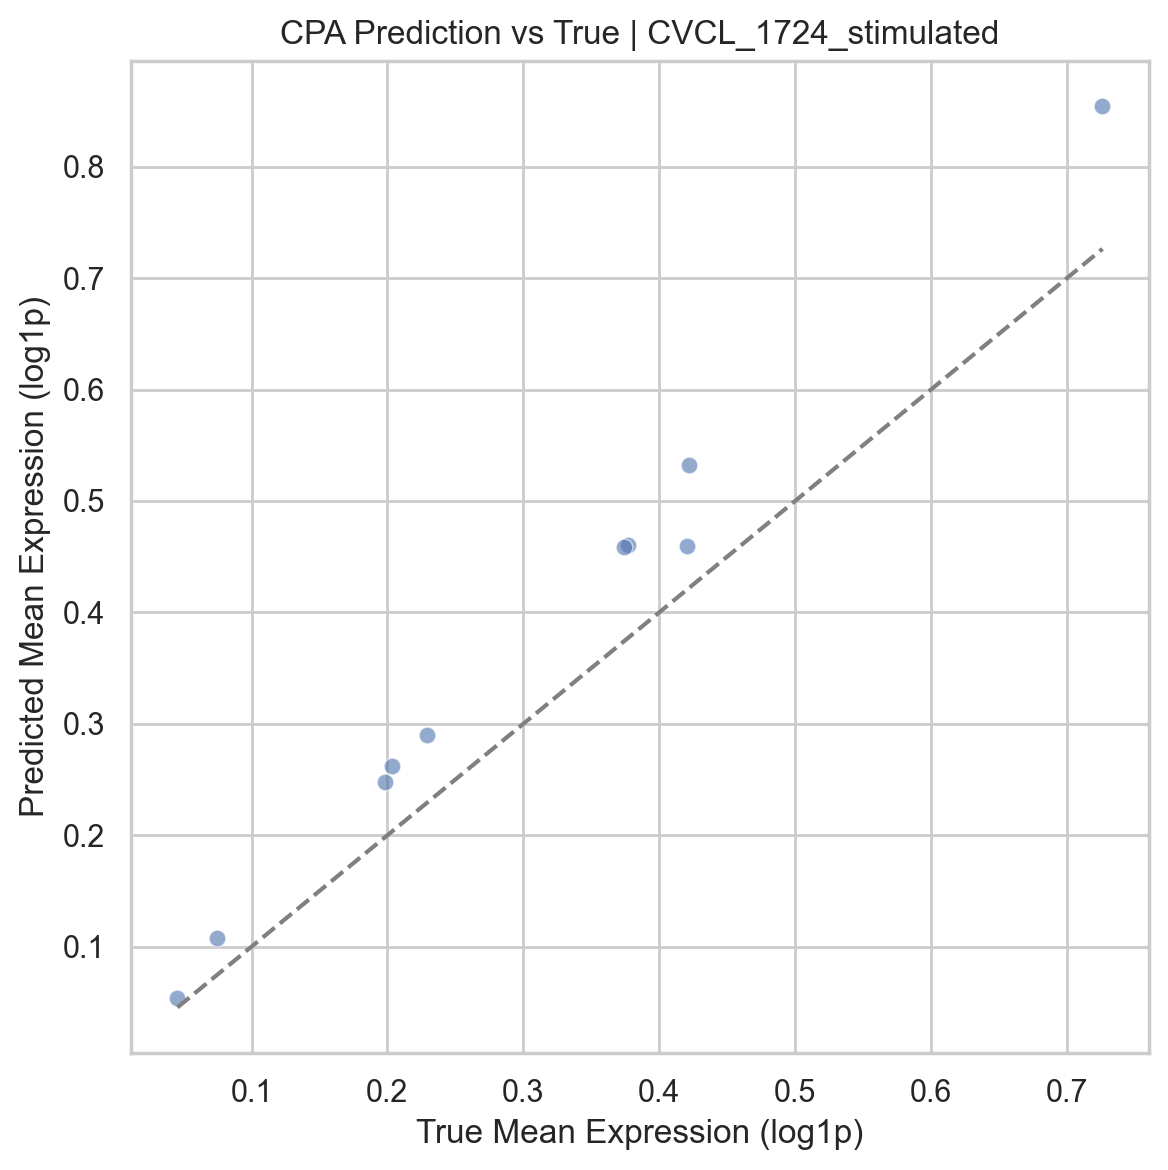

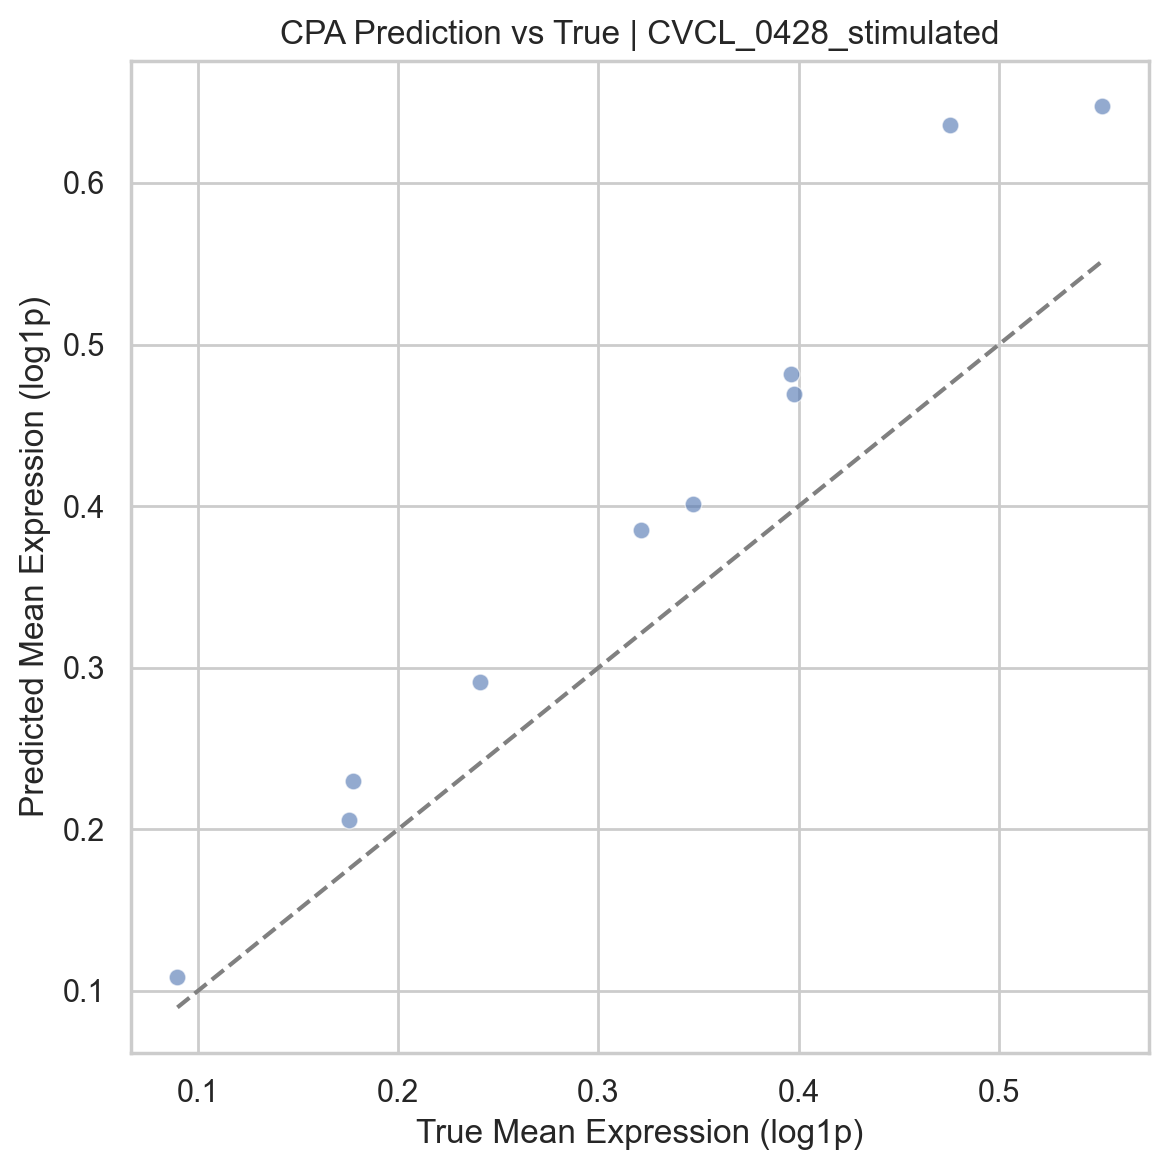

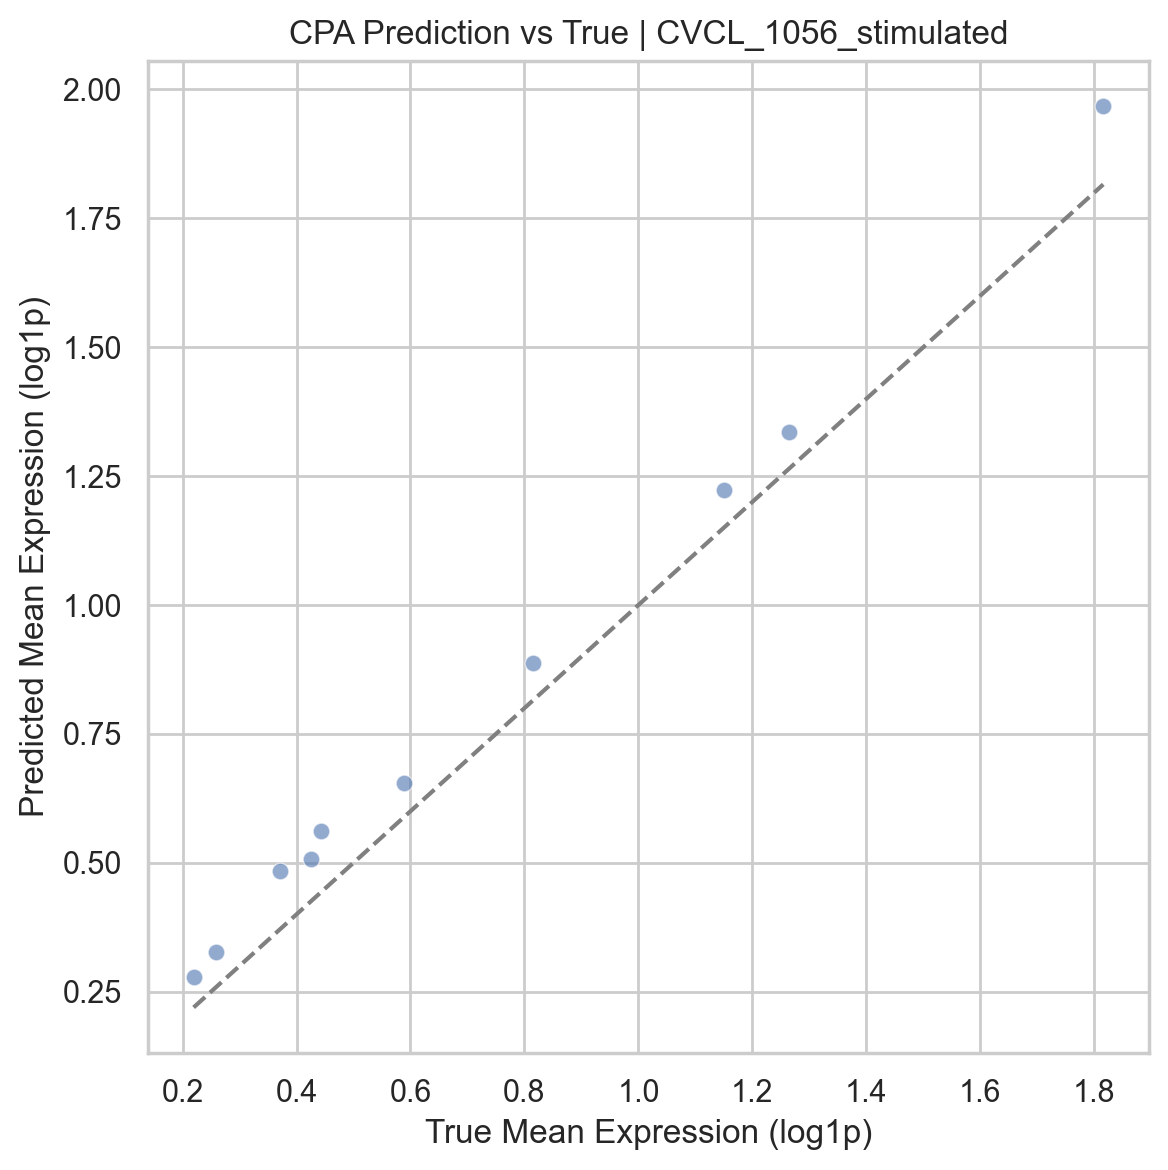

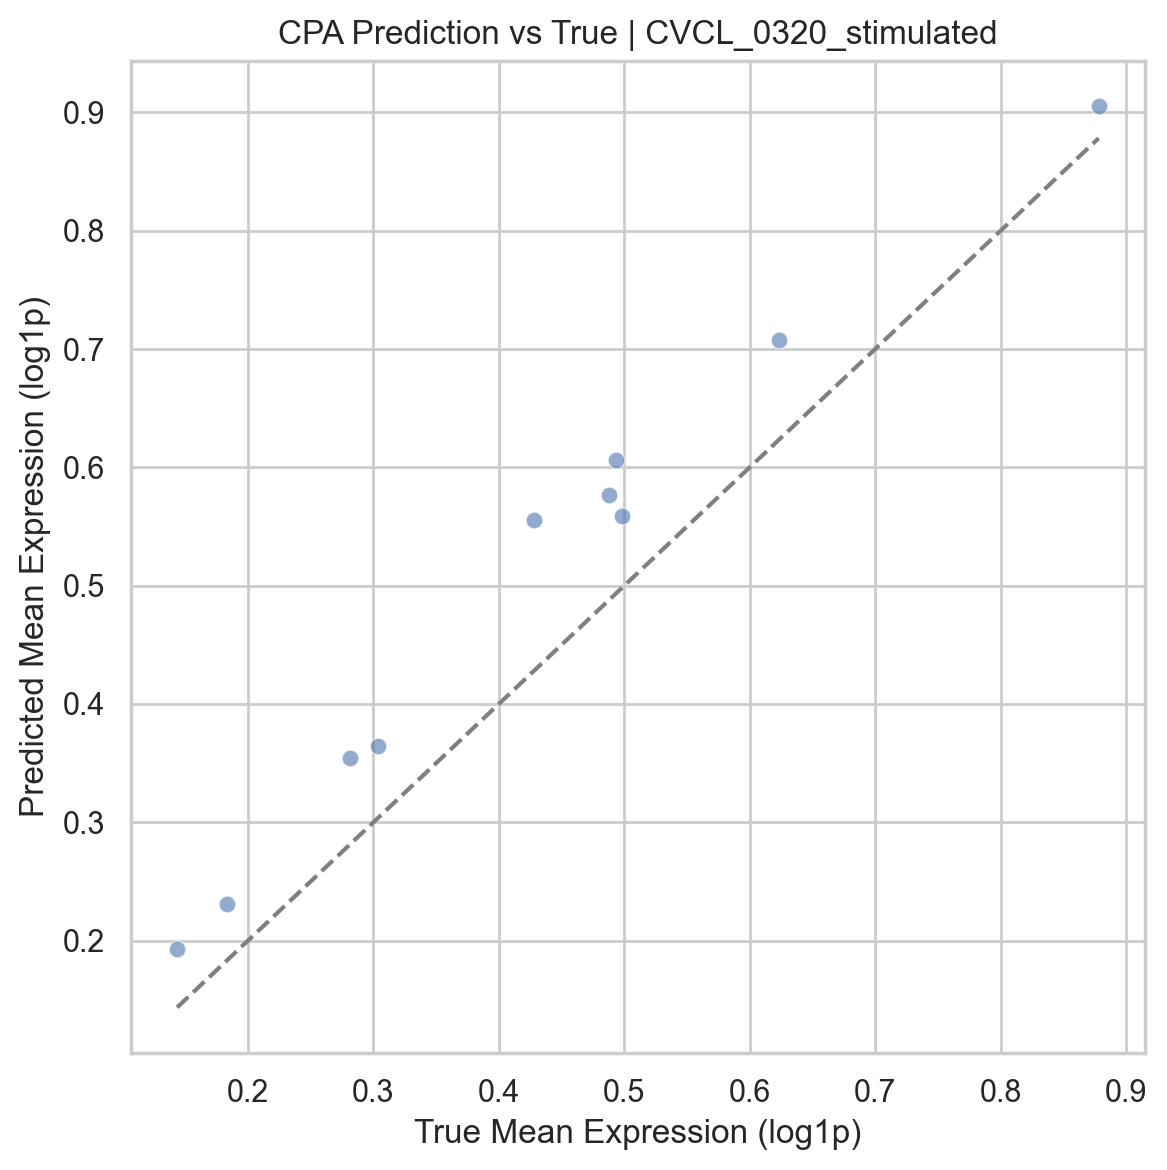

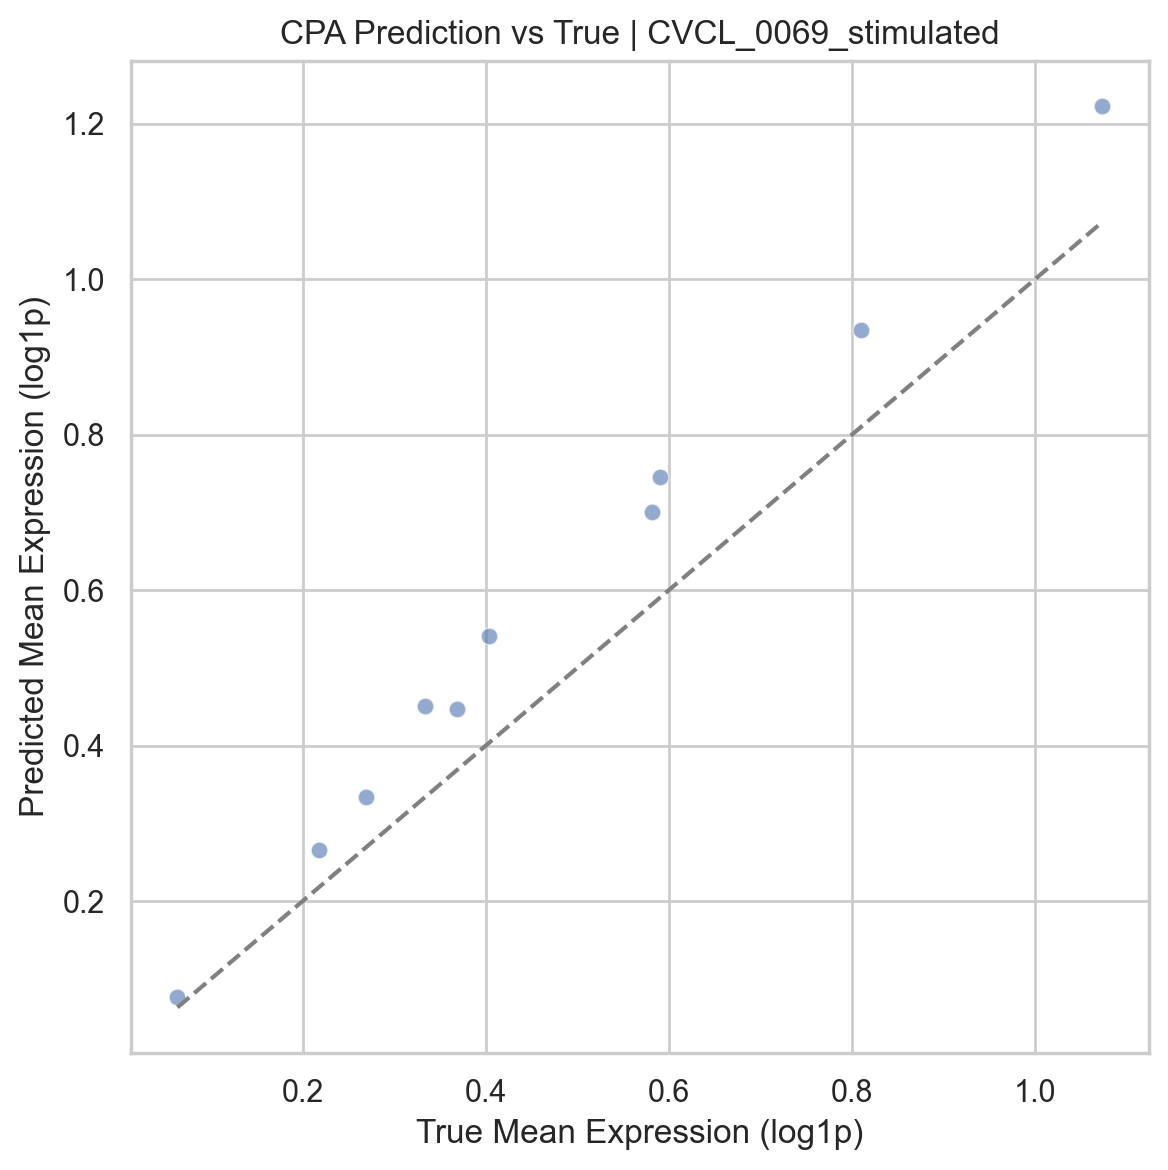

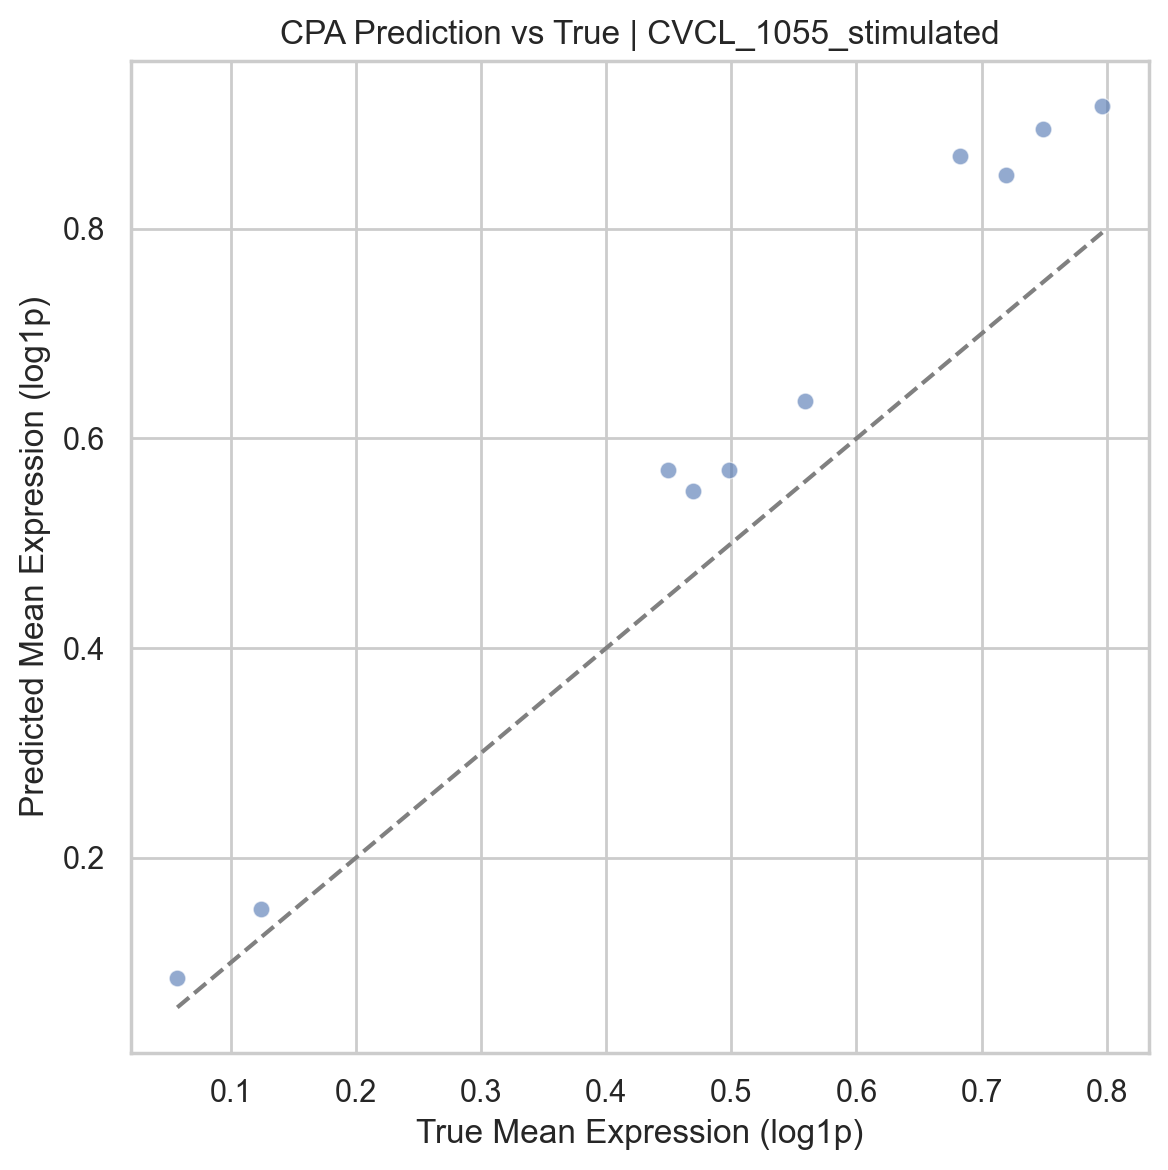

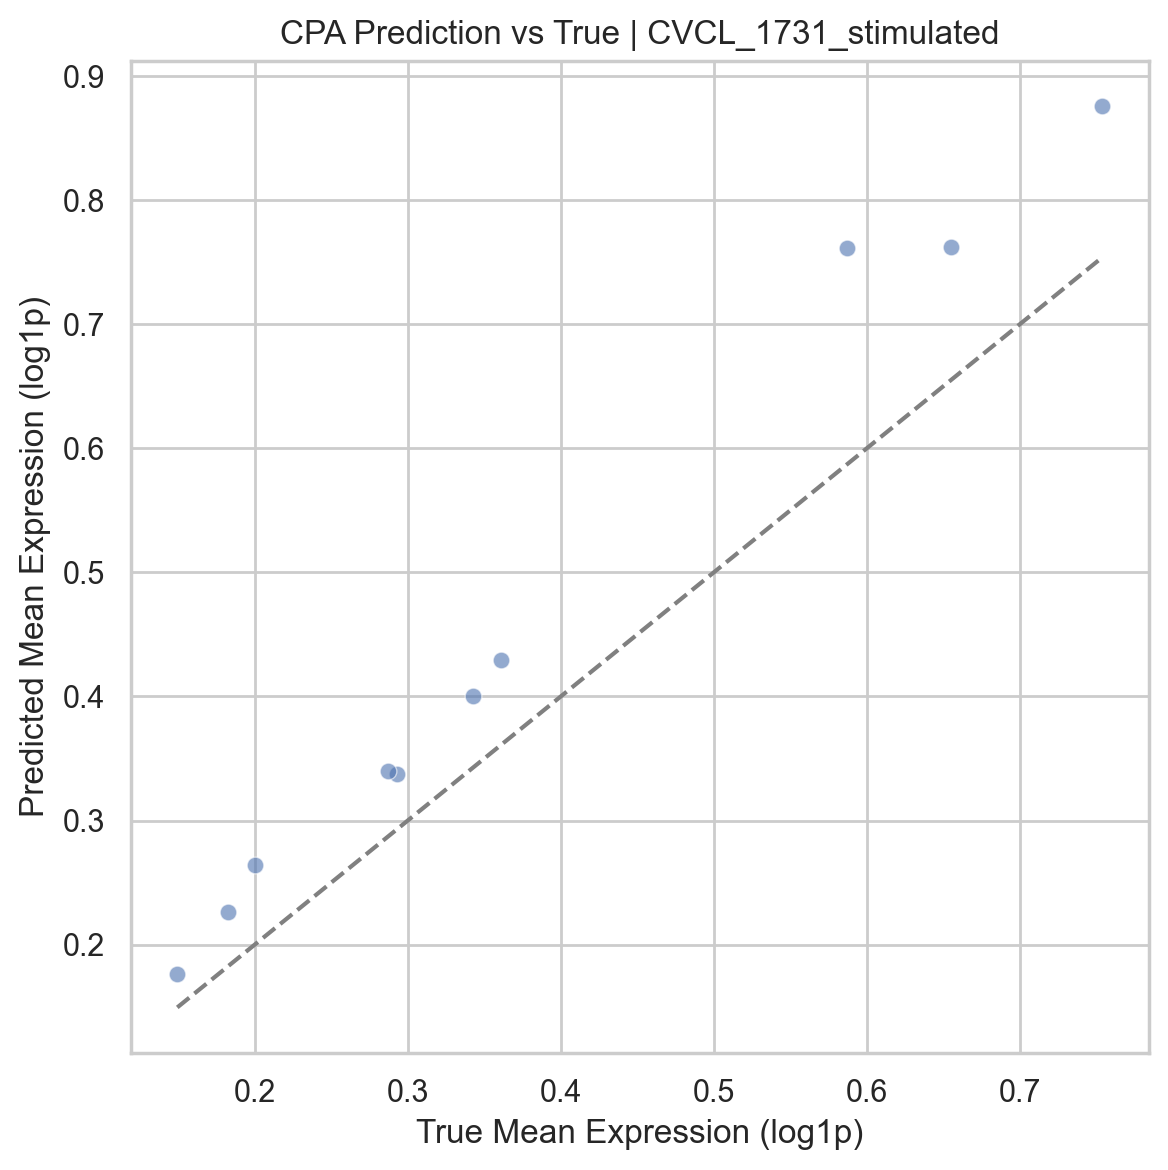

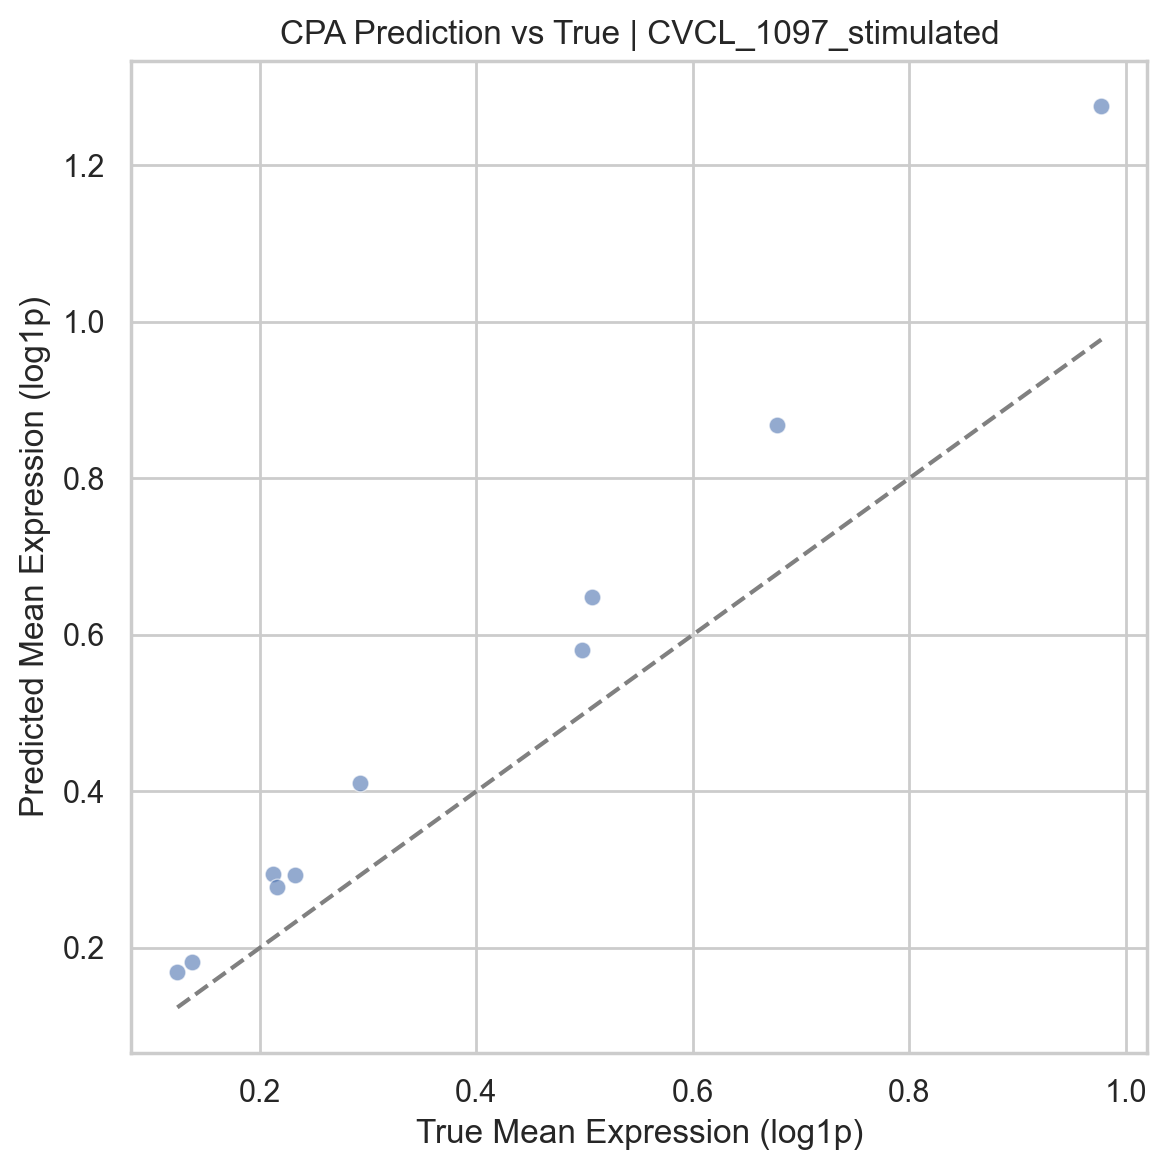

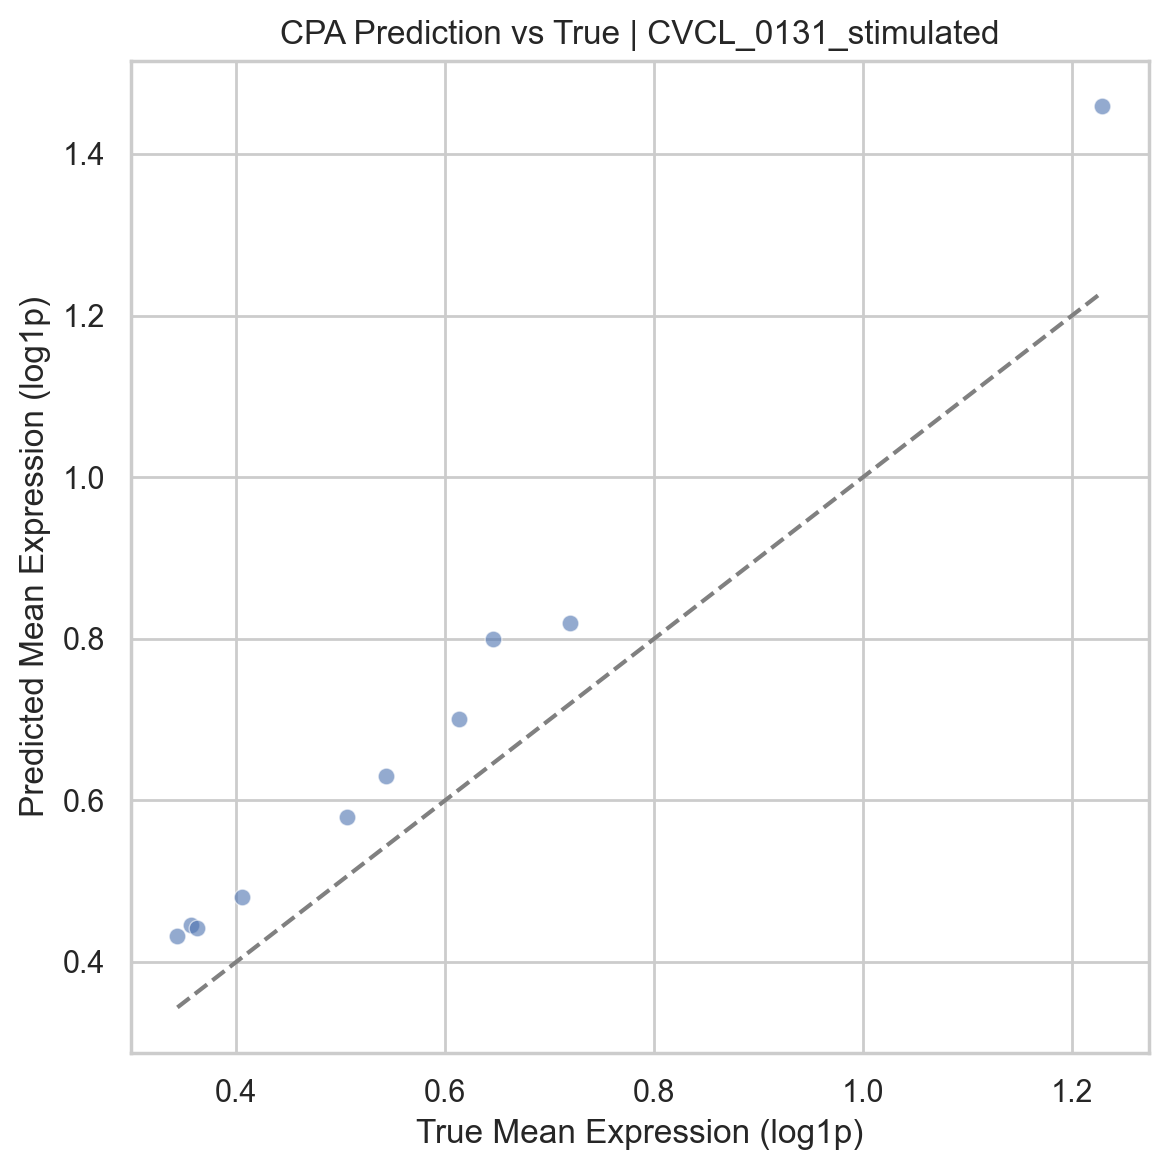

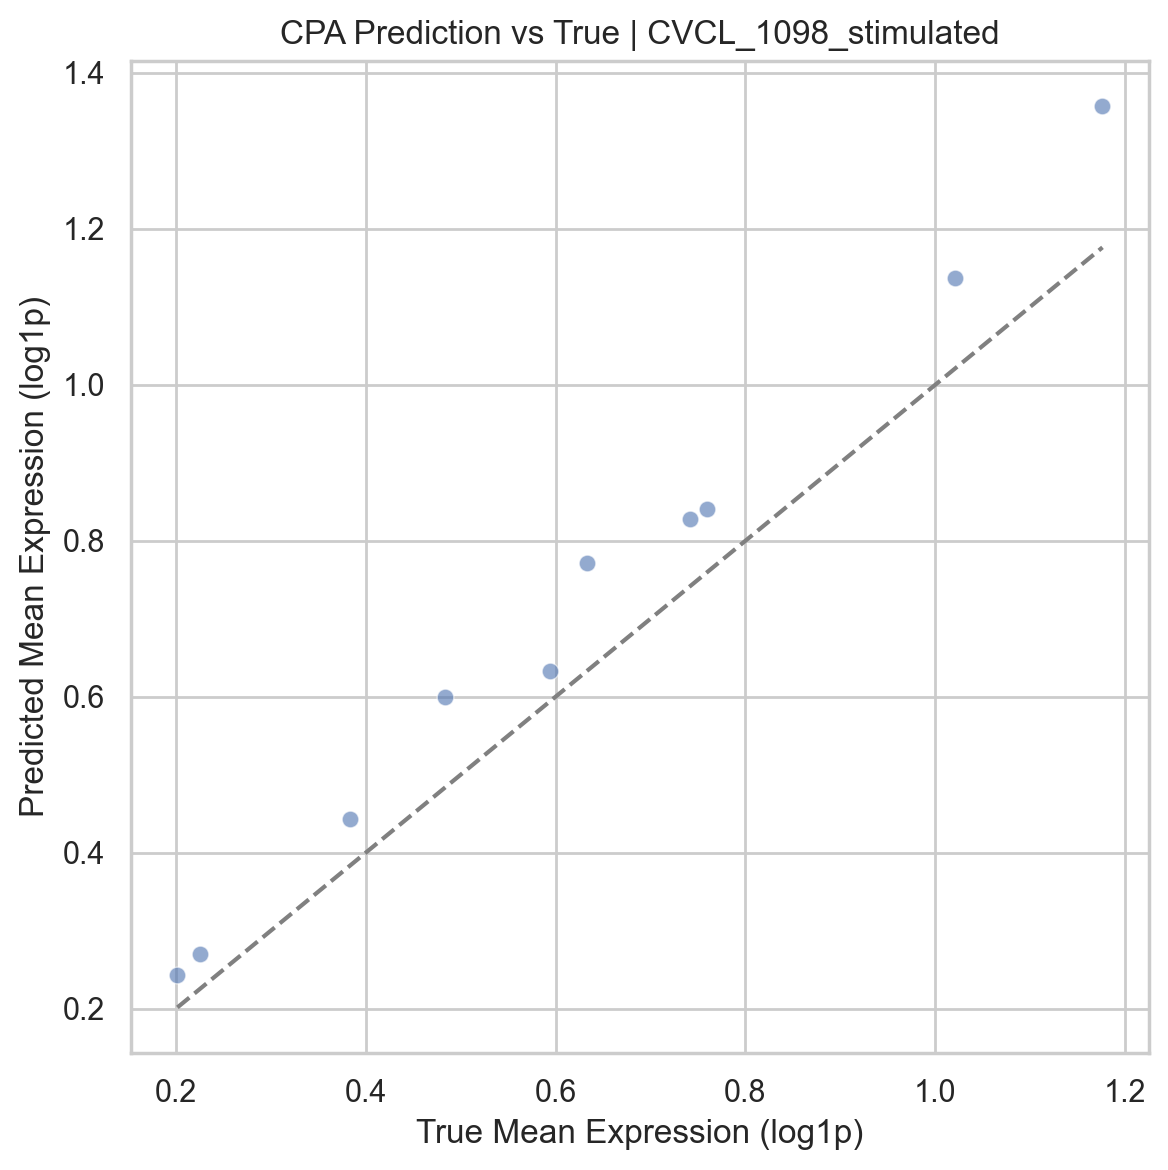

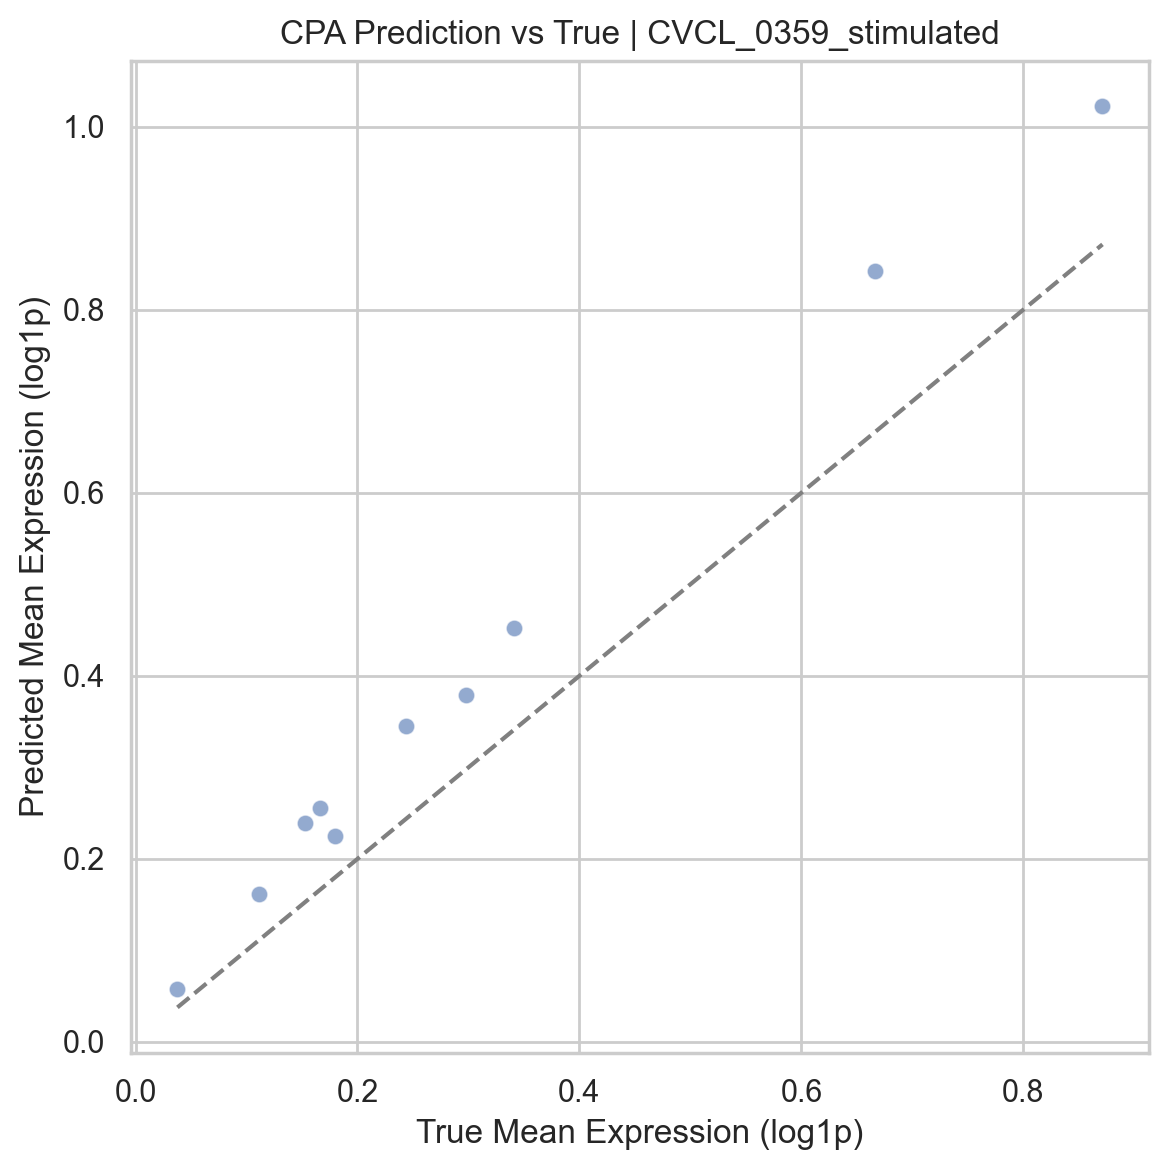

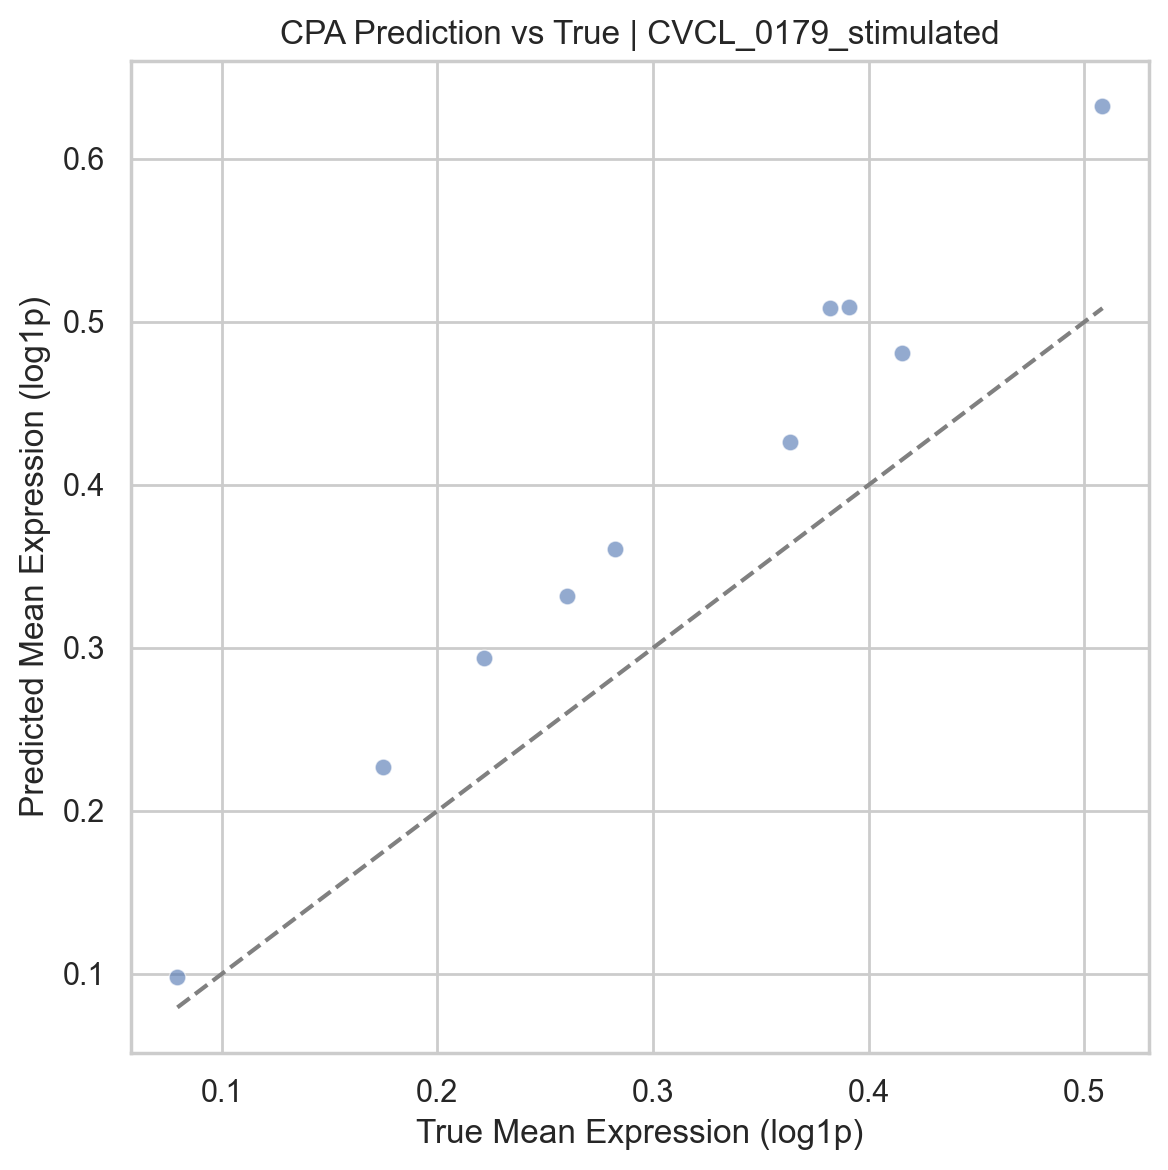

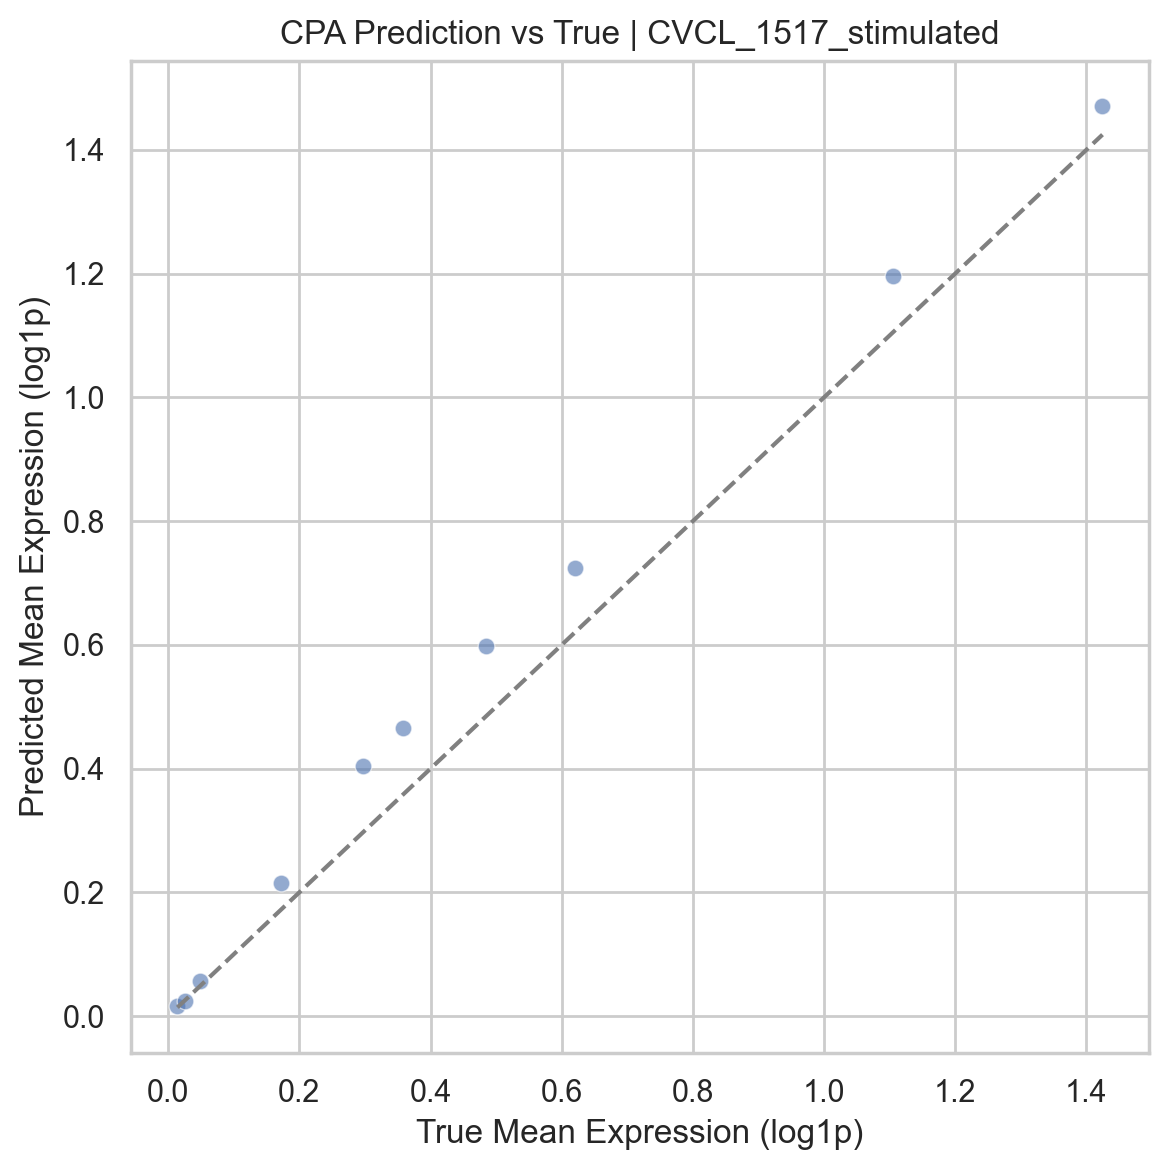

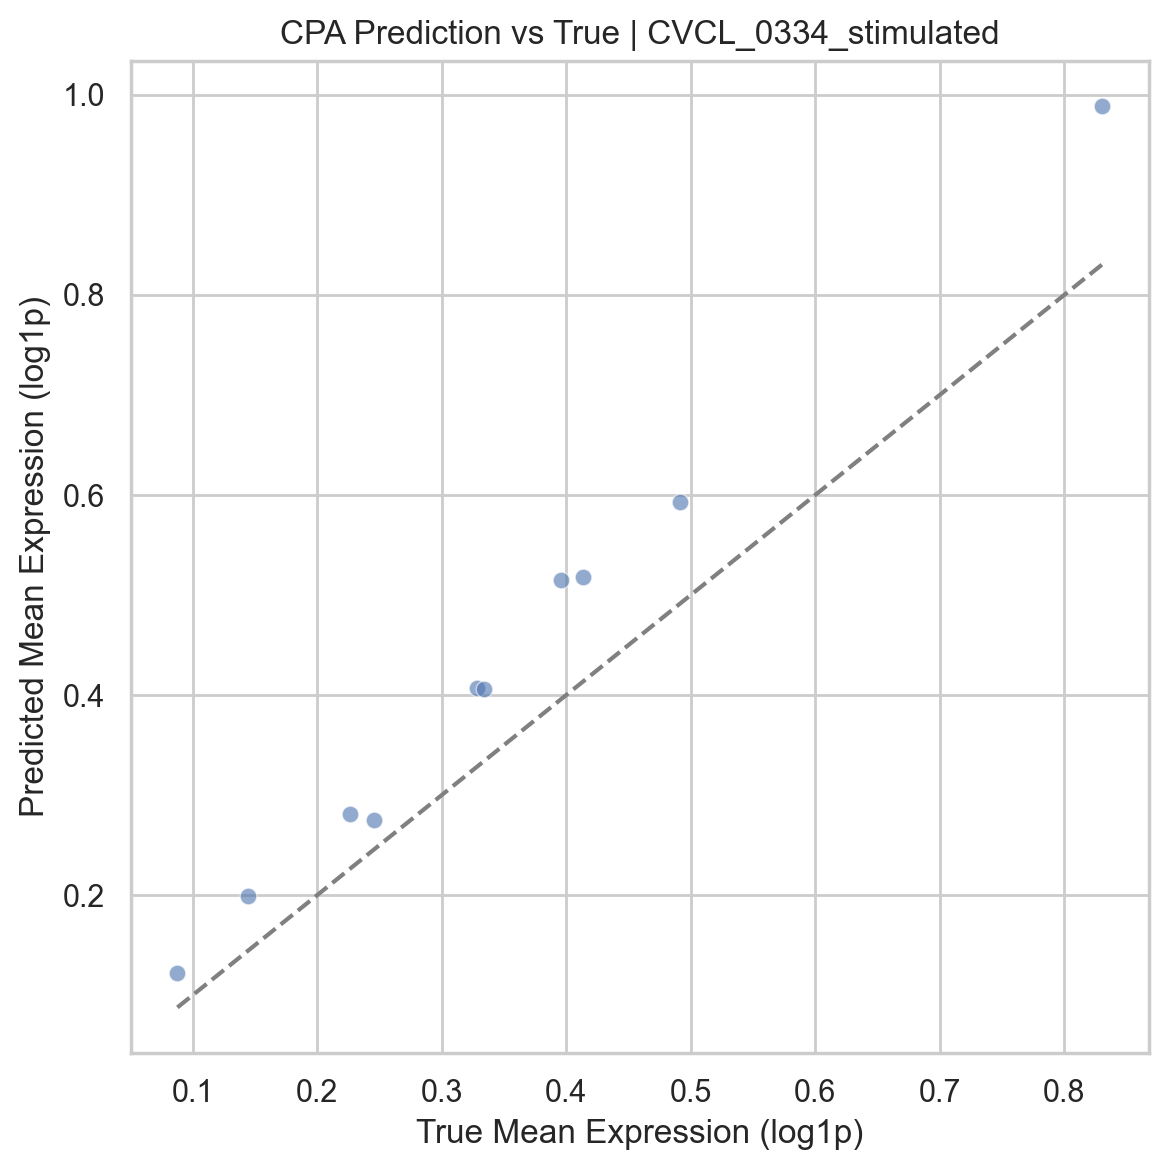

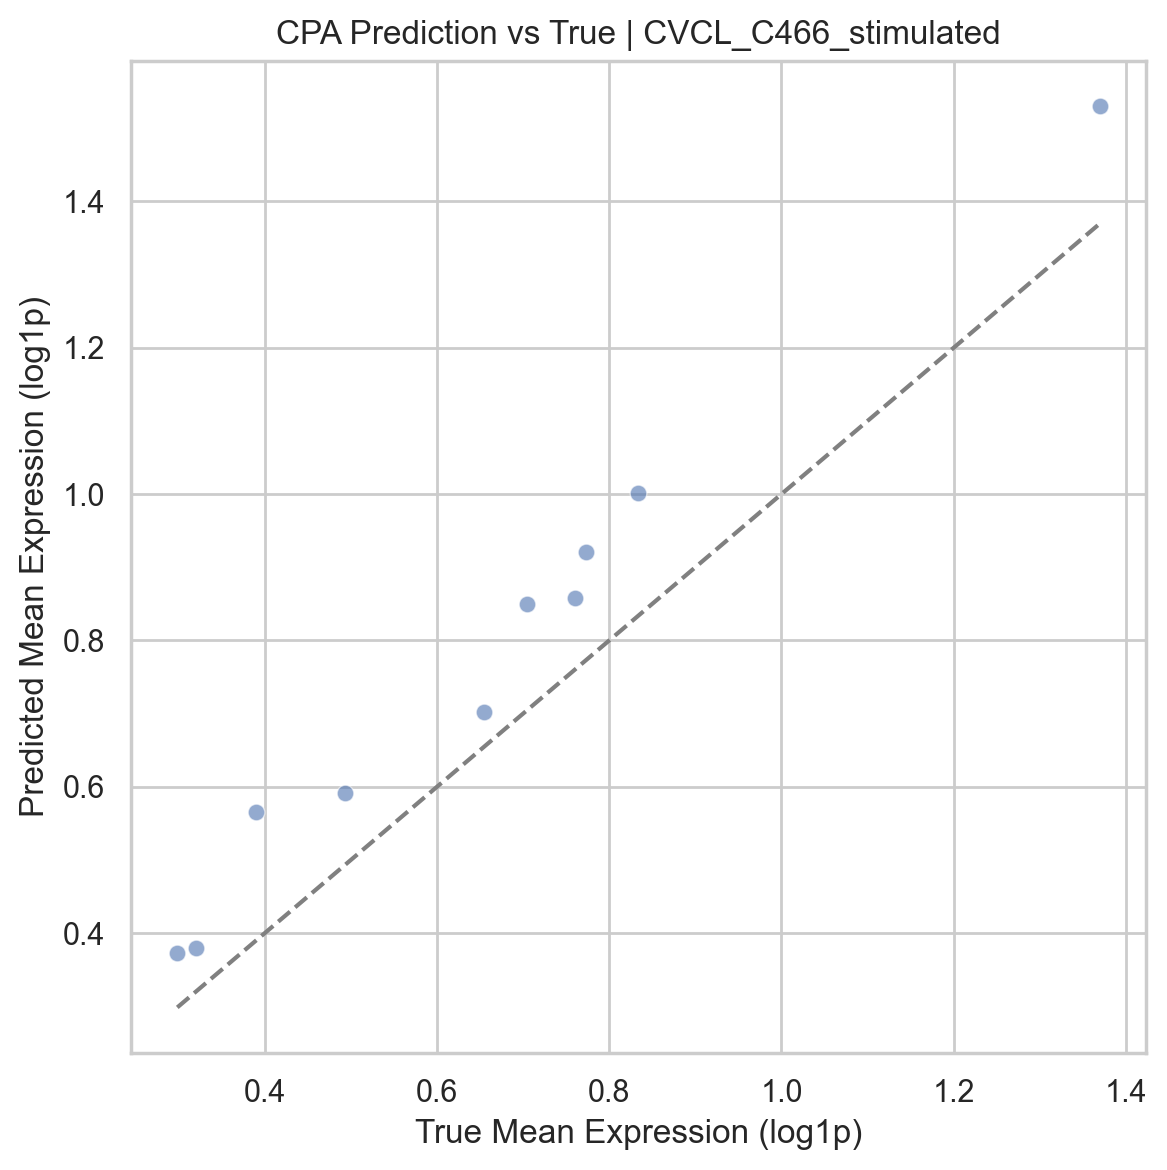

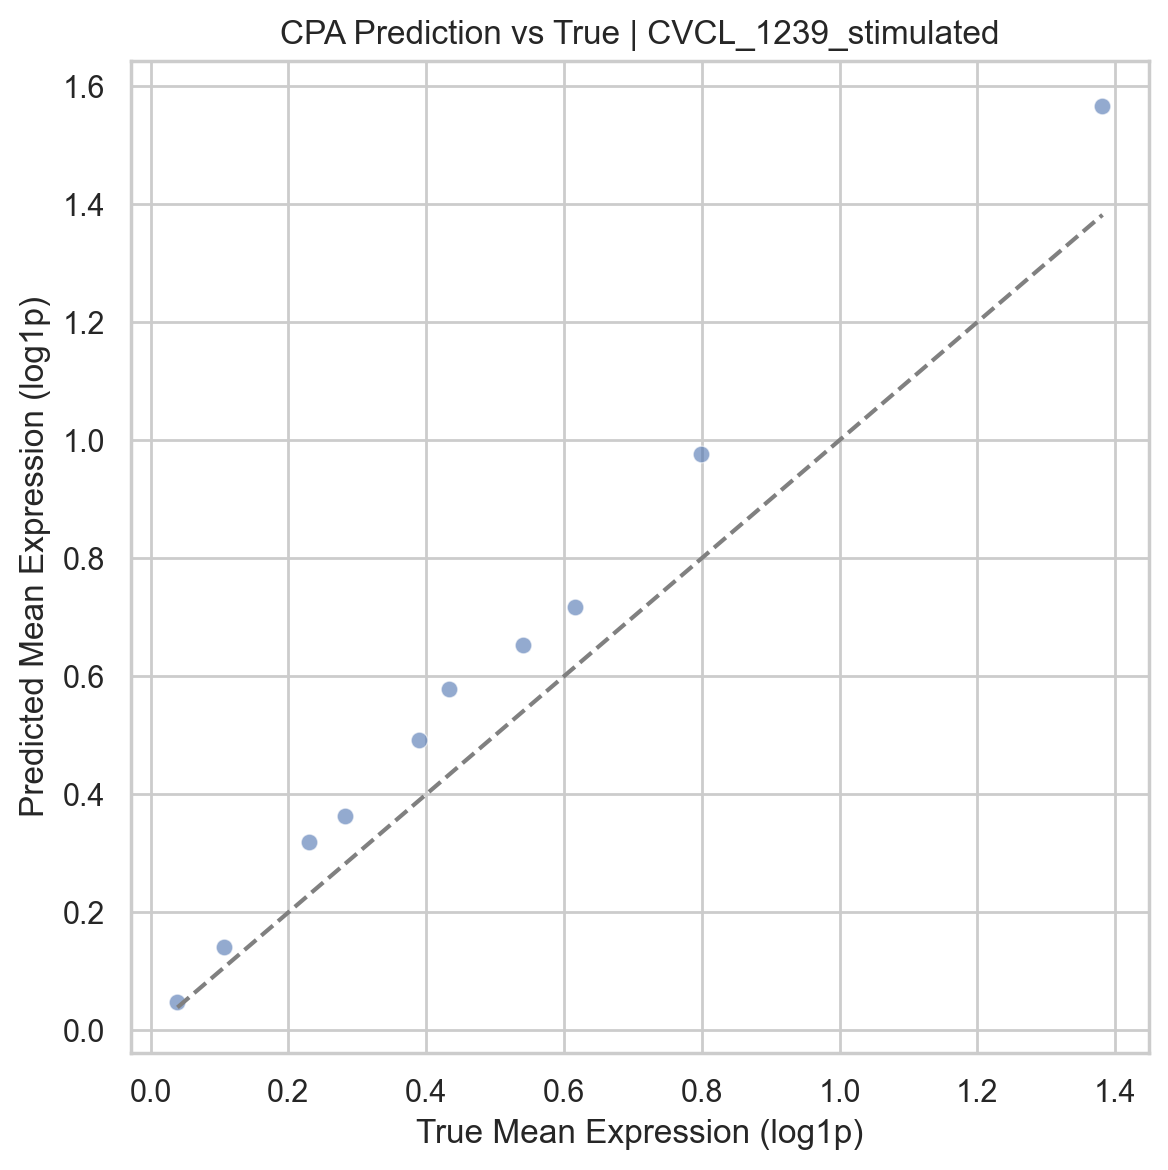

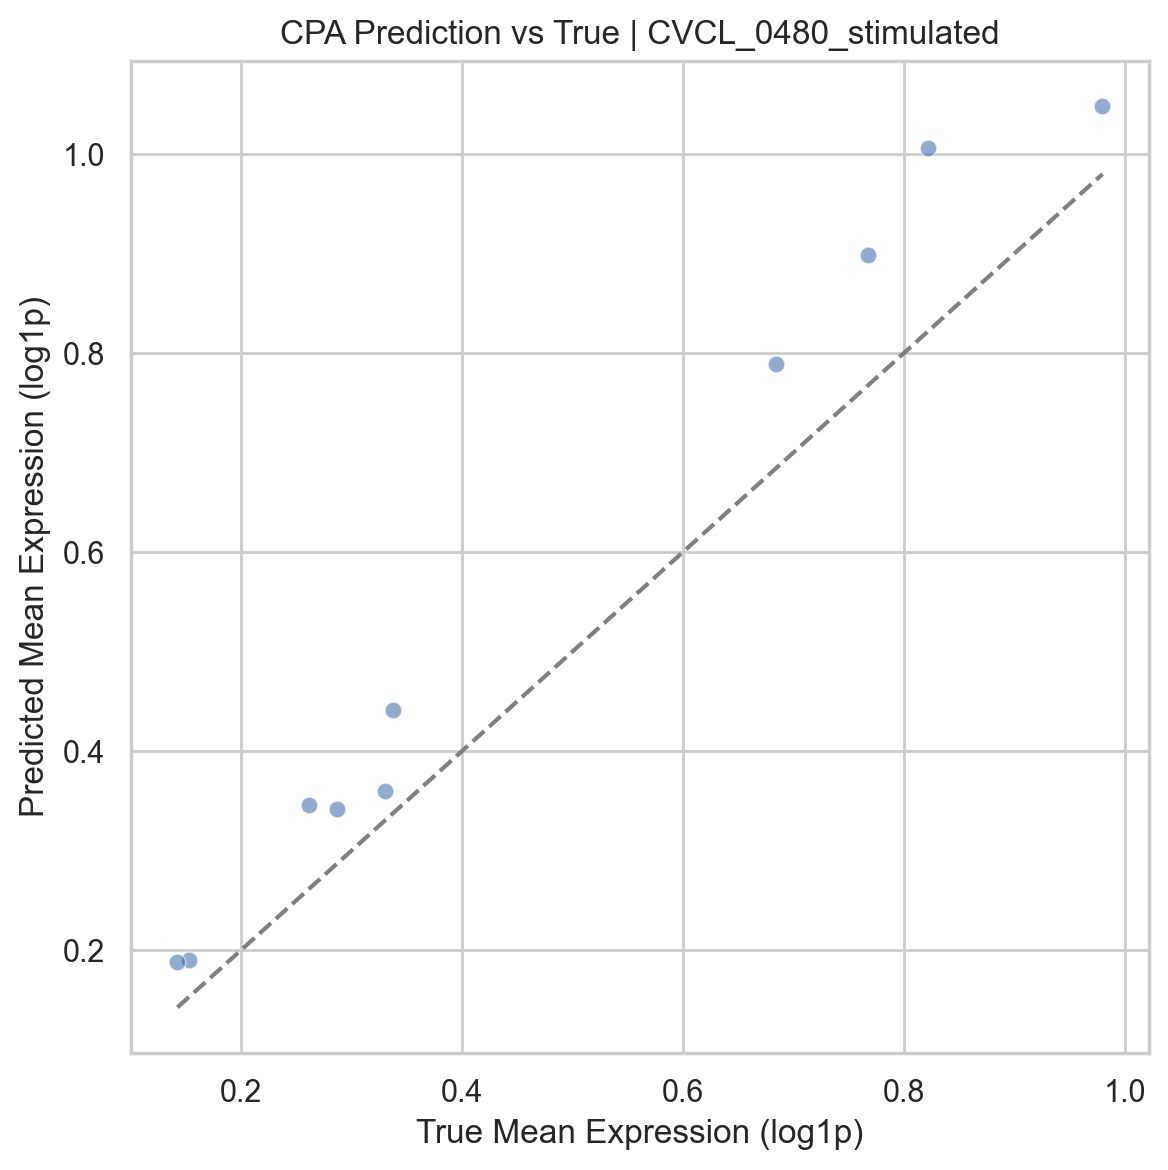

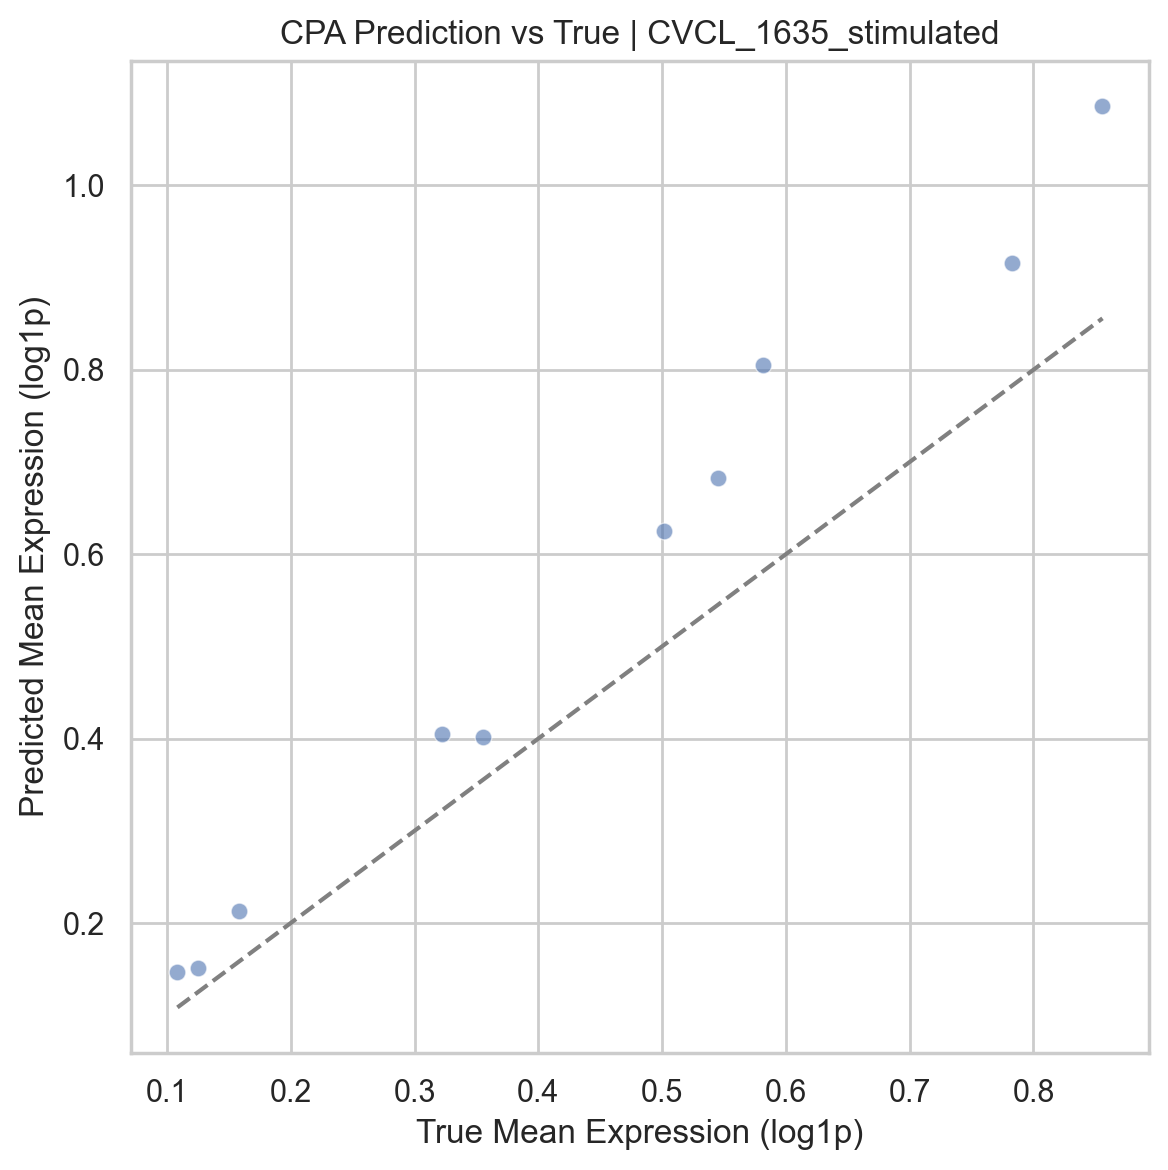

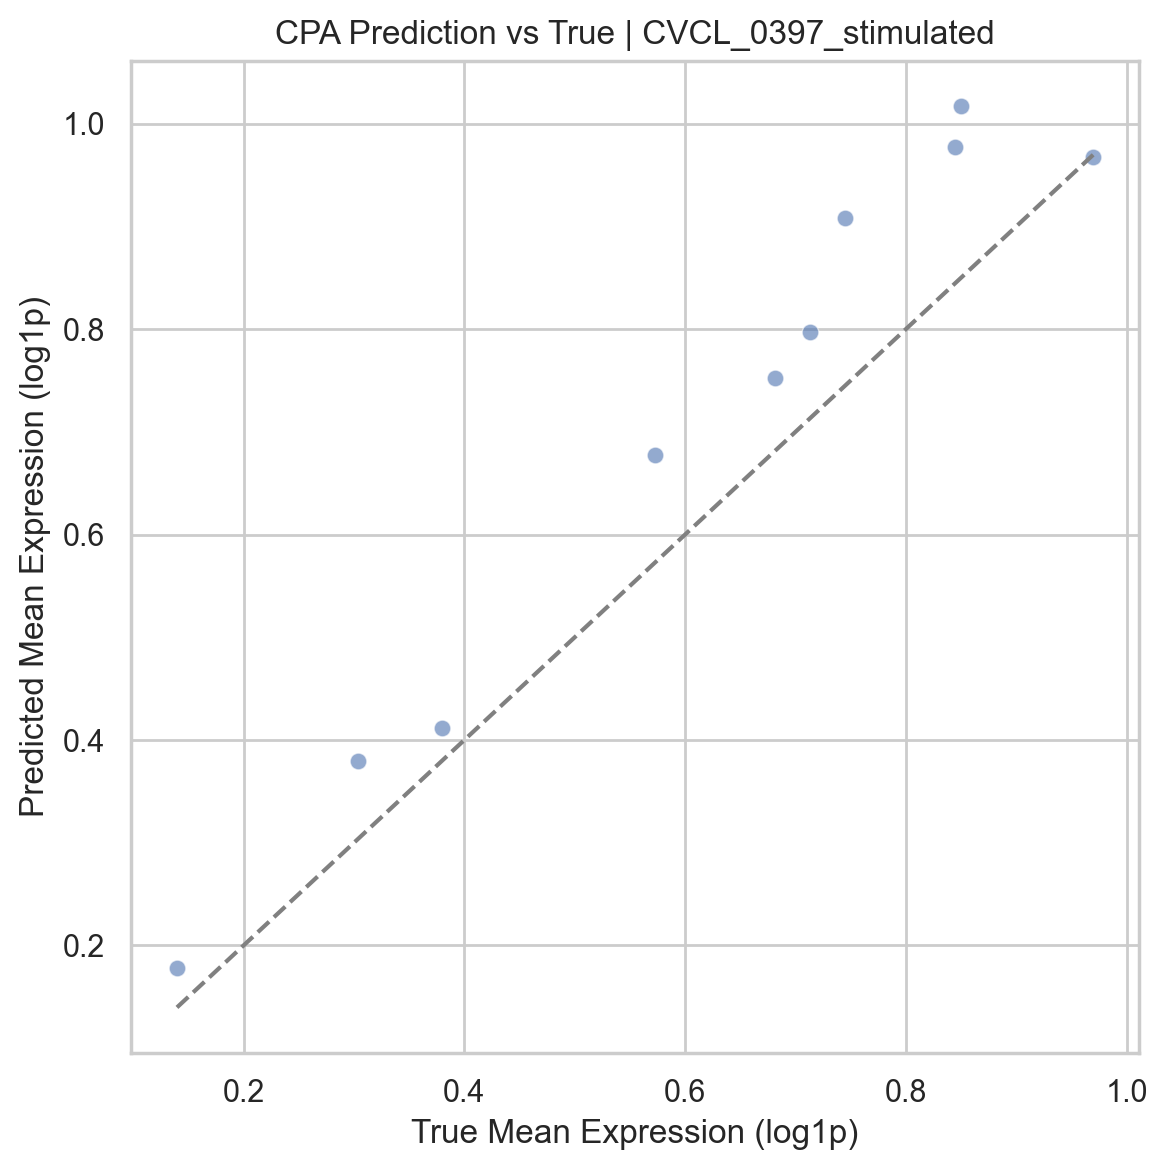

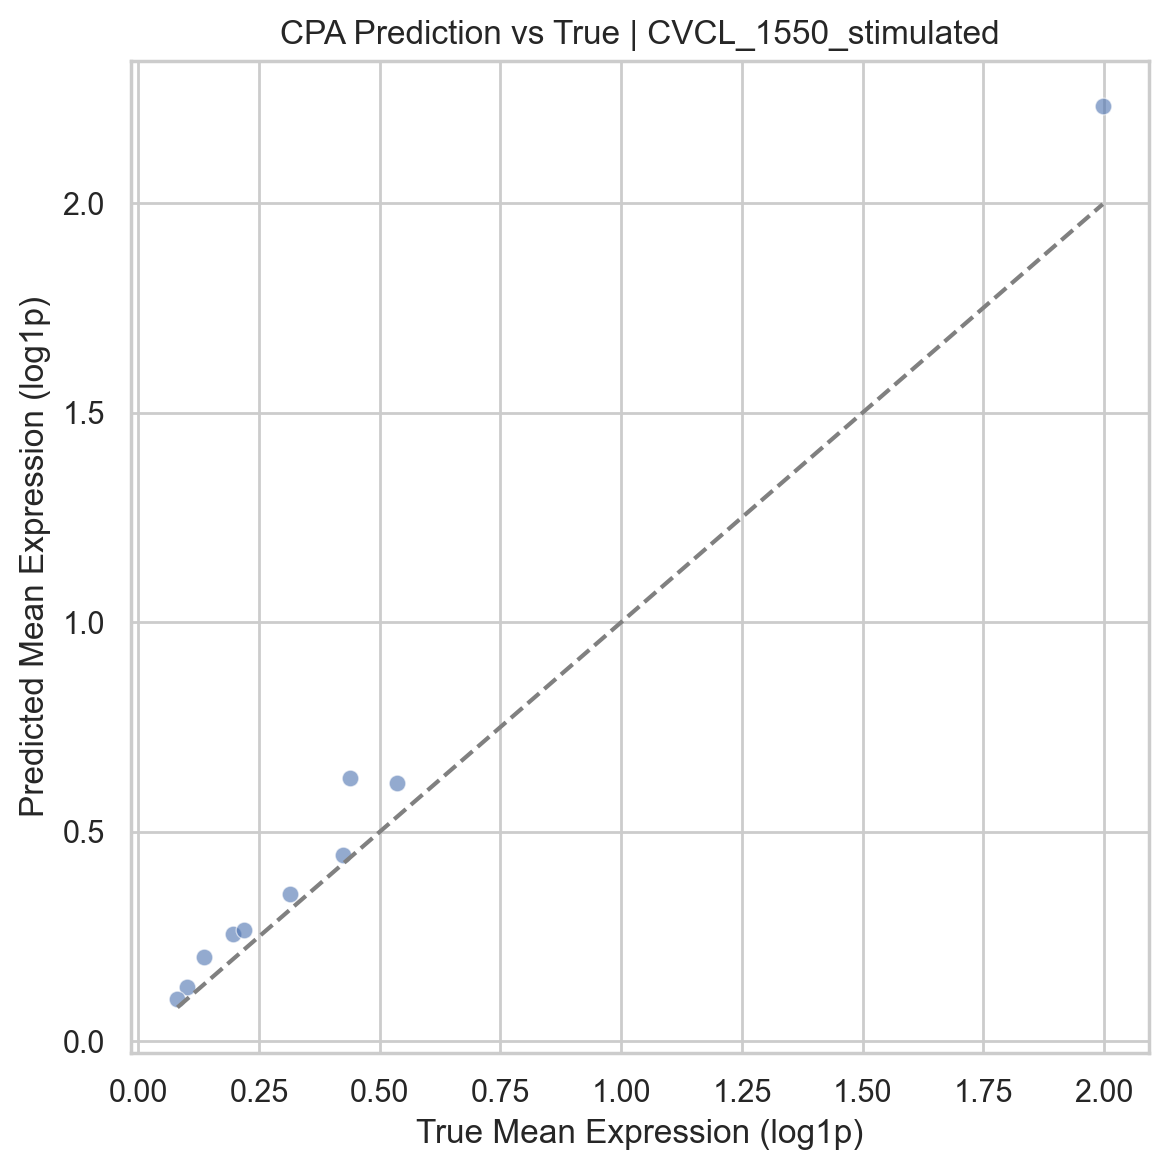

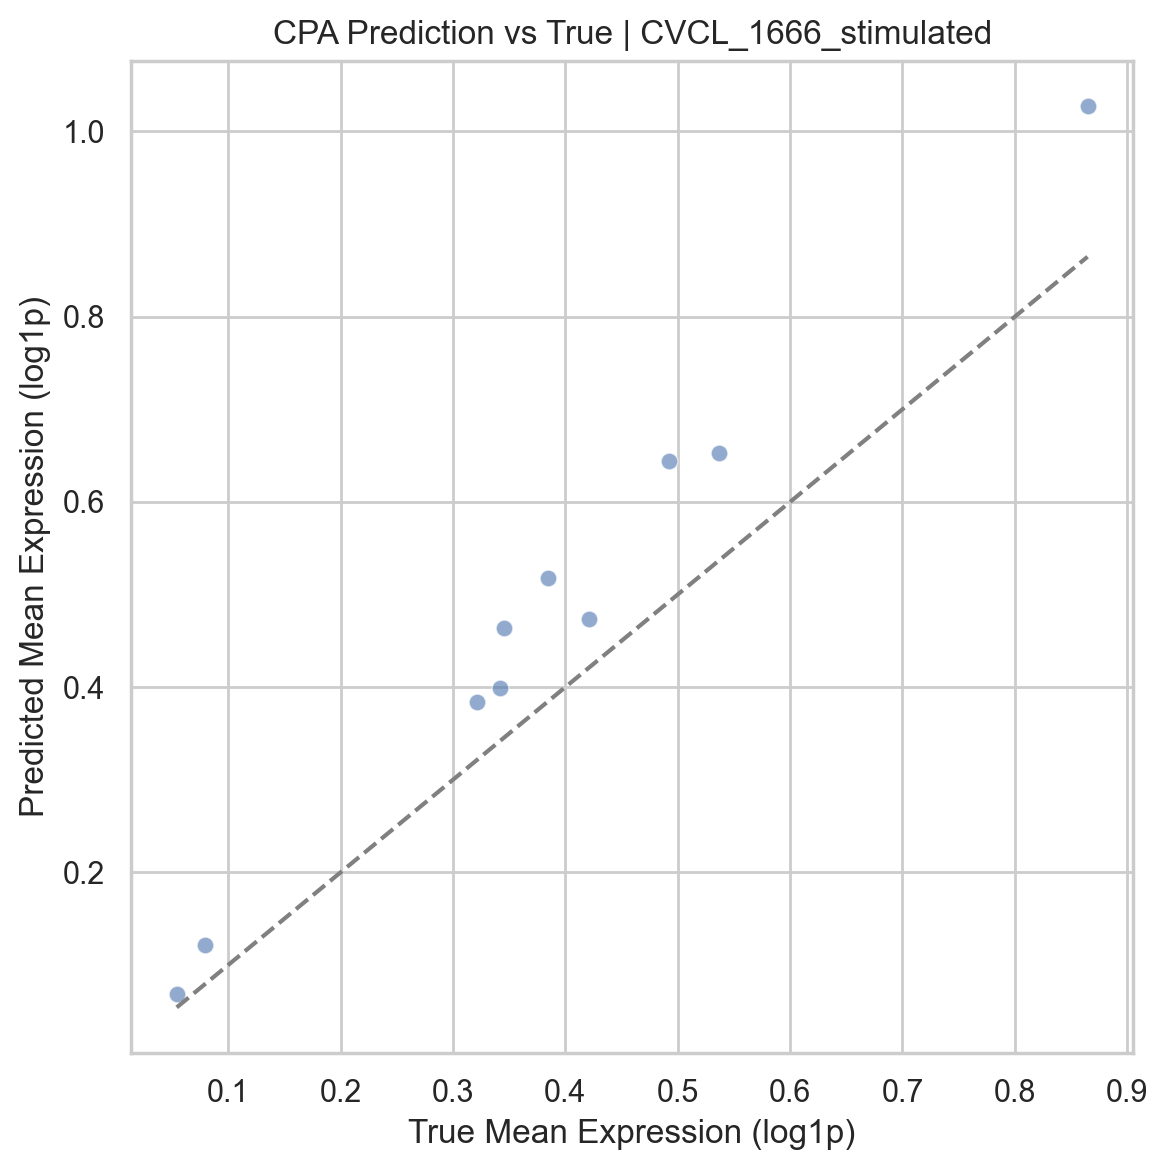

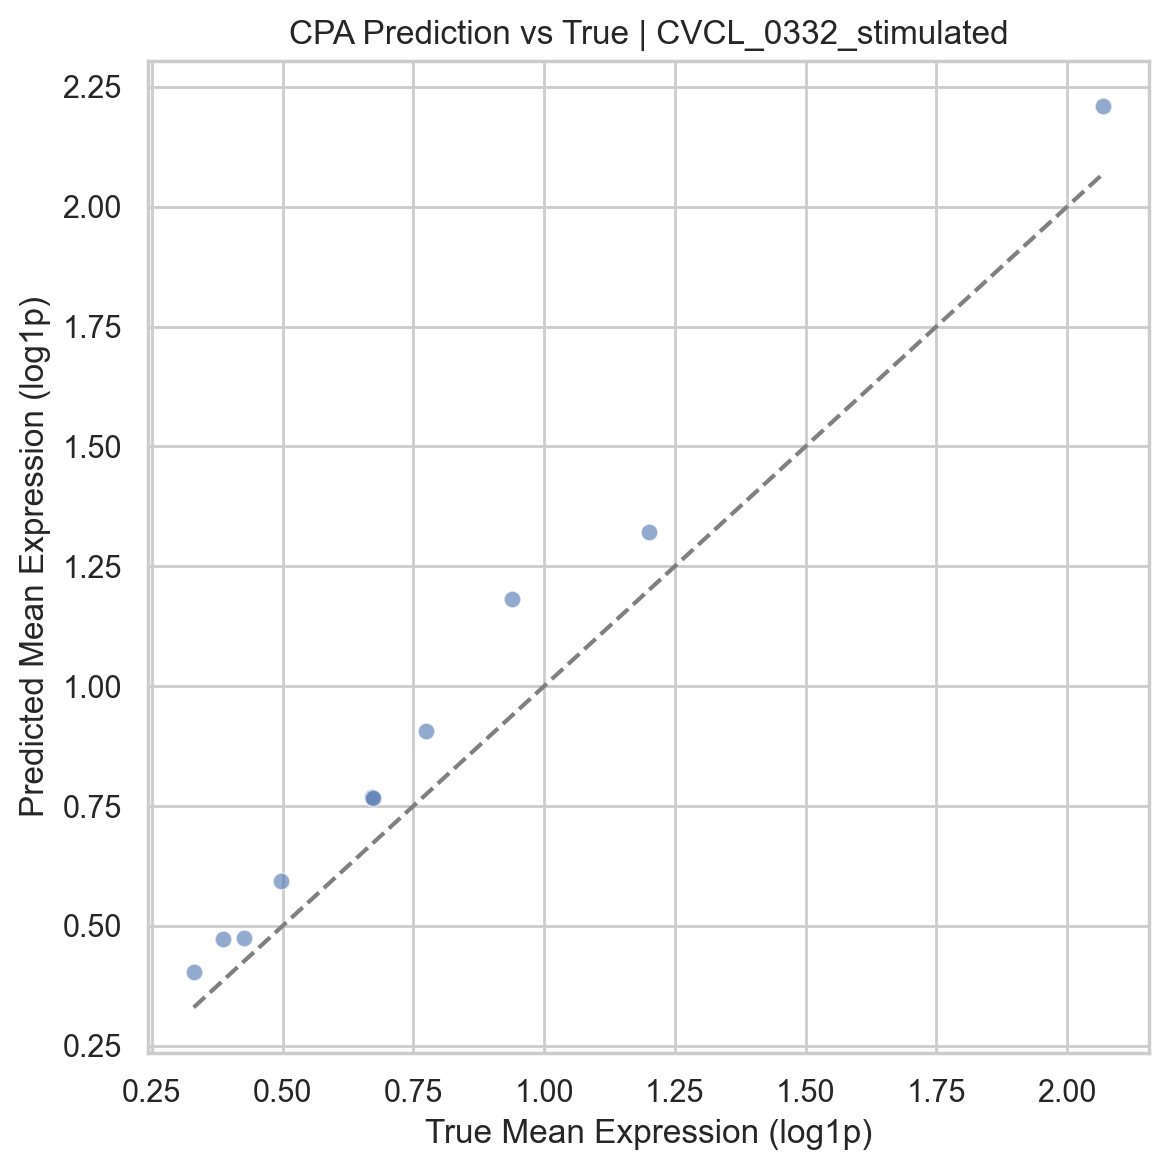

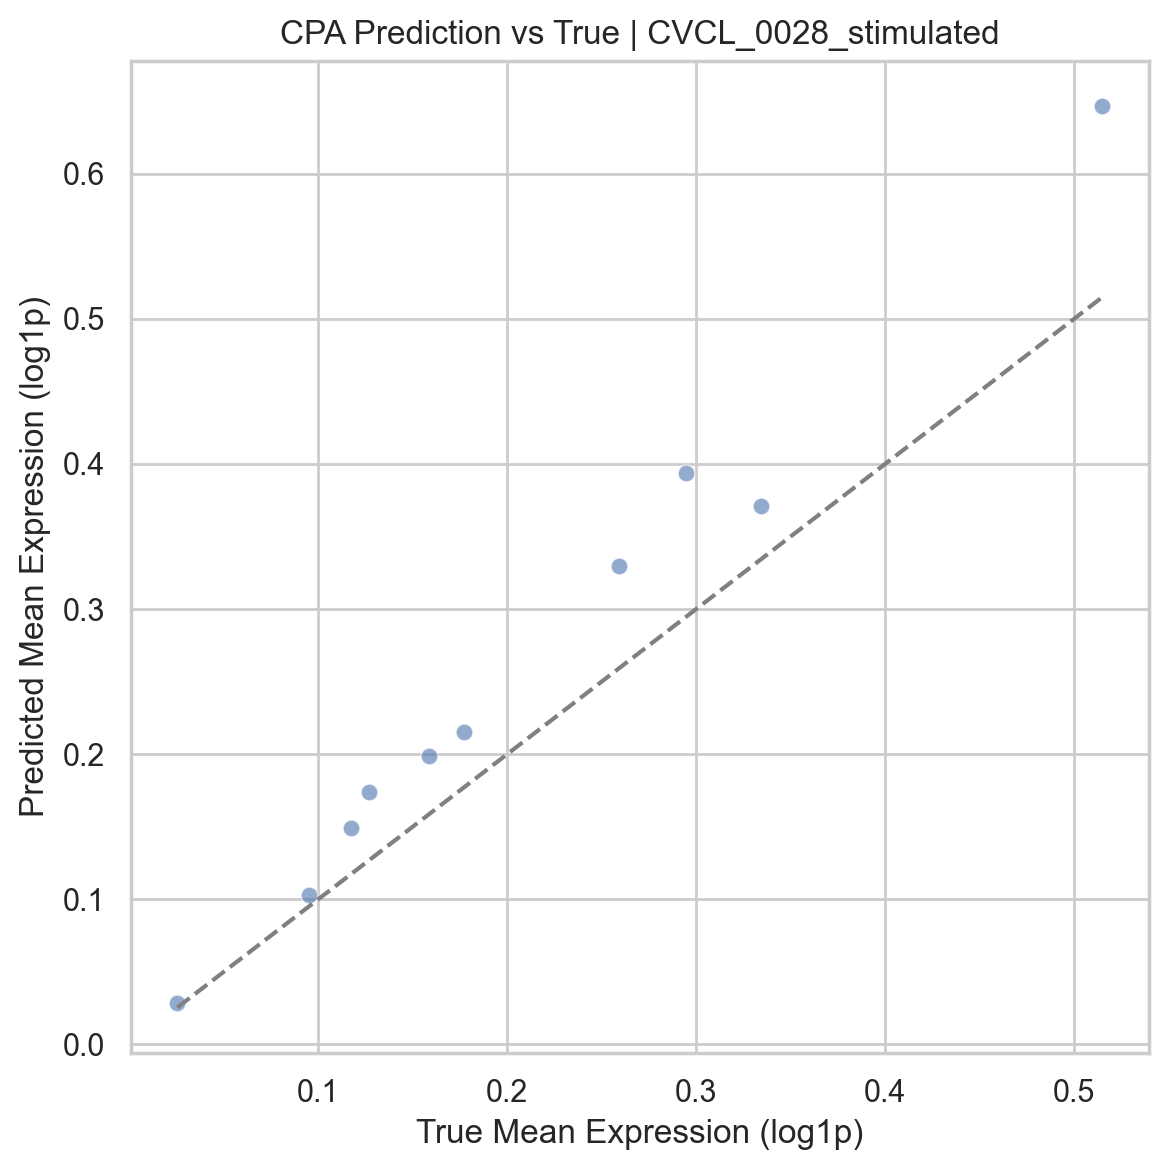

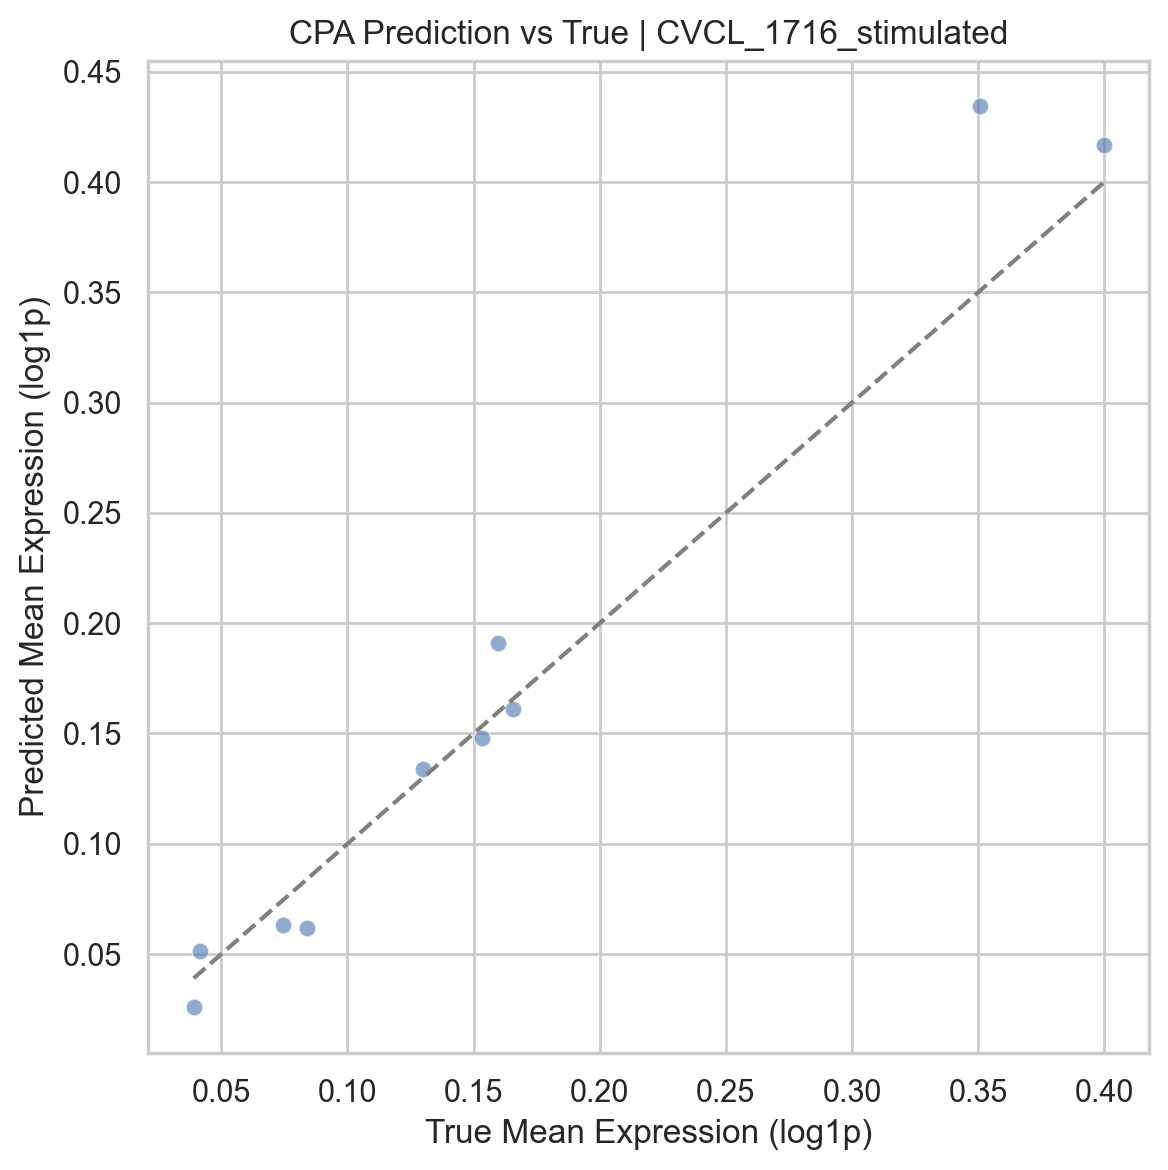

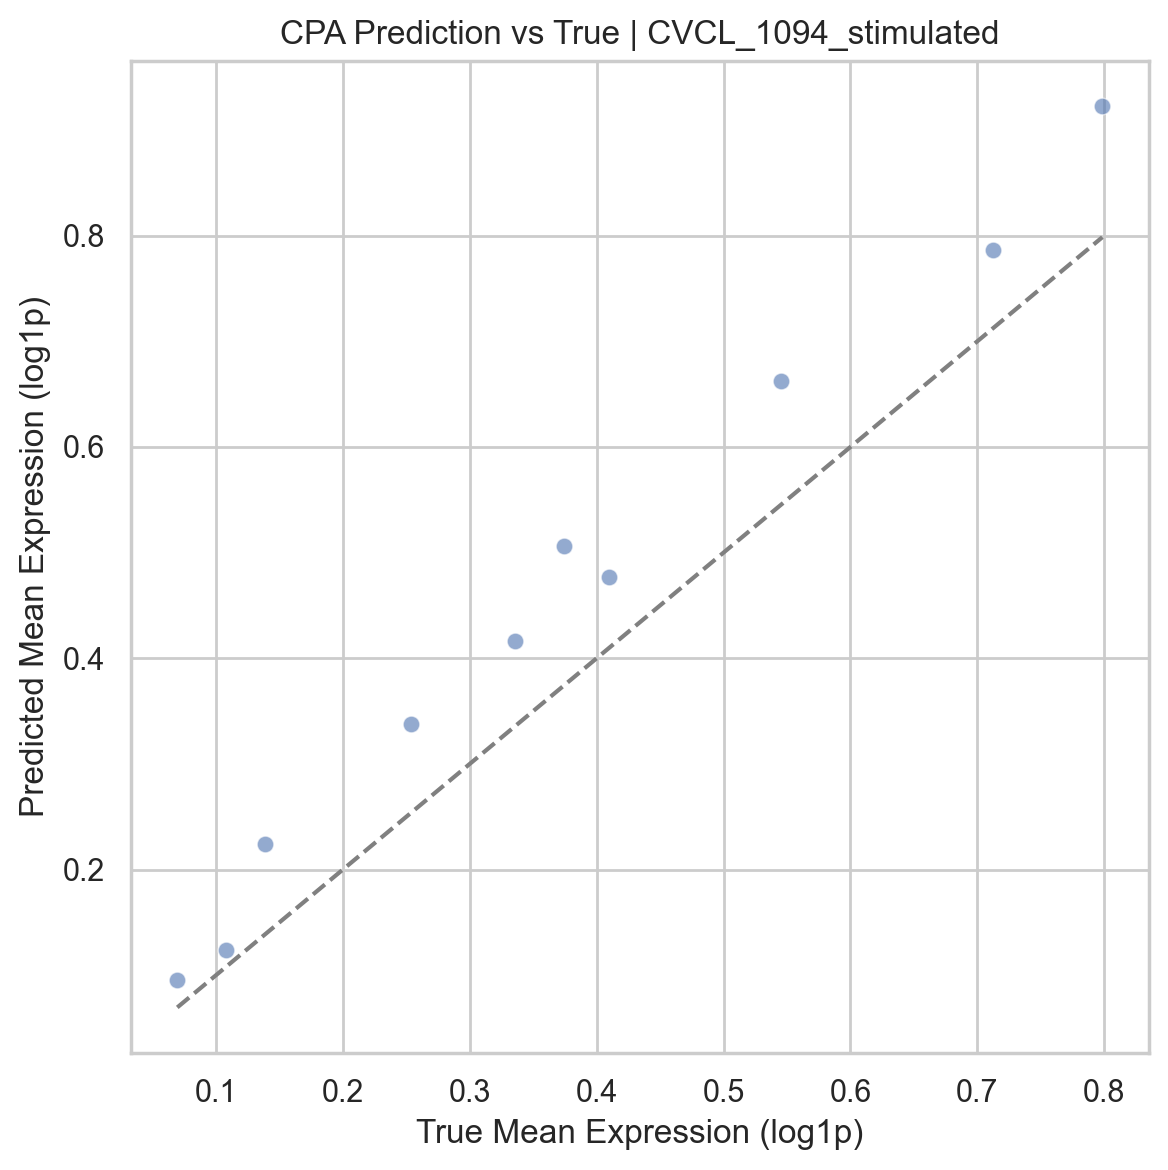

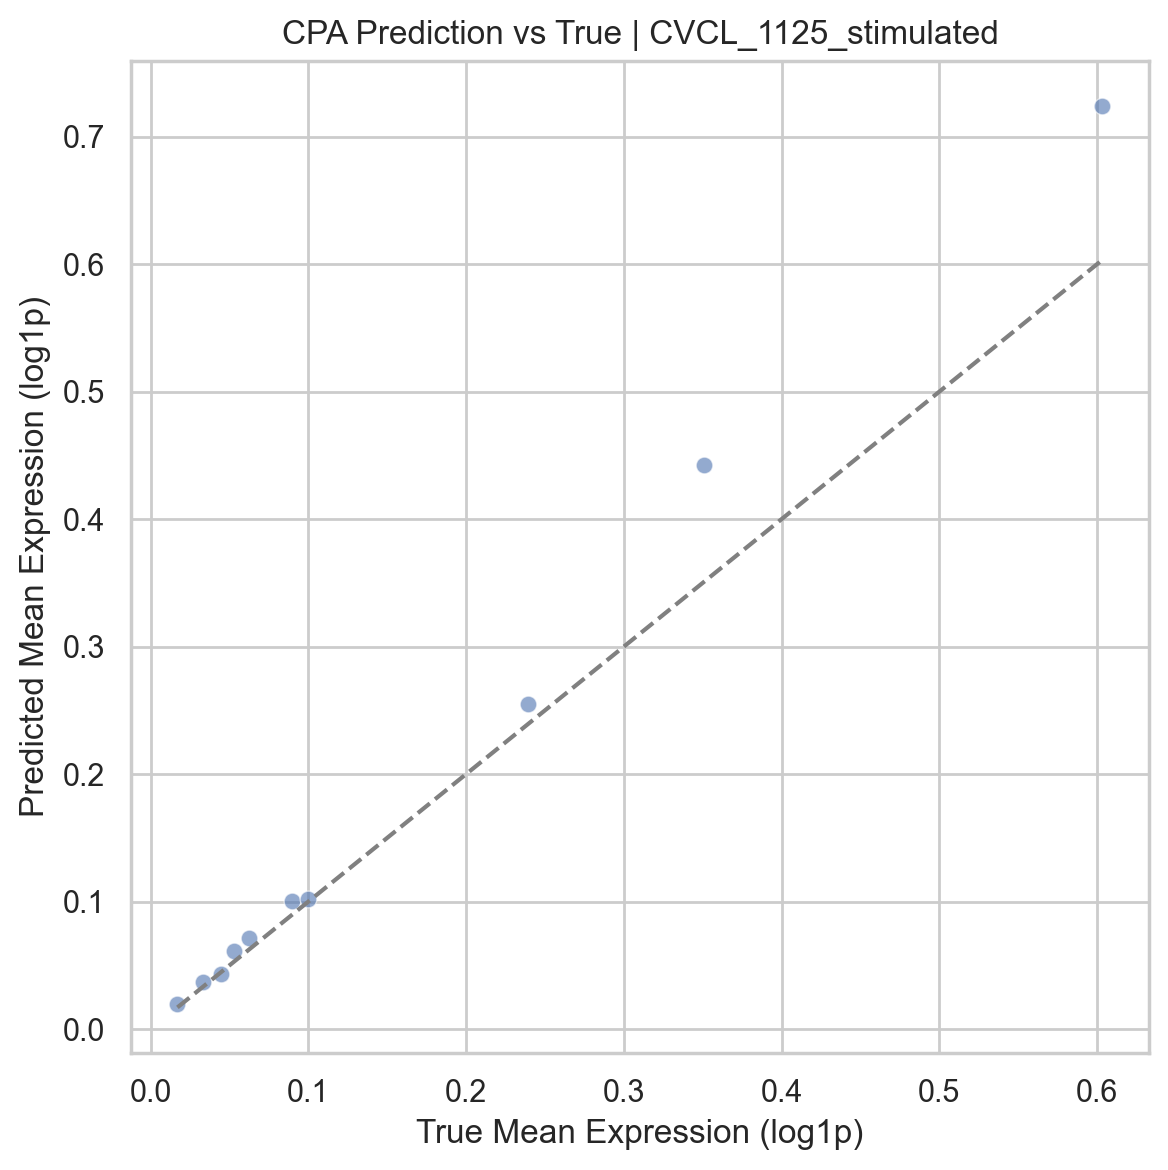

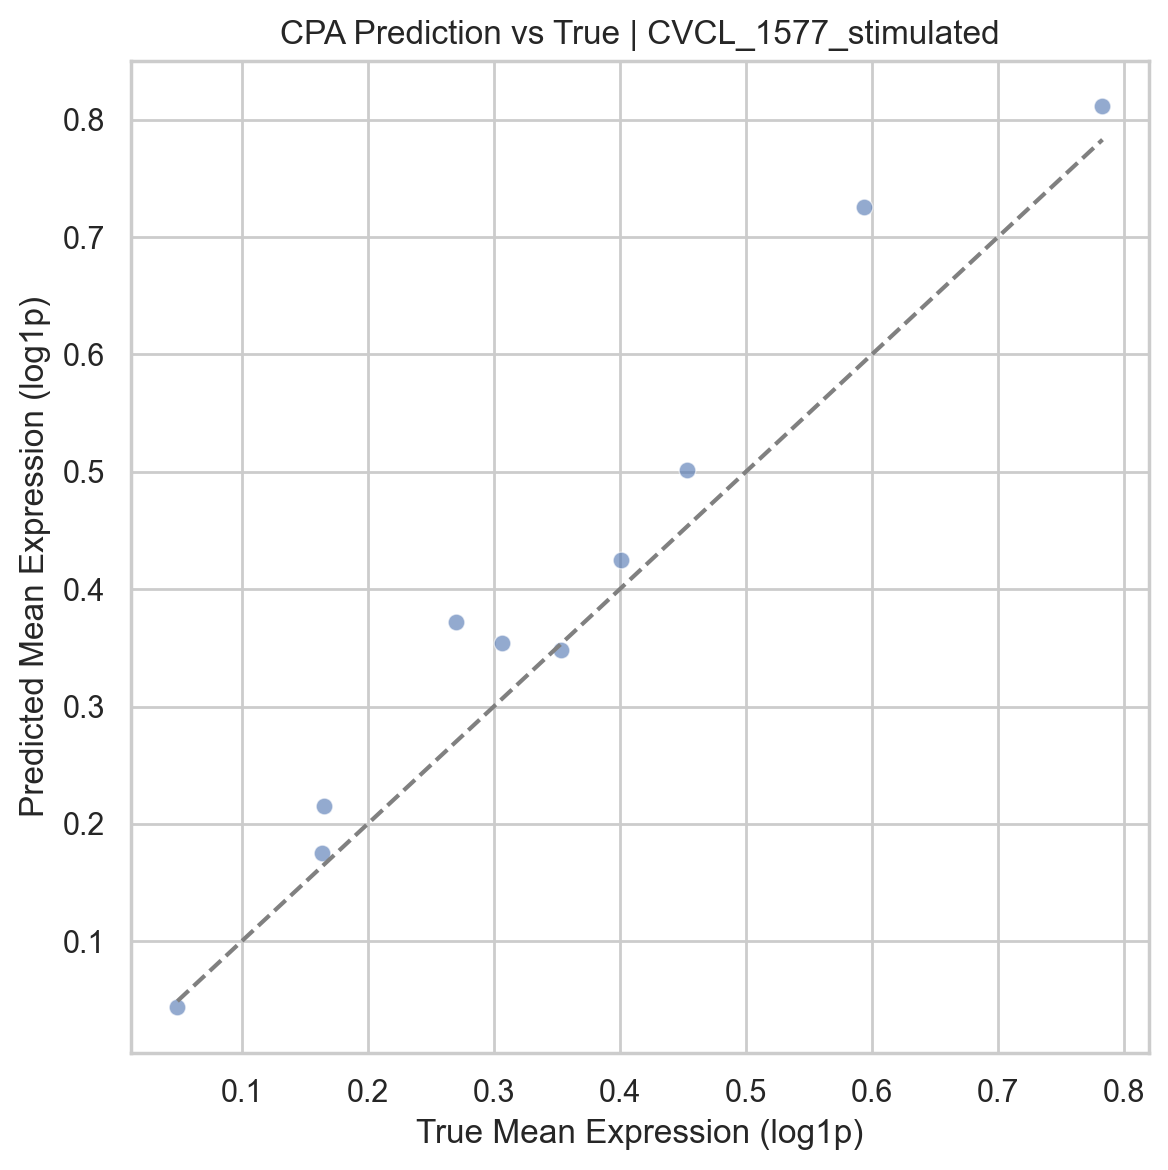

In [55]:
# Loop through all stimulated conditions
for cat in adata.obs['cov_cond'].unique():
    if 'stimulated' not in cat:
        continue

    # Get control condition
    cov, condition = cat.rsplit('_', 1)
    deg_cat = f'{cat}'
    deg_list = adata.uns['rank_genes_groups'][deg_cat]['names']
    degs = np.where(np.isin(adata.var_names, deg_list[:10]))[0]  # Top 10 DEGs

    if len(degs) == 0:
        print(f"No DEGs found for {cat}")
        continue

    # Extract adatas
    cat_adata = adata[adata.obs['cov_cond'] == cat]
    x_true = cat_adata.layers['counts']
    x_pred = cat_adata.obsm['CPA_pred']

    # Log1p transform if needed
    x_true = np.log1p(x_true)
    x_pred = np.log1p(x_pred)

    # Subset to DEGs
    x_true_deg = x_true[:, degs]
    x_pred_deg = x_pred[:, degs]

    # Convert mean to dense arrays
    true_mean = np.asarray(x_true_deg.mean(0)).flatten()
    pred_mean = np.asarray(x_pred_deg.mean(0)).flatten()

    # Plot
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=true_mean, y=pred_mean, alpha=0.6)
    plt.plot([true_mean.min(), true_mean.max()],
             [true_mean.min(), true_mean.max()],
             linestyle='--', color='gray')
    plt.xlabel("True Mean Expression (log1p)")
    plt.ylabel("Predicted Mean Expression (log1p)")
    plt.title(f"CPA Prediction vs True | {cat}")
    plt.tight_layout()
    plt.show()
